# Customer Sentiment & Emotion Intelligence Platform

**Project 9 -- TechTrek Advanced Data Science & AI Graduation Project**

This notebook builds an end-to-end NLP system that classifies the emotion behind a piece of customer text (`dair-ai/emotion`: sadness, joy, love, anger, fear, surprise), compares classical machine learning against deep learning against a fine-tuned Transformer, turns the classifier's output into a prioritized human review queue via topic modeling and a business-rule scoring layer, exposes everything through a Streamlit application with a RAG assistant, and ships that application as a Docker container. The notebook is organized into the following phases, each documented with an English markdown cell above every code cell and a summary paragraph at the end of the phase:

1. **Data Loading** -- load `dair-ai/emotion` and check class balance.
2. **Text Cleaning** -- lowercase, strip HTML-like tags, normalize whitespace.
3. **Tokenization** -- NLTK tokenization, length analysis, bivariate EDA, the train/test split shared by every model, and the Keras tokenizer used by the PyTorch models.
4. **TF-IDF Classical ML Track** -- three baselines (Logistic Regression, Linear SVM, Multinomial Naive Bayes), then a 27-way n-gram/max_features/model sweep.
5. **Select & Tune the Best Classical Model** -- `GridSearchCV` hyperparameter tuning, class-wise metrics, an official-test-split sanity check, probability calibration with a confidence-threshold analysis, and word-level explainability.
6. **Deep Learning Track (PyTorch)** -- six architectures (Embedding MLP, CNN, RNN, LSTM, GRU, BiLSTM) trained identically with class-weighted loss, early stopping, and LR scheduling.
7. **Transformer Fine-Tuning** -- DistilBERT fine-tuned with linear warmup, compared against the best classical and best deep-learning models.
8. **Advanced / Distinction Features** -- per-emotion NMF topic modeling, an emotion x topic heatmap, a heuristic priority-scoring formula, and a per-emotion-balanced human review queue.
9. **Save Pipeline Outputs** -- every model, metric table, and config written to `results/` in a consistent, organized structure.
10. **Analytics Database** -- a SQLite database with 7 tables and 30 analytical SQL queries (JOINs, CTEs, window functions) over everything the notebook produced.
11. **Tests & Sanity Checks** -- 13 automated data/model/artifact/database tests that must all pass before deployment.
12. **Deployment** -- a Streamlit app (classification + RAG assistant + prediction logging), served via ngrok from Colab or via the included Dockerfile.

> **Note:** several sections below still carry the notebook's own original Arabic change-log notes (marked "تعديل"/"إضافة") documenting what was fixed or added and why, kept intentionally as a historical record on top of the new English explanations.

# Data Loading

Loads the **`dair-ai/emotion`** dataset from the Hugging Face Hub and converts its `train` split into a pandas DataFrame `df` with two columns: `text` (the raw message) and `label` (an integer 0-5 encoding one of six emotions). Only the `train` split is loaded here for the main pipeline that follows; the dataset's official `validation`/`test` splits are used later, separately, as an out-of-sample sanity check.

In [1]:
from datasets import load_dataset

emotion_dataset = load_dataset("dair-ai/emotion")
df=emotion_dataset['train'].to_pandas()
df.head()

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


Confirms the shape of `df` (row and column counts) as a first sanity check on the load.

In [2]:
df.shape

(16000, 2)

Lists the DataFrame's columns to confirm the expected `text` / `label` schema.

In [3]:
df.columns

Index(['text', 'label'], dtype='object')

Checks for missing values in every column -- confirms the dataset arrived clean, with no nulls to handle before moving on.

In [4]:
df.isnull().sum()

,0
text,0
label,0


#Class Imbalance Checking

Prints the raw row count per emotion class -- the first look at how imbalanced the six emotion classes are.

In [5]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Visualizes the same class distribution as a percentage bar chart (with the exact percentage annotated above each bar), making the imbalance easier to judge at a glance than the raw counts above. This imbalance is the reason `class_weight='balanced'` / balanced `sample_weight` are used for every classical model later in the notebook, and why Macro (not just Weighted) metrics are tracked throughout.

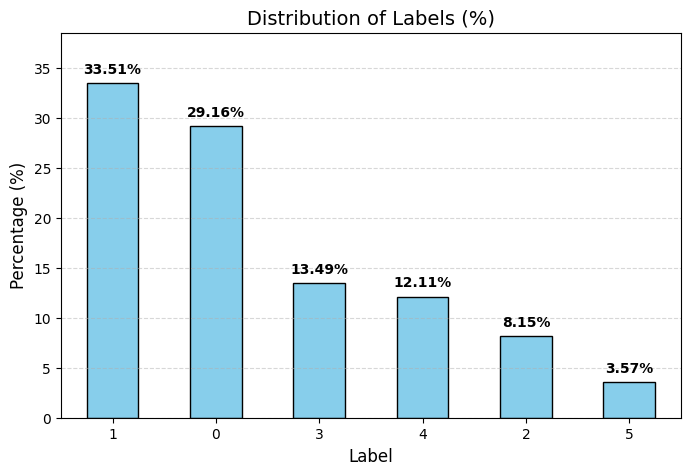

In [6]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add the percentage
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.title('Distribution of Labels (%)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, counts.max() * 1.15)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Lowercases every text (`x.lower()`) as the first normalization step, so that e.g. "Happy" and "happy" are treated as the same token later on.

In [7]:
df['text']=df['text'].apply(lambda x:x.lower())

# Text Cleaning

Strips any HTML-like tags (`<...>`) from every text and collapses repeated whitespace down to single spaces, trimming leading/trailing space. This is a lightweight, dependency-free cleaning pass -- no stopword removal or stemming/lemmatization, so the TF-IDF vocabulary later still contains real, readable words (useful for the explainability section further down).

In [8]:
import regex as rx

df['text']=df['text'].apply(lambda x:rx.sub('<.*?>',' ',x))
df['text']=df['text'].apply(lambda x:rx.sub(r'\s+',' ',x).strip())

Previews the first rows of the cleaned `df` to visually confirm the cleaning worked as expected.

In [9]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


# Tokenization

Downloads NLTK's `punkt` tokenizer models and tokenizes every cleaned text into a list of word tokens, stored in a **copy** of the DataFrame (`df_tokens`) so the original `df['text']` (still a plain string per row) stays available for the TF-IDF vectorizers used later -- `df_tokens` is used only for length/EDA analysis, not for modeling directly.

In [10]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df_tokens=df.copy()
df_tokens['text']=df['text'].apply(lambda x:word_tokenize(x))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Previews `df_tokens` to confirm each row's `text` is now a list of tokens instead of a raw string.

In [11]:
df_tokens.head()

,text,label
0,"[i, didnt, feel, humiliated]",0
1,"[i, can, go, from, feeling, so, hopeless, to, ...",0
2,"[im, grabbing, a, minute, to, post, i, feel, g...",3
3,"[i, am, ever, feeling, nostalgic, about, the, ...",2
4,"[i, am, feeling, grouchy]",3


Computes the token count (length) of every message into a plain Python list `lengths`, used by all the length-distribution analysis below.

In [12]:
lengths=[len(s) for s in df_tokens['text']]

Sums all message lengths (used to compute the average length in the next cell).

In [13]:
sum_length=sum(lengths)

Divides the total token count by the number of messages to get the average message length (`avg_length`).

In [14]:
avg_length=sum_length/len(lengths)

Finds the single longest message in the dataset, in tokens (`max_length`).

In [15]:
max_length=max(lengths)

Prints the average and maximum message length computed above.

In [16]:
print(avg_length)
print(max_length)

19.1753125
66


Plots a histogram of message lengths across the whole dataset, showing that most messages are short with a long right tail of longer ones.

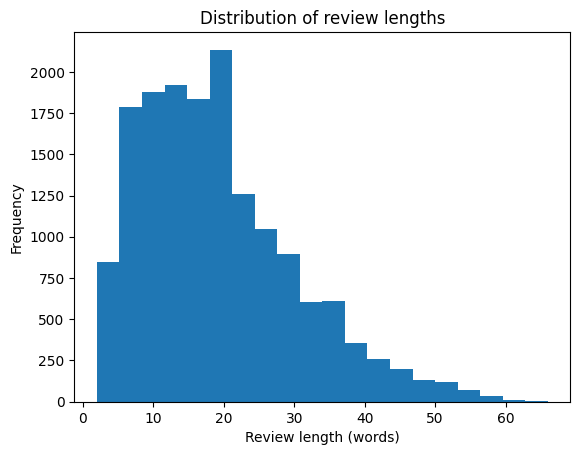

In [17]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(lengths, bins=20)
plt.xlabel("Review length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of review lengths")
plt.show()

Computes the 90th and 95th percentile message length. These percentiles (together with the histogram above) are what later justify picking `maxlen=41` for padding the sequence models -- long enough to cover the vast majority of messages without padding everything out to the length of the rare, very long outlier.

In [18]:
p90=np.percentile(lengths, 90)
p95=np.percentile(lengths, 95)
print("90th percentile:", p90)
print("95th percentile:", p95)

90th percentile: 35.0
95th percentile: 41.0


## Bivariate EDA — Text Length by Emotion

**إضافة:** التحليلين اللي فاتوا (توزيع الطول، والـ class imbalance) كل واحد فيهم بيبص على متغير واحد لوحده. هنا بنربط الاتنين مع بعض: هل بعض الانفعالات (زي `anger` أو `fear`) بتيجي في نصوص أطول أو أقصر من غيرها في المتوسط؟ ده ممكن يأثر على قرارات زي الـ `maxlen`، وممكن كمان يوضح إذا كان فيه bias في طول العينات بين الكلاسات.

Builds the per-class length table and boxplot referenced by the markdown above: adds a numeric `length` column and a human-readable `emotion_name` column to `df_tokens`, then plots a boxplot of length grouped by emotion, followed by a small summary table (mean / median / min / max length per emotion).

<Figure size 900x500 with 0 Axes>

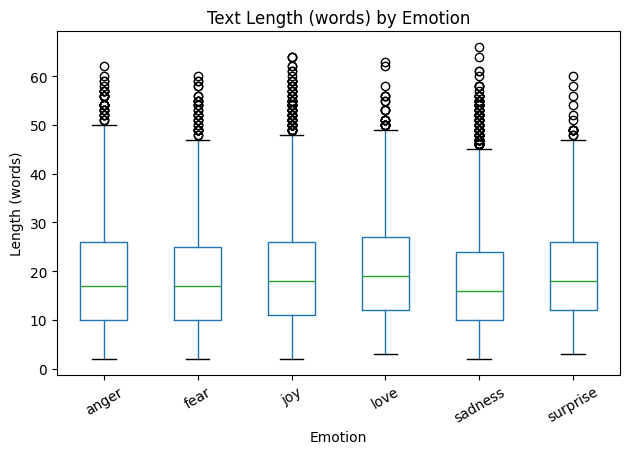

,mean,50%,min,max
emotion_name,,,,
anger,19.24,17.0,2.0,62.0
fear,18.85,17.0,2.0,60.0
joy,19.51,18.0,2.0,64.0
love,20.71,19.0,3.0,63.0
sadness,18.37,16.0,2.0,66.0
surprise,19.98,18.0,3.0,60.0


In [19]:
import pandas as pd

df_tokens['length'] = df_tokens['text'].apply(len)
emotion_label_names = emotion_dataset['train'].features['label'].names
df_tokens['emotion_name'] = df_tokens['label'].map(lambda i: emotion_label_names[i])

plt.figure(figsize=(9, 5))
df_tokens.boxplot(column='length', by='emotion_name', grid=False)
plt.suptitle('')
plt.title('Text Length (words) by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Length (words)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

df_tokens.groupby('emotion_name')['length'].describe()[['mean', '50%', 'min', 'max']].round(2)

**تعديل:** الخلية اللي جاية كانت فيها `train_test_split` تاني على `df_tokens`
بيرجّع `X_train_tokens, X_test_tokens, y_train_tokens, y_test_tokens` — لكن
`X_test_tokens`, `y_train_tokens`, و`y_test_tokens` ما كانوش بيتستخدموا في أي حتة
تانية في النوت بوك (الاستخدام الوحيد كان `X_train_tokens` لحساب الـ vocabulary في
الخلية اللي بعدها). استبدلناها بسطر واحد ياخد نفس صفوف `X_train` من `df_tokens`
مباشرة بالـ index، فبنوصل لنفس النتيجة من غير حساب زيادة أو متغيرات ميتة.

Creates the actual train/test split used by **every model in this notebook** (classical ML, all 6 PyTorch architectures, and the Transformer): an 80/20 **stratified** split of `df['text']`/`df['label']` (`stratify=df['label']` keeps the same class proportions in both sets despite the imbalance seen earlier), with a fixed `random_state=42` for reproducibility. `X_train_tokens` is then derived by index-aligning `X_train`'s rows against the already-tokenized `df_tokens`, purely to build the vocabulary size estimate in the next cell -- no second train/test split is run.

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(df['text'],df['label'],test_size=0.2,stratify=df['label'],random_state=42)

# X_train_tokens is only needed to build the training vocabulary in the next cell.
# We derive it by index alignment from df_tokens instead of running train_test_split
# a second time (the previous X_test_tokens / y_train_tokens / y_test_tokens were
# produced but never referenced anywhere afterward).
X_train_tokens = df_tokens.loc[X_train.index, 'text']

Counts the total number of **unique** tokens (`all_words`, a set) and the total number of token occurrences (`count`) across the training split -- used next to size the Keras tokenizer's vocabulary.

In [21]:
all_words=set()
count=0
for s in X_train_tokens:
  for w in s:
    all_words.add(w)
    count=count+1
print(len(all_words))
print(count)

13549
246340


Fits a Keras `Tokenizer` on the training texts, capping its vocabulary at the number of unique words found above. This tokenizer (and the `maxlen=41` decided from the percentile analysis) is reused for every PyTorch deep-learning model in the Deep Learning Track further down -- it is **not** used by the classical TF-IDF models, which build their own vectorizer directly from raw text.

In [22]:
tok_all=Tokenizer(num_words=len(all_words))
tok_all.fit_on_texts(X_train)

Converts the training texts into integer sequences and pads/truncates every sequence to a fixed length of 41 tokens (`padding='post', truncating='post'` -- padding zeros and cutting excess tokens at the *end* of each sequence).

In [23]:
sequences_all_train=tok_all.texts_to_sequences(X_train)

padded_all_train=pad_sequences(sequences_all_train, maxlen=41, padding='post', truncating='post')

Applies the same tokenizer and padding to the test texts, producing the held-out `padded_all_test` used to evaluate every PyTorch model later.

In [24]:
sequences_all_test=tok_all.texts_to_sequences(X_test)

padded_all_test=pad_sequences(sequences_all_test, maxlen=41, padding='post', truncating='post')

# TFIDF

Fits a default (untuned) `TfidfVectorizer` on the training texts and transforms both train and test sets into TF-IDF feature matrices (`tfidf_train`/`tfidf_test`). This first, simple vectorizer is only used for the three standalone baseline models directly below; the n-gram / max_features sweep further down fits several more vectorizers from scratch to find a better configuration.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()
tfidf_train=tfidf.fit_transform(X_train)
tfidf_test=tfidf.transform(X_test)

Prints the shape of the TF-IDF matrices to confirm the vocabulary size (columns) and row counts match the train/test split.

In [26]:
print(tfidf_train.shape)
print(tfidf_test.shape)

(12800, 13526)
(3200, 13526)




##TF-IDF + Logistic Regression

**تعديل:** أضفنا `Weighted Precision` و `Weighted Recall` جنب نسختهم الـ Macro
داخل `evaluate_classifier`، عشان الثلاث متاريك (Precision, Recall, F1) يبقى لكل
واحدة فيهم نسخة macro ونسخة weighted بالتساوي، بدل ما كانت الـ weighted موجودة في
الـ F1 بس. أي نتيجة جاية من الدالة دي (LR, SVM, تجربة الـ n-gram/max_features تحت)
هتاخد السبع متاريك أوتوماتيك.

Defines `evaluate_classifier()`, the single evaluation function reused by **every** classical model in this notebook (baselines, the n-gram sweep, hyperparameter tuning) -- it returns all 7 metrics (Accuracy, Macro/Weighted Precision, Macro/Weighted Recall, Macro/Weighted F1) in one dictionary so every table downstream is directly comparable. Then trains the first baseline, **Logistic Regression with `class_weight='balanced'`** (to counter the class imbalance found earlier), on the default TF-IDF features, and evaluates it into `lr_results_df`.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np

label_names = emotion_dataset["train"].features["label"].names
print("Emotion classes:", label_names)

def evaluate_classifier(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Macro Precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y, y_pred, average="weighted", zero_division=0),
        "Macro Recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "Weighted Recall": recall_score(y, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y, y_pred, average="weighted", zero_division=0)
    }

# إضافة: class_weight='balanced' عشان الداتا imbalanced (زي ما اتعمل بالظبط في
# تراك الـ Deep Learning تحت باستخدام compute_class_weight) -- قبل كده الموديلات
# الكلاسيكية كانت الوحيدة اللي متعاملتش مع الـ imbalance خالص.
lr_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr_model.fit(tfidf_train, y_train)

lr_results = evaluate_classifier(lr_model, tfidf_test, y_test)
lr_results_df = pd.DataFrame([lr_results], index=["TF-IDF + Logistic Regression"])
lr_results_df.round(4)

Emotion classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
TF-IDF + Logistic Regression,0.8744,0.8265,0.8832,0.8788,0.8744,0.8479,0.8764


##TF-IDF + Linear SVM

Trains the second baseline, **Linear SVM** (`LinearSVC`, also `class_weight='balanced'`), on the same TF-IDF features, and evaluates it into `svm_results_df`.

In [28]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
svm_model.fit(tfidf_train, y_train)

svm_results = evaluate_classifier(svm_model, tfidf_test, y_test)
svm_results_df = pd.DataFrame([svm_results], index=["TF-IDF + Linear SVM"])
svm_results_df.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
TF-IDF + Linear SVM,0.8894,0.8514,0.892,0.874,0.8894,0.8619,0.8902


##TF-IDF + Multinomial Naive Bayes

**إضافة:** الـ checklist العام بيطلب 3 موديلات ML كلاسيكية على الأقل، وكان عندنا 2 بس (Logistic Regression, Linear SVM). ضفنا **Multinomial Naive Bayes** كتالت baseline — موديل كلاسيكي جدًا مع TF-IDF وسريع جدًا في التدريب، وبيدّينا نقطة مقارنة مختلفة عن الموديلين الخطيين اللي فوق.

Trains the third baseline, **Multinomial Naive Bayes**, on the same TF-IDF features (its own smoothing/priors handle the imbalance here, since `MultinomialNB` has no `class_weight` parameter), and evaluates it into `nb_results_df`. This is the model that satisfies the "at least 3 classical ML models" requirement.

In [29]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(tfidf_train, y_train)

nb_results = evaluate_classifier(nb_model, tfidf_test, y_test)
nb_results_df = pd.DataFrame([nb_results], index=["TF-IDF + Multinomial Naive Bayes"])
nb_results_df.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
TF-IDF + Multinomial Naive Bayes,0.6272,0.6838,0.7076,0.3616,0.6272,0.3336,0.5313


since our data is imbalanced so the main metric is F1-score

**Comparison between Logistic Regression, Linear SVM and Multinomial Naive Bayes**

Concatenates all three baselines' single-row results tables into one `baseline_results` table, sorted by Macro F1, for a direct side-by-side comparison before moving on to the n-gram / max_features sweep.

In [30]:
baseline_results = pd.concat([lr_results_df, svm_results_df, nb_results_df])
baseline_results.sort_values("Macro F1", ascending=False).round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
TF-IDF + Linear SVM,0.8894,0.8514,0.8920,0.8740,0.8894,0.8619,0.8902
TF-IDF + Logistic Regression,0.8744,0.8265,0.8832,0.8788,0.8744,0.8479,0.8764
TF-IDF + Multinomial Naive Bayes,0.6272,0.6838,0.7076,0.3616,0.6272,0.3336,0.5313


We conclude that Linear SVM provides better overall performance than Logistic Regression for emotion classification using TF-IDF features. Multinomial Naive Bayes is included above as a third, much faster baseline -- compare the Macro F1 column in the table above to see exactly how it stacks up; whichever of the three has the highest Macro F1 is the one worth tracking through the n-gram / max_features sweep below.

##Compare n-gram configurations & vocabulary size

We compare three TF-IDF representations:

- **Unigram (1,1):** individual words
- **Unigram + Bigram (1,2):** individual words plus two-word phrases
- **Unigram + Bigram + Trigram (1,3):** individual words plus two- and three-word phrases

**Also added:** a `max_features` sweep (`None` = full vocabulary, `10000`, `5000`) run
*inside* the same loop, so every (n-gram range × vocabulary cap) combination is scored
with the same full metric suite, instead of testing vocabulary size in a separate,
disconnected experiment.

The same Logistic Regression and Linear SVM settings are used for each configuration so the comparison focuses on the representation, not the classifier's own hyperparameters.

Runs the full **n-gram × max_features × model** sweep: for each of the 3 n-gram ranges (unigram / +bigram / +trigram) and each of the 3 vocabulary caps (full / 10,000 / 5,000), fits a **fresh** `TfidfVectorizer` and trains all **3** classical models (Logistic Regression, Linear SVM, Multinomial Naive Bayes) on it -- 27 total combinations, each scored with the full 7-metric `evaluate_classifier()`. Every fitted `(vectorizer, model)` pair is kept in the `trained_models` dict, keyed by `(n-gram label, max_features label, model name)`, so the winning combination can be retrieved directly afterward instead of being retrained.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

ngram_configs = {
    "Unigram (1,1)": (1, 1),
    "Unigram + Bigram (1,2)": (1, 2),
    "Unigram + Bigram + Trigram (1,3)": (1, 3)
}

# max_features sweep: None = no cap (full vocabulary), plus two smaller caps, to see
# whether limiting vocabulary size helps (less noise/overfitting) or hurts (losing
# useful rare words).
max_features_options = [None, 10000, 5000]

ngram_results = []
trained_models = {}

for config_name, ngram_range in ngram_configs.items():
    for max_feat in max_features_options:
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_feat)
        X_tr = vectorizer.fit_transform(X_train)
        X_te = vectorizer.transform(X_test)

        max_feat_label = max_feat if max_feat is not None else "All"

        # class_weight='balanced' على الموديلين اللي بيدعموه، عشان الداتا imbalanced
        # (زي بالظبط اللي بيحصل في تراك الـ Deep Learning تحت).
        lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
        lr.fit(X_tr, y_train)
        lr_metrics = evaluate_classifier(lr, X_te, y_test)
        ngram_results.append({
            "N-gram": config_name,
            "Max Features": max_feat_label,
            "Model": "Logistic Regression",
            **lr_metrics,
            "Features": X_tr.shape[1]
        })
        trained_models[(config_name, max_feat_label, "Logistic Regression")] = (vectorizer, lr)

        svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
        svm.fit(X_tr, y_train)
        svm_metrics = evaluate_classifier(svm, X_te, y_test)
        ngram_results.append({
            "N-gram": config_name,
            "Max Features": max_feat_label,
            "Model": "Linear SVM",
            **svm_metrics,
            "Features": X_tr.shape[1]
        })
        trained_models[(config_name, max_feat_label, "Linear SVM")] = (vectorizer, svm)

        # إضافة: نفس التركيبة بردو بتتدرب عليها Multinomial Naive Bayes، عشان الـ 3
        # موديلات الكلاسيكية كلهم يتقارنوا بنفس الظبط على كل تركيبة (27 صف بدل 18).
        # ملحوظة: MultinomialNB مالهوش class_weight، فبيعتمد على الـ priors المحسوبة
        # من توزيع الكلاسات في بيانات التدريب نفسها.
        nb = MultinomialNB()
        nb.fit(X_tr, y_train)
        nb_metrics = evaluate_classifier(nb, X_te, y_test)
        ngram_results.append({
            "N-gram": config_name,
            "Max Features": max_feat_label,
            "Model": "Multinomial Naive Bayes",
            **nb_metrics,
            "Features": X_tr.shape[1]
        })
        trained_models[(config_name, max_feat_label, "Multinomial Naive Bayes")] = (vectorizer, nb)

ngram_results_df = pd.DataFrame(ngram_results)
ngram_results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True).round(4)

,N-gram,Max Features,Model,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1,Features
0,"Unigram (1,1)",5000,Linear SVM,0.8934,0.8554,0.8963,0.8829,0.8934,0.8680,0.8943,5000
1,"Unigram + Bigram + Trigram (1,3)",10000,Linear SVM,0.8909,0.8567,0.8932,0.8719,0.8909,0.8636,0.8916,10000
2,"Unigram + Bigram (1,2)",All,Linear SVM,0.8906,0.8599,0.8916,0.8647,0.8906,0.8621,0.8910,106222
3,"Unigram (1,1)",All,Linear SVM,0.8894,0.8514,0.8920,0.8740,0.8894,0.8619,0.8902,13526
4,"Unigram (1,1)",10000,Linear SVM,0.8894,0.8508,0.8920,0.8730,0.8894,0.8611,0.8902,10000
5,"Unigram + Bigram (1,2)",10000,Linear SVM,0.8888,0.8528,0.8911,0.8689,0.8888,0.8601,0.8895,10000
6,"Unigram + Bigram (1,2)",5000,Linear SVM,0.8856,0.8497,0.8883,0.8717,0.8856,0.8598,0.8865,5000
7,"Unigram + Bigram + Trigram (1,3)",5000,Linear SVM,0.8847,0.8472,0.8877,0.8682,0.8847,0.8566,0.8856,5000
8,"Unigram + Bigram + Trigram (1,3)",All,Linear SVM,0.8831,0.8545,0.8838,0.8551,0.8831,0.8546,0.8833,268191
9,"Unigram (1,1)",5000,Logistic Regression,0.8784,0.8304,0.8870,0.8851,0.8784,0.8529,0.8804,5000


**اللي اتضاف هنا تحديدًا:** حلقة `for max_feat in max_features_options` جوه حلقة
الـ `for config_name, ngram_range in ngram_configs.items()` الأصلية — يعني كل
تركيبة (ngram × max_features) بتتدرب عليها Logistic Regression و Linear SVM
الاتنين، وبتاخد السبع متاريك كاملة من `evaluate_classifier`. النتيجة: 18 صف في
`ngram_results_df` بدل 6.

**تعديل لاحق:** ضفنا Multinomial Naive Bayes كتالت موديل في نفس الحلقة (بعد إضافته كـ baseline تالت فوق)، فبقى عندنا 3 موديلات × 3 إعدادات n-gram × 3 خيارات max_features = 27 صف في `ngram_results_df` بدل 18.

# Select the best classical model using Macro F1.


Picks the single best row from the 27-row sweep by Macro F1, then looks up its exact fitted `(vectorizer, model)` pair from `trained_models` using the `(N-gram, Max Features, Model)` key -- no retraining needed, since every combination from the sweep was already kept in memory. `best_vectorizer` and `best_model` from this cell are what every later section (class-wise report, calibration, explainability, and the saved deployment artifacts) builds on.

In [32]:
best_row = ngram_results_df.loc[ngram_results_df["Macro F1"].idxmax()]
best_key = (best_row["N-gram"], best_row["Max Features"], best_row["Model"])
best_vectorizer, best_model = trained_models[best_key]

print("Best configuration:", best_row["N-gram"], "| Max Features:", best_row["Max Features"])
print("Best model:", best_row["Model"])
print("Best Macro F1:", round(best_row["Macro F1"], 4))

Best configuration: Unigram (1,1) | Max Features: 5000
Best model: Linear SVM
Best Macro F1: 0.868


**تعديل تبعي:** بما إن `trained_models` بقى مفتاحه `(N-gram, Max Features, Model)`
بدل `(N-gram, Model)` (بسبب إضافة الـ `max_features` فوق)، `best_key` اتحدّث بنفس
الشكل عشان يقدر يلاقي الفيكتورايزر/الموديل المتسجلين صح.

## Hyperparameter Tuning (GridSearchCV)

**إضافة:** الـ sweep اللي فوق (n-gram × max_features) بيقارن *تركيبات* مختلفة، لكن كل موديل فيه بيتدرب بالـ default hyperparameters بتاعته (زي `C=1.0`). هنا بناخد نوع الموديل اللي كسب (`best_row['Model']`) وندور رسميًا على أحسن hyperparameter بتاعه بـ `GridSearchCV` (3-fold cross-validation على بيانات التدريب بس -- الـ test set متتلمسش خالص أثناء البحث)، وبعدين نستبدل `best_model` بالنسخة المضبوطة دي عشان كل الخطوات الجاية (class-wise report, calibration, explainability, والحفظ بتاع الـ deployment) تستخدم أحسن نسخة فعليًا.

Runs a proper **hyperparameter search** for whichever model family actually won the sweep (`C` for Logistic Regression / Linear SVM, or `alpha` for Multinomial Naive Bayes) using `GridSearchCV` with 3-fold cross-validation, scored on Macro F1, on the *training* data only -- the test set is never touched during the search. This directly satisfies the "hyperparameter search for at least the best ML model" requirement, on top of the representation-level sweep done earlier.

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 5, 10, 50]},
    "Linear SVM": {"C": [0.01, 0.1, 1, 5, 10, 50]},
    "Multinomial Naive Bayes": {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]},
}

base_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
}

winning_model_name = best_row["Model"]
param_grid = param_grids[winning_model_name]
base_estimator = base_estimators[winning_model_name]

X_train_best = best_vectorizer.transform(X_train)
X_test_best = best_vectorizer.transform(X_test)

grid_search = GridSearchCV(
    base_estimator,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)
grid_search.fit(X_train_best, y_train)

print("Winning model type from the sweep:", winning_model_name)
print("Best hyperparameters found by GridSearchCV:", grid_search.best_params_)
print("Best CV Macro F1 (mean over 3 folds):", round(grid_search.best_score_, 4))

tuned_model = grid_search.best_estimator_
tuned_metrics = evaluate_classifier(tuned_model, X_test_best, y_test)

tuning_comparison = pd.DataFrame([
    {"Version": "Default hyperparameters (from sweep)", **{k: best_row[k] for k in tuned_metrics.keys()}},
    {"Version": "GridSearchCV-tuned", **tuned_metrics},
]).set_index("Version")
tuning_comparison.round(4)

Winning model type from the sweep: Linear SVM
Best hyperparameters found by GridSearchCV: {'C': 1}
Best CV Macro F1 (mean over 3 folds): 0.8457


,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Version,,,,,,,
Default hyperparameters (from sweep),0.8934,0.8554,0.8963,0.8829,0.8934,0.868,0.8943
GridSearchCV-tuned,0.8934,0.8554,0.8963,0.8829,0.8934,0.868,0.8943


Promotes the tuned estimator from the grid search to be the notebook's single `best_model` going forward, so there is only ever one "best model" in play -- not an untuned sweep winner and a separately-tracked tuned version.

In [34]:
# نستخدم النسخة المضبوطة كـ best_model النهائي في كل الخطوات الجاية (class-wise
# report, calibration, sanity check على الـ official split, explainability،
# وحفظ الـ deployment)، عشان مايبقاش فيه نسختين مختلفتين من "أحسن موديل" في
# النوت بوك.
best_model = tuned_model
print("`best_model` updated to the GridSearchCV-tuned", winning_model_name, "model.")

`best_model` updated to the GridSearchCV-tuned Linear SVM model.


## Class-wise Precision / Recall / F1

Overall scores can hide weak performance on individual emotions. We therefore calculate precision, recall, F1-score, and support separately for every class.

Runs `classification_report` on the tuned `best_model`'s test predictions and reshapes it into a clean per-class table (precision / recall / F1 / support for each of the six emotions), to check whether the strong overall (macro) score is hiding weak performance on any single emotion.

In [35]:
best_X_test = best_vectorizer.transform(X_test)
best_predictions = best_model.predict(best_X_test)

class_report = classification_report(
    y_test,
    best_predictions,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

class_metrics_df = pd.DataFrame(class_report).T
class_metrics_df = class_metrics_df.loc[label_names, ["precision", "recall", "f1-score", "support"]]
class_metrics_df.rename(columns={"f1-score": "F1"}).round(4)

,precision,recall,F1,support
sadness,0.9403,0.9110,0.9254,933.0
joy,0.9279,0.9002,0.9138,1072.0
love,0.7584,0.8659,0.8086,261.0
anger,0.8761,0.9005,0.8881,432.0
fear,0.8545,0.8501,0.8523,387.0
surprise,0.7752,0.8696,0.8197,115.0


## Sanity Check — Official `dair-ai/emotion` Test Split

**إضافة:** المشروع لحد دلوقتي بيعتمد كليًا على تقسيم Train/Test اللي عملناه إحنا بـ `train_test_split` (80/20) من `train` split بتاعة الداتاست. الداتاست نفسه بيوفر splits رسمية (`validation`, `test`) متتاستخدمتش خالص. كـ sanity check إضافي (مش بديل عن التقييم الأساسي)، بنطبق نفس خطوات التنظيف على الـ `test` split الرسمي ونقيّم عليه الموديل النهائي (`best_model` بعد الـ tuning) عشان نتأكد إن الأداء مش خاص بالتقسيم العشوائي اللي احنا عملناه بس.

Applies the exact same cleaning steps used on the training data (lowercase -> strip HTML-like tags -> collapse whitespace) to the dataset's own official `test` split, transforms it with `best_vectorizer`, and evaluates `best_model` on it. The results are placed side by side with the internal 20% test split's metrics in `split_sanity_check`, so the two can be compared directly.

In [36]:
official_test_df = emotion_dataset["test"].to_pandas()
official_test_df["text"] = official_test_df["text"].apply(lambda x: x.lower())
official_test_df["text"] = official_test_df["text"].apply(lambda x: rx.sub("<.*?>", " ", x))
official_test_df["text"] = official_test_df["text"].apply(lambda x: rx.sub(r"\s+", " ", x).strip())

official_X = best_vectorizer.transform(official_test_df["text"])
official_y = official_test_df["label"]
official_metrics = evaluate_classifier(best_model, official_X, official_y)

split_sanity_check = pd.DataFrame([
    {"Split": "Our internal test split (20% of train, random_state=42)",
     **evaluate_classifier(best_model, best_vectorizer.transform(X_test), y_test)},
    {"Split": "Official dair-ai/emotion 'test' split", **official_metrics},
]).set_index("Split")
split_sanity_check.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Split,,,,,,,
"Our internal test split (20% of train, random_state=42)",0.8934,0.8554,0.8963,0.8829,0.8934,0.8680,0.8943
Official dair-ai/emotion 'test' split,0.8960,0.8354,0.9009,0.8683,0.8960,0.8499,0.8976


القيم القريبة بين الصفين معناها إن الموديل مش بيعتمد على تفاصيل خاصة بالتقسيم العشوائي اللي عملناه، وإن الأداء المُبلّغ عنه في باقي التقرير قابل للتعميم على بيانات جديدة من نفس التوزيع. لو الفرق كبير، ده إشارة لازم نراجعها (مثلاً اختلاف توزيع الفئات بين الـ splits).

## Calibration and Threshold Analysis

 We calibrate the selected classifier using **sigmoid calibration**
  

Wraps `best_model` in `CalibratedClassifierCV` (`method="sigmoid"`, 3-fold) so its output probabilities are **calibrated** (a 0.8 "confidence" should mean roughly 80% of such predictions are actually correct, not just be a raw score). Also computes the Brier score and a custom `expected_calibration_error()` (binning predictions by confidence and comparing each bin's average confidence to its actual accuracy) as the two headline calibration-quality numbers.

In [37]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt


calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=3
)
calibrated_model.fit(best_vectorizer.transform(X_train), y_train)

calibrated_proba = calibrated_model.predict_proba(best_vectorizer.transform(X_test))
calibrated_pred = np.argmax(calibrated_proba, axis=1)
confidence = calibrated_proba.max(axis=1)
correct = (calibrated_pred == np.asarray(y_test))

y_test_one_hot = np.eye(len(label_names))[np.asarray(y_test)]
brier_score = np.mean(np.sum((calibrated_proba - y_test_one_hot) ** 2, axis=1))

def expected_calibration_error(confidence, correct, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidence >= bins[i]) & (confidence <= bins[i + 1])
        else:
            mask = (confidence >= bins[i]) & (confidence < bins[i + 1])
        if np.any(mask):
            bin_conf = confidence[mask].mean()
            bin_acc = correct[mask].mean()
            fraction = mask.mean()
            ece += fraction * abs(bin_acc - bin_conf)
            rows.append({
                "Bin": f"{bins[i]:.1f}-{bins[i+1]:.1f}",
                "Mean Confidence": bin_conf,
                "Accuracy": bin_acc,
                "Samples": mask.sum()
            })
    return ece, pd.DataFrame(rows)

ece, calibration_table = expected_calibration_error(confidence, correct)

calibration_summary = pd.DataFrame({
    "Metric": ["Multiclass Brier Score", "Log Loss", "Top-label ECE"],
    "Value": [brier_score, log_loss(y_test, calibrated_proba), ece]
})
calibration_summary.round(4)

,Metric,Value
0,Multiclass Brier Score,0.1544
1,Log Loss,0.3054
2,Top-label ECE,0.0585


**Reliability diagram for top-label confidence.**


Plots the reliability diagram: mean predicted confidence vs. observed accuracy per confidence bin, against the y=x "perfect calibration" line -- points sitting close to that diagonal indicate a well-calibrated model.

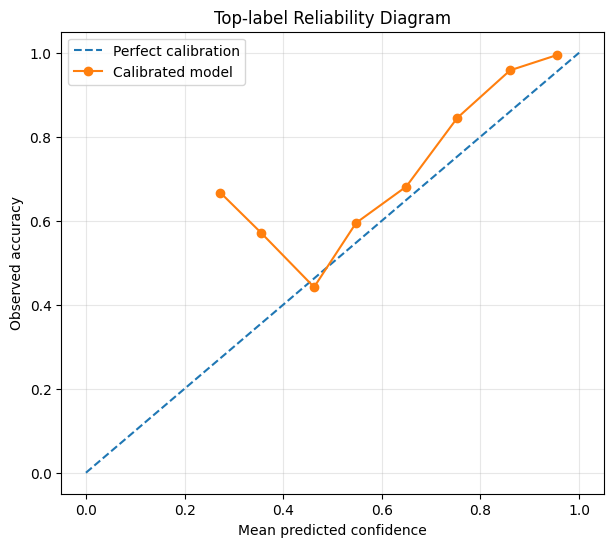

In [38]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(
    calibration_table["Mean Confidence"],
    calibration_table["Accuracy"],
    marker="o",
    label="Calibrated model"
)
plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Top-label Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Confidence-threshold analysis.**

Sweeps possible confidence thresholds from 0.30 to 0.95 and, for each one, measures **coverage** (the fraction of predictions confident enough to be "accepted") against the accuracy/Macro F1 of just the accepted predictions -- quantifying the coverage-vs-quality trade-off referenced in the markdown conclusion below (0.70 chosen as the balanced threshold).

In [39]:
thresholds = np.arange(0.30, 0.96, 0.05)
threshold_rows = []

for threshold in thresholds:
    accepted = confidence >= threshold
    coverage = accepted.mean()

    if accepted.any():
        accepted_y = np.asarray(y_test)[accepted]
        accepted_pred = calibrated_pred[accepted]
        threshold_rows.append({
            "Threshold": threshold,
            "Coverage": coverage,
            "Rejected": 1 - coverage,
            "Accuracy (accepted)": accuracy_score(accepted_y, accepted_pred),
            "Macro F1 (accepted)": f1_score(
                accepted_y, accepted_pred, average="macro", zero_division=0
            )
        })

threshold_results_df = pd.DataFrame(threshold_rows)
threshold_results_df.round(4)

,Threshold,Coverage,Rejected,Accuracy (accepted),Macro F1 (accepted)
0,0.30,0.9991,0.0009,0.8940,0.8616
1,0.35,0.9956,0.0044,0.8961,0.8637
2,0.40,0.9903,0.0097,0.8968,0.8643
3,0.45,0.9819,0.0181,0.9013,0.8704
4,0.50,0.9634,0.0366,0.9095,0.8819
5,0.55,0.9184,0.0816,0.9234,0.8972
6,0.60,0.8794,0.1206,0.9396,0.9115
7,0.65,0.8388,0.1612,0.9545,0.9324
8,0.70,0.8009,0.1991,0.9649,0.9494
9,0.75,0.7506,0.2494,0.9750,0.9621


There is a trade-off between coverage and prediction quality. Increasing the confidence threshold improves the performance of accepted predictions, but reduces coverage.

So we conclude that 0.70 is the most balanced threshold



## Model Explainability — Feature Importance & Local Explanations

**إضافة:** كل التحليلات اللي فاتت (calibration, threshold) بتوضح *مدى ثقة* الموديل في قراره، لكن مفيش أي حاجة بتوضح *ليه* الموديل وصل للقرار ده أصلاً. بما إن `best_model` خطي (Logistic Regression / Linear SVM) أو Naive Bayes، إحنا نقدر نطلع الكلمات (unigrams/bigrams/trigrams) اللي أثرت أكتر على كل كلاس بشكل دقيق ومباشر (من غير الحاجة لمكتبات زي SHAP/LIME)، على مستويين:

1. **Global** — أهم الكلمات اللي بتميّز كل انفعال عن باقي الانفعالات.
2. **Local** — لنص معيّن، إيه بالظبط الكلمات اللي دفعت الموديل يصنفه بالشكل ده.

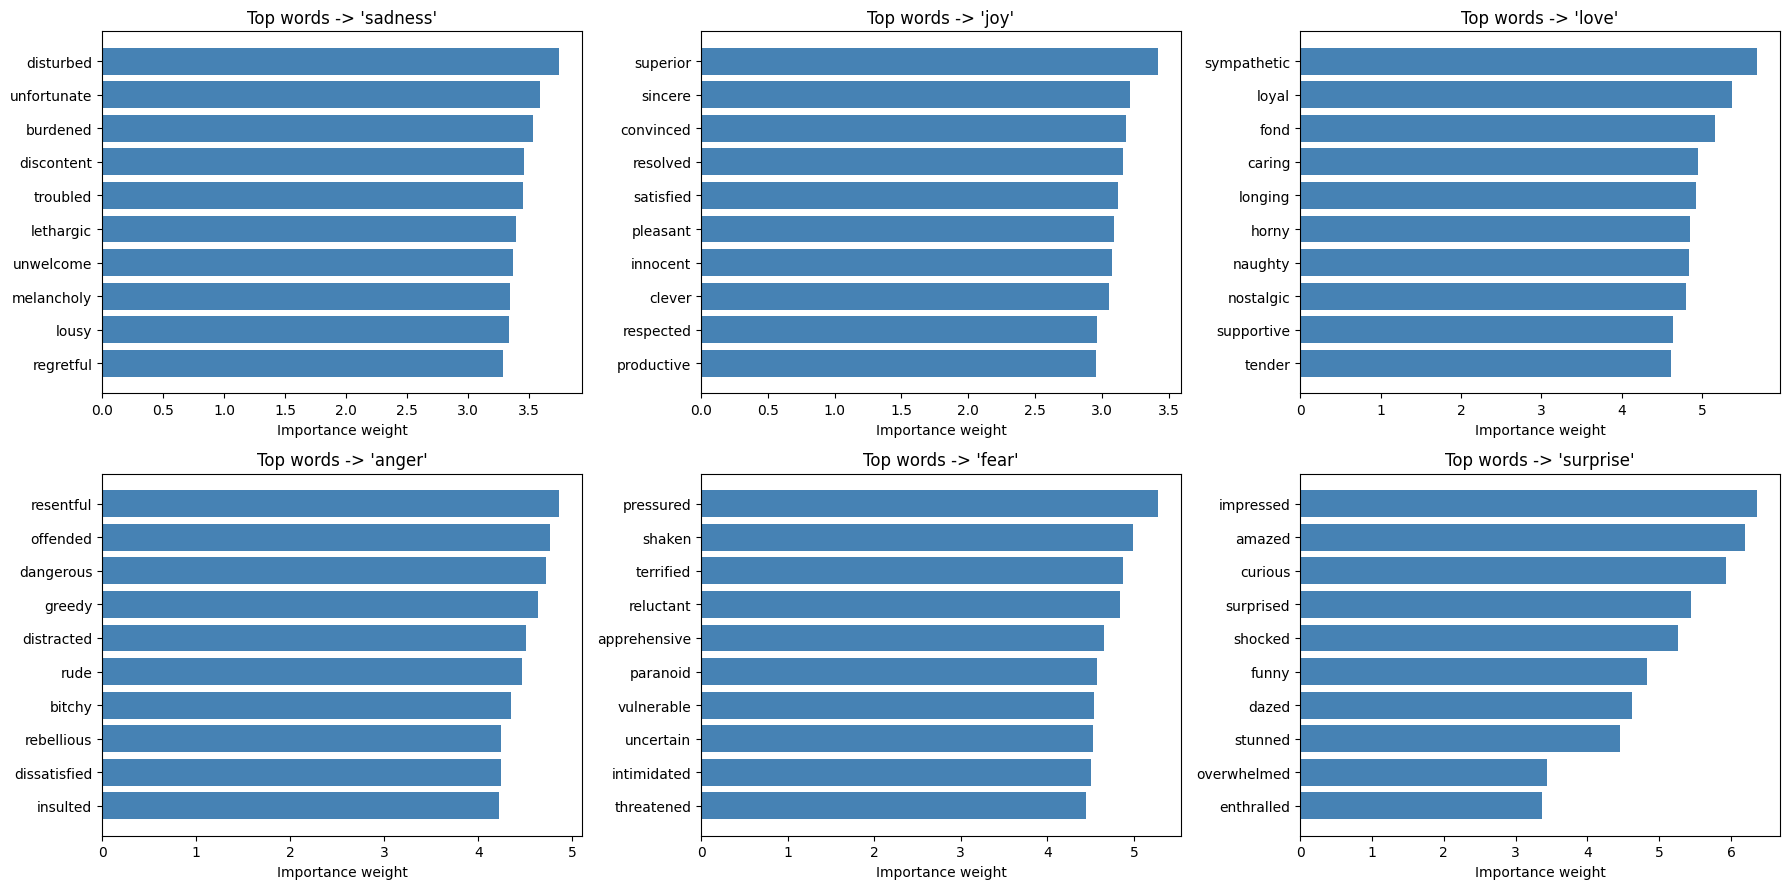

In [40]:
def get_class_weight_matrix(model):
    """Return a (n_classes, n_features) matrix where higher = more indicative of that class."""
    if hasattr(model, "coef_"):
        return model.coef_
    if hasattr(model, "feature_log_prob_"):
        # Center relative to the average across classes so the magnitude reflects
        # how distinctive a word is for this class, not just how common it is overall.
        return model.feature_log_prob_ - model.feature_log_prob_.mean(axis=0, keepdims=True)
    raise TypeError(f"Don't know how to extract feature importances from {type(model).__name__}")


feature_names = best_vectorizer.get_feature_names_out()
weight_matrix = get_class_weight_matrix(best_model)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
top_words_per_class = {}

for i, (emotion, ax) in enumerate(zip(label_names, axes.flatten())):
    top_idx = np.argsort(weight_matrix[i])[::-1][:10]
    top_words = feature_names[top_idx]
    top_weights = weight_matrix[i][top_idx]
    top_words_per_class[emotion] = list(zip(top_words, top_weights.round(4)))

    ax.barh(top_words[::-1], top_weights[::-1], color="steelblue")
    ax.set_title(f"Top words -> '{emotion}'")
    ax.set_xlabel("Importance weight")

plt.tight_layout()
plt.show()

In [41]:
def explain_prediction(text, model, vectorizer, label_names_list, top_k=8):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    weights = get_class_weight_matrix(model)[pred]
    names = vectorizer.get_feature_names_out()

    nz_idx = vec.nonzero()[1]
    contributions = [(names[j], float(weights[j] * vec[0, j])) for j in nz_idx]
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    top = contributions[:top_k]

    print(f"Text: {text}")
    print(f"Predicted emotion: {label_names_list[pred]}")
    print("Top contributing words/n-grams:")
    for word, contrib in top:
        sign = "+" if contrib > 0 else "-"
        print(f"   {sign} {word:<20s} {contrib:+.4f}")
    print()
    return top


sample_texts = X_test.sample(3, random_state=42).tolist()
for t in sample_texts:
    explain_prediction(t, best_model, best_vectorizer, label_names)

Text: im sure ive got it right and my state of unencumberedness despite many years of feeling like i couldnt keep up anybody else is causing me to see my life as charmed
Predicted emotion: joy
Top contributing words/n-grams:
   + charmed              +0.5076
   + sure                 +0.2100
   - causing              -0.1786
   + state                +0.0920
   - many                 -0.0913
   + keep                 +0.0768
   - couldnt              -0.0623
   - of                   -0.0473

Text: i feel these people are utterly useless in my view
Predicted emotion: sadness
Top contributing words/n-grams:
   + useless              +1.0968
   + view                 +0.0929
   - these                -0.0806
   + utterly              +0.0751
   + people               +0.0485
   + feel                 +0.0353
   + my                   +0.0279
   - in                   -0.0235

Text: i feel a despairing sadness because after so much time working on this we have to cut ties
Predicted emotio

---
### ملخص التعديلات في قسم الـ TF-IDF (Part A + TFIDF)

1. **تنظيف الـ Data Loading:** كان فيه `train_test_split` تاني بيتعمل على `df_tokens`
   عشان يجيب `X_train_tokens/X_test_tokens/y_train_tokens/y_test_tokens`، لكن التلاتة
   الأخيرة (`X_test_tokens`, `y_train_tokens`, `y_test_tokens`) ما كانوش بيتستخدموا في
   أي حتة بعد كده — استخدامهم الوحيد كان `X_train_tokens` لبناء الـ vocabulary. استبدلنا
   الخطوة بسطر واحد بياخد نفس صفوف `X_train` من `df_tokens` مباشرة (index-aligned)، فمفيش
   حساب زيادة ومفيش متغيرات ميتة.
2. **توحيد المتاريك:** `evaluate_classifier` كان بيرجع Macro Precision/Recall/F1 +
   Weighted F1 بس (يعني الـ weighted موجودة في الـ F1 بس). دلوقتي بترجع **السبع متاريك
   كاملة**: Accuracy + (Macro & Weighted) لكل من Precision, Recall, F1. التعديل ده
   بيتطبق تلقائيًا على كل جدول بيستخدم الدالة دي (LR, SVM, تجربة الـ n-gram) من غير أي
   تعديل تاني في أماكنهم.
3. **إضافة `max_features`:** أضفناها كبعد تاني جوه نفس تجربة الـ n-gram (مش تجربة
   منفصلة) بقيم `None` (الفوكابيولاري كامل), `10000`, `5000` — يعني بقى عندنا 3 n-gram ×
   3 max_features × 2 موديل = 18 صف، كل صف عليه السبع متاريك. ده خلّى `best_key` محتاج
   يتحدّث كمان (تلات عناصر بدل اتنين) عشان يقدر يلاقي الفيكتورايزر والموديل الصح.
4. **حاجات راجعتها ومقررتش أضيفها:** التحليل بتاع الـ calibration/threshold عندي (في
   نسختي الفردية) بسيط (calibration curve + threshold sweep يدوي لكلاس واحد بس)، لكن
   اللي موجود هنا في نسخة الفريق (`CalibratedClassifierCV` + Brier Score + ECE +
   reliability diagram + coverage/threshold trade-off لكل الكلاسات) أشمل وأقوى منه، فمفيش
   داعي نستبدله أو نضيف حاجة فوقه.

### Phase Summary — TF-IDF Classical ML Track

This phase built and selected the notebook's classical machine-learning baseline end to end. Three model families were compared under identical conditions -- Logistic Regression, Linear SVM, and Multinomial Naive Bayes, all trained on the same TF-IDF features and scored with the same 7-metric `evaluate_classifier()` -- satisfying the "at least 3 classical ML models" requirement rather than the two originally present. A 27-way sweep over n-gram range (unigram / bigram / trigram) and vocabulary cap (full / 10k / 5k) then searched the *representation* space for each of those three model families, and `GridSearchCV` separately searched the *hyperparameter* space of whichever family won, so the final `best_model` reflects two independent rounds of tuning rather than default settings. Beyond raw accuracy, the phase added the analysis a production system actually needs: class-wise precision/recall/F1 to catch weak emotions hidden by a strong macro average, sigmoid calibration with a reliability diagram and Brier/ECE scores so predicted confidence is trustworthy, a coverage-vs-quality threshold sweep that lands on 0.70 as a practical operating point, an out-of-sample sanity check against the dataset's own official test split (never touched anywhere else in the notebook) to confirm the result generalizes beyond our own random split, and finally an explainability layer that exposes both *global* top words per emotion and *local*, per-prediction word contributions -- all without adding a SHAP/LIME dependency, since the winning models are linear or Naive Bayes and expose this directly through their own weights. The output of this phase -- `best_model`, `best_vectorizer`, and `calibrated_model` -- is what gets saved for deployment much later in the notebook.

# Deep Learning Track — we used PyTorch

The merge plan calls for six deep-learning architectures compared head-to-head, not
three: an embedding-based MLP, a CNN, and **four** recurrent variants (RNN, LSTM,
GRU, BiLSTM), trained with early stopping and learning-rate scheduling. We reuse the
padded sequences (`padded_all_train`, `padded_all_test`) and vocabulary (`tok_all`,
`all_words`) already prepared for the classical models, and build all six
architectures in PyTorch so every model is trained and evaluated the exact same way
(same loaders, same `train_model` / `evaluate_torch_model` functions, same class
weights) and the comparison is fair.

Imports for the whole Deep Learning track: PyTorch core (`torch`, `nn`, `optim`), `Dataset`/`DataLoader` for batching, `compute_class_weight` for imbalance handling, `confusion_matrix` for error analysis, and `seaborn` for plotting.

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

Sets up the shared tensors every PyTorch model trains on: picks GPU if available, fixes `vocab_size`/`maxlen`/`embedding_dim`/`num_classes`, and converts the already-padded sequences and labels (`padded_all_train`, `padded_all_test`, `y_train`, `y_test` -- built back in the Tokenization phase) into `torch.long` tensors.

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(all_words) + 1
maxlen = 41
embedding_dim = 100
num_classes = len(label_names)

X_train_t = torch.tensor(padded_all_train, dtype=torch.long)
X_test_t  = torch.tensor(padded_all_test, dtype=torch.long)
y_train_t = torch.tensor(np.asarray(y_train), dtype=torch.long)
y_test_t  = torch.tensor(np.asarray(y_test), dtype=torch.long)

## Class Weights

The label distribution was shown to be imbalanced in the earlier EDA step, but nothing in
the pipeline corrected for it. We compute balanced class weights from the training labels
and pass them into the loss function for every PyTorch model, so the loss penalizes
mistakes on minority emotions more heavily instead of letting the majority class dominate.

Computes per-class **balanced weights** from the training label distribution with `compute_class_weight`, converts them to a tensor on the active device, and prints one weight per emotion. `class_weights_t` is passed into `CrossEntropyLoss` for every one of the six architectures below, so minority emotions are penalized more heavily during training.

In [44]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=np.asarray(y_train)
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for name, w in zip(label_names, class_weights):
    print(f"  {name}: {w:.4f}")

Class weights:
  sadness: 0.5715
  joy: 0.4973
  love: 2.0454
  anger: 1.2353
  fear: 1.3763
  surprise: 4.6681


## Datasets and DataLoaders

We wrap the padded sequences and labels in a PyTorch `Dataset`, then split 10% of the
training data into a validation set — this mirrors `validation_split=0.1` from Keras and
gives early stopping / LR scheduling something to monitor each epoch.

Defines a minimal PyTorch `Dataset` wrapper, carves out a 10% validation split from the training tensors (mirroring Keras's `validation_split=0.1`), and builds the `train_loader` / `val_loader` / `test_loader` `DataLoader`s shared by every model below.

In [45]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

n_val = int(0.1 * len(X_train_t))
perm = torch.randperm(len(X_train_t))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

train_ds = EmotionDataset(X_train_t[tr_idx], y_train_t[tr_idx])
val_ds   = EmotionDataset(X_train_t[val_idx], y_train_t[val_idx])
test_ds  = EmotionDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

## Shared Training and Evaluation Functions

The training loop now uses the weighted `CrossEntropyLoss` and adds `weight_decay` to
Adam for regularization. The evaluation function additionally returns raw predictions and
true labels (not just metrics), so we can build a confusion matrix per model without
re-running inference.

Defines `train_model()`, the single training loop reused by all six architectures: weighted `CrossEntropyLoss` (using `class_weights_t`), Adam with `weight_decay` for L2 regularization, a `ReduceLROnPlateau` learning-rate scheduler, and early stopping on validation loss (`patience` epochs without improvement). It returns the trained model plus a `history` dict of per-epoch train/val loss and accuracy, used later for the training-curve plots.

In [46]:
def train_model(model, train_loader, val_loader, epochs=20, patience=3, lr=1e-3, weight_decay=1e-5):
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            train_correct += (out.argmax(dim=1) == yb).sum().item()
            train_total += xb.size(0)
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (out.argmax(dim=1) == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


Defines `evaluate_torch_model()`, the shared evaluation function: runs the model over a `DataLoader` in `eval()` mode (no gradients), collects predictions, and returns the same 7-metric dictionary used for the classical models -- plus the raw predictions/true labels, so a confusion matrix or class-wise report can be built without a second inference pass.

In [47]:
def evaluate_torch_model(model, loader, name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(all_true, all_preds),
        "Macro Precision": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted Precision": precision_score(all_true, all_preds, average="weighted", zero_division=0),
        "Macro Recall": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted Recall": recall_score(all_true, all_preds, average="weighted", zero_division=0),
        "Macro F1": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(all_true, all_preds, average="weighted", zero_division=0)
    }
    return metrics, np.array(all_true), np.array(all_preds)


Defines `plot_confusion()`, a shared plotting helper: draws a model's confusion matrix, and -- when a `history` dict is passed -- also plots its accuracy and loss curves side by side, so one function call gives the complete picture for any of the six models.

In [48]:
def plot_confusion(y_true, y_pred, name, history=None):
    """Confusion matrix for any model. If `history` is passed (train_loss/val_loss/
    train_acc/val_acc from train_model), also plots the accuracy and loss curves next
    to it, so one call gives the full picture for a model instead of two separate ones."""
    if history is not None:
        fig, (ax_acc, ax_loss, ax_cm) = plt.subplots(1, 3, figsize=(18, 5))

        ax_acc.plot(history['train_acc'], label='train')
        ax_acc.plot(history['val_acc'], label='validation')
        ax_acc.set_title(f'Accuracy — {name}')
        ax_acc.set_xlabel('Epoch'); ax_acc.legend()

        ax_loss.plot(history['train_loss'], label='train')
        ax_loss.plot(history['val_loss'], label='validation')
        ax_loss.set_title(f'Loss — {name}')
        ax_loss.set_xlabel('Epoch'); ax_loss.legend()

        cm = confusion_matrix(y_true, y_pred, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=label_names, yticklabels=label_names,
                    cmap='Blues', ax=ax_cm)
        ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
        ax_cm.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout()
        plt.show()
    else:
        cm = confusion_matrix(y_true, y_pred, normalize='true')
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.title(f'Normalized Confusion Matrix — {name}')
        plt.show()

dl_results = []
dl_predictions = {}

**تعديل (توحيد الست موديلات):** الموديلين الأول والتاني (`Embedding MLP`, `CNN`) كانوا
بينادوا `train_model` بالـ defaults، بينما التلات موديلات اللي اتضافوا بعدين
(`RNN`, `LSTM`, `GRU`) وكمان `BiLSTM` كانوا بيبعتوا `patience=4` صراحة — يعني مكنش
فيه نفس المعاملة بالظبط للست موديلات. دلوقتي الست نداءات بقوا صريحين ومتطابقين
تمامًا (`epochs=20, patience=4, lr=1e-3, weight_decay=1e-5`)، فالمقارنة بينهم بقت
عادلة 100% (بريبروسسنج وتدريب موحّدين من `tok_all`/`padded_all_train` المشتركين
لحد آخر تفاصيل التدريب). كمان `train_model` دلوقتي بيحسب ويطبع `train_acc`/`val_acc`
جنب `train_loss`/`val_loss` في كل Epoch لكل موديل، مش الـ loss بس.


## 1. Embedding-Based MLP Baseline (Masked Pooling)

The original average-pooling implementation included padding-token embeddings in the
mean, which distorts the sentence vector for short sequences padded heavily up to
`maxlen=41`. This version masks out padding positions before averaging, so only real
tokens contribute — matching what Keras's `GlobalAveragePooling1D` does when
`mask_zero=True` is set on the embedding layer.

Defines and trains the **Embedding MLP** baseline: an embedding layer, **masked** average-pooling over real (non-padding) tokens only, then a small dense head (`fc1` -> dropout -> `fc2`). Trains via the shared `train_model()` and evaluates via `evaluate_torch_model()`.

Epoch 1/30 - train_loss: 1.7681 - train_acc: 0.2240 - val_loss: 1.7171 - val_acc: 0.3227 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.6082 - train_acc: 0.3365 - val_loss: 1.4773 - val_acc: 0.3703 - lr: 1.00e-03
Epoch 3/30 - train_loss: 1.2281 - train_acc: 0.4881 - val_loss: 1.0804 - val_acc: 0.5312 - lr: 1.00e-03
Epoch 4/30 - train_loss: 0.8206 - train_acc: 0.6772 - val_loss: 0.7822 - val_acc: 0.7203 - lr: 1.00e-03
Epoch 5/30 - train_loss: 0.5415 - train_acc: 0.7989 - val_loss: 0.6086 - val_acc: 0.7961 - lr: 1.00e-03
Epoch 6/30 - train_loss: 0.3796 - train_acc: 0.8663 - val_loss: 0.5100 - val_acc: 0.8328 - lr: 1.00e-03
Epoch 7/30 - train_loss: 0.2749 - train_acc: 0.9076 - val_loss: 0.4804 - val_acc: 0.8516 - lr: 1.00e-03
Epoch 8/30 - train_loss: 0.2068 - train_acc: 0.9346 - val_loss: 0.4574 - val_acc: 0.8617 - lr: 1.00e-03
Epoch 9/30 - train_loss: 0.1676 - train_acc: 0.9470 - val_loss: 0.4363 - val_acc: 0.8688 - lr: 1.00e-03
Epoch 10/30 - train_loss: 0.1341 - train_acc: 0.9616 - val_loss:

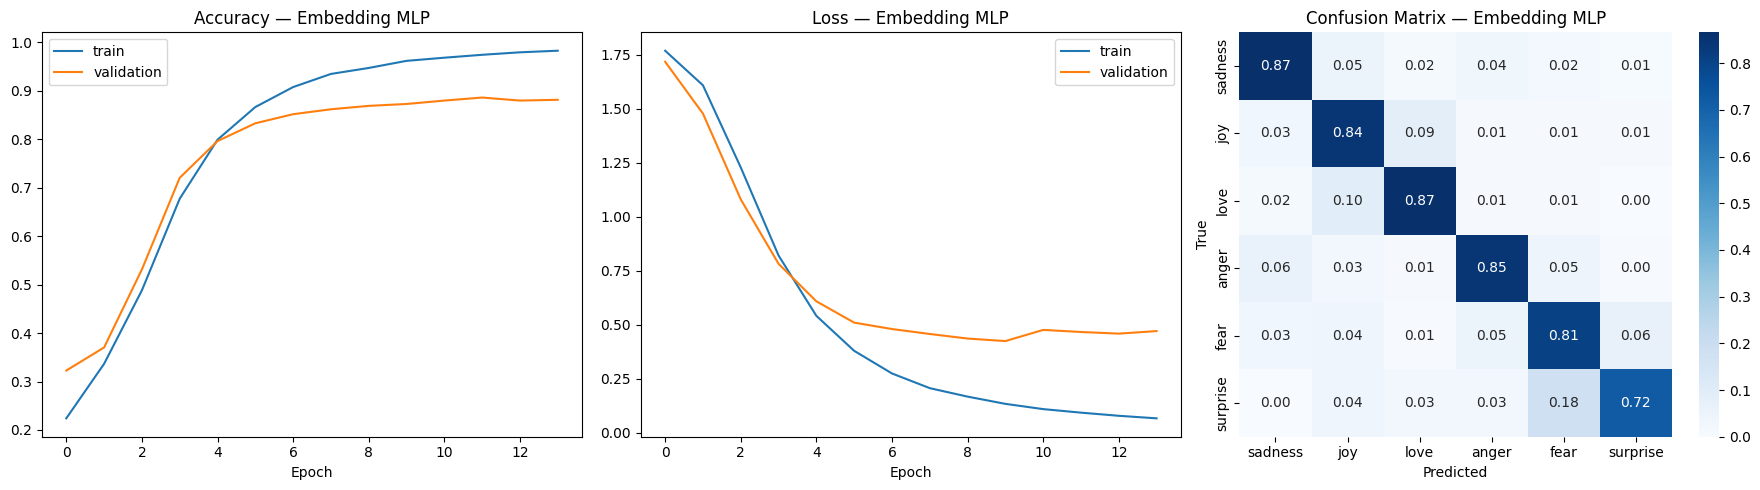

In [49]:
class EmbeddingMLP(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        summed = (emb * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled = summed / counts
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        return self.fc2(h)

mlp_model = EmbeddingMLP(vocab_size, embedding_dim, num_classes)
mlp_model, mlp_history = train_model(mlp_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

mlp_metrics, mlp_true, mlp_pred = evaluate_torch_model(mlp_model, test_loader, "Embedding MLP")
dl_results.append(mlp_metrics)
dl_predictions["Embedding MLP"] = (mlp_true, mlp_pred)
plot_confusion(mlp_true, mlp_pred, "Embedding MLP", mlp_history)

## 2. CNN Baseline

Unchanged architecture — max-pooling over convolution outputs is much less sensitive to
padding than average-pooling, since padding embeddings sit near zero and rarely win the
max. Weight decay and class weighting still apply through the shared training function.

Defines and trains the **CNN** baseline: an embedding layer feeding a 1D convolution (kernel size 5) over the sequence, max-pooled over time, then the same dense head as the MLP. Max-pooling makes this architecture naturally robust to padding (padding embeddings sit near zero and rarely win the max).

Epoch 1/30 - train_loss: 1.7797 - train_acc: 0.2113 - val_loss: 1.6938 - val_acc: 0.2297 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.3654 - train_acc: 0.3748 - val_loss: 1.0051 - val_acc: 0.5617 - lr: 1.00e-03
Epoch 3/30 - train_loss: 0.7042 - train_acc: 0.6671 - val_loss: 0.5684 - val_acc: 0.7797 - lr: 1.00e-03
Epoch 4/30 - train_loss: 0.3718 - train_acc: 0.8425 - val_loss: 0.5008 - val_acc: 0.8352 - lr: 1.00e-03
Epoch 5/30 - train_loss: 0.2085 - train_acc: 0.9206 - val_loss: 0.4104 - val_acc: 0.8664 - lr: 1.00e-03
Epoch 6/30 - train_loss: 0.1492 - train_acc: 0.9472 - val_loss: 0.4206 - val_acc: 0.8719 - lr: 1.00e-03
Epoch 7/30 - train_loss: 0.0985 - train_acc: 0.9644 - val_loss: 0.4784 - val_acc: 0.8812 - lr: 1.00e-03
Epoch 8/30 - train_loss: 0.0752 - train_acc: 0.9737 - val_loss: 0.4697 - val_acc: 0.8969 - lr: 5.00e-04
Epoch 9/30 - train_loss: 0.0461 - train_acc: 0.9845 - val_loss: 0.5842 - val_acc: 0.9023 - lr: 5.00e-04
Early stopping at epoch 9


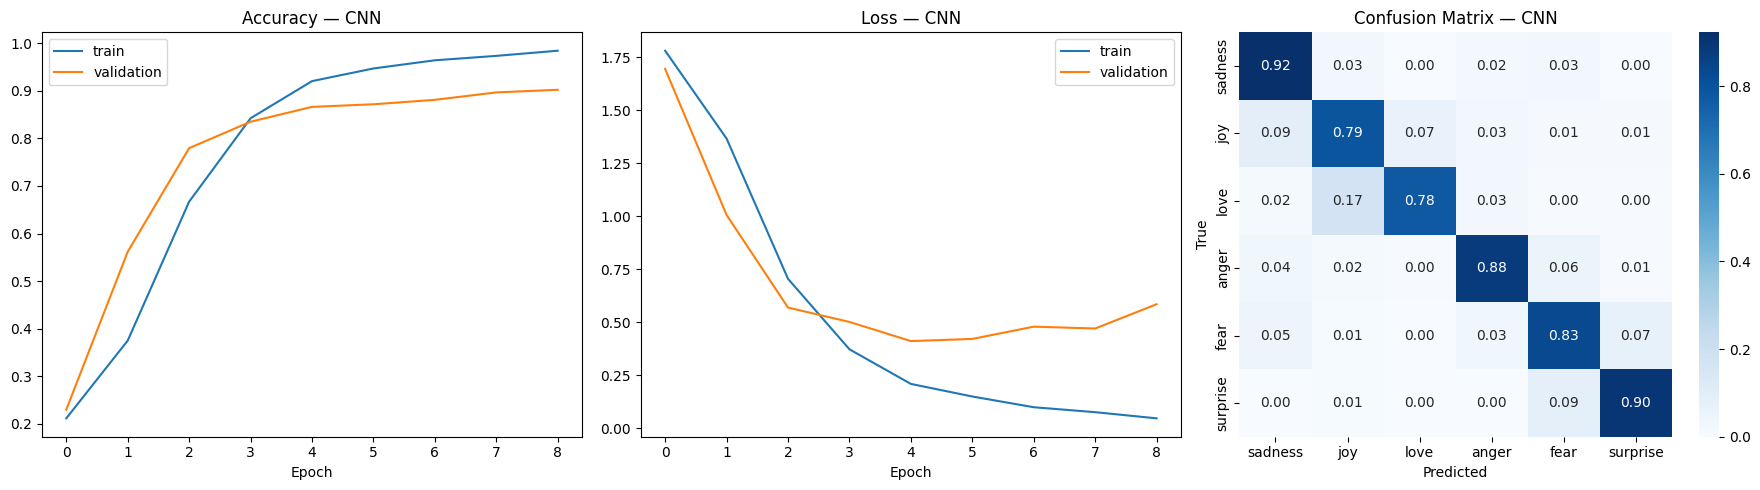

In [50]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters=128, kernel_size=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=kernel_size)
        self.fc1 = nn.Linear(num_filters, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.permute(0, 2, 1)
        conv_out = torch.relu(self.conv(emb))
        pooled = torch.max(conv_out, dim=2)[0]
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        return self.fc2(h)

cnn_model = TextCNN(vocab_size, embedding_dim, num_classes)
cnn_model, cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

cnn_metrics, cnn_true, cnn_pred = evaluate_torch_model(cnn_model, test_loader, "CNN")
dl_results.append(cnn_metrics)
dl_predictions["CNN"] = (cnn_true, cnn_pred)
plot_confusion(cnn_true, cnn_pred, "CNN", cnn_history)

## 3. BiLSTM Sequence Classifier

Unchanged architecture — the final forward/backward hidden states already ignore padding
positions structurally in the sense that they summarize the whole processed sequence
rather than averaging over it, so no masked-pooling fix is needed here. Weight decay and
class weighting still apply.

Defines and trains the **BiLSTM** classifier: a bidirectional LSTM whose final forward and backward hidden states are concatenated and fed through the dense head. Bidirectionality lets the model use context from both directions of each sentence.

Epoch 1/30 - train_loss: 1.7872 - train_acc: 0.2497 - val_loss: 1.7527 - val_acc: 0.2109 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.5407 - train_acc: 0.2816 - val_loss: 1.3338 - val_acc: 0.3867 - lr: 1.00e-03
Epoch 3/30 - train_loss: 1.0384 - train_acc: 0.5332 - val_loss: 0.9085 - val_acc: 0.6414 - lr: 1.00e-03
Epoch 4/30 - train_loss: 0.6383 - train_acc: 0.7471 - val_loss: 0.6503 - val_acc: 0.7328 - lr: 1.00e-03
Epoch 5/30 - train_loss: 0.4105 - train_acc: 0.8495 - val_loss: 0.5734 - val_acc: 0.8078 - lr: 1.00e-03
Epoch 6/30 - train_loss: 0.2699 - train_acc: 0.9019 - val_loss: 0.6855 - val_acc: 0.8328 - lr: 1.00e-03
Epoch 7/30 - train_loss: 0.2000 - train_acc: 0.9290 - val_loss: 0.8659 - val_acc: 0.8094 - lr: 1.00e-03
Epoch 8/30 - train_loss: 0.1802 - train_acc: 0.9348 - val_loss: 0.7735 - val_acc: 0.8445 - lr: 5.00e-04
Epoch 9/30 - train_loss: 0.1187 - train_acc: 0.9606 - val_loss: 0.6355 - val_acc: 0.8547 - lr: 5.00e-04
Early stopping at epoch 9


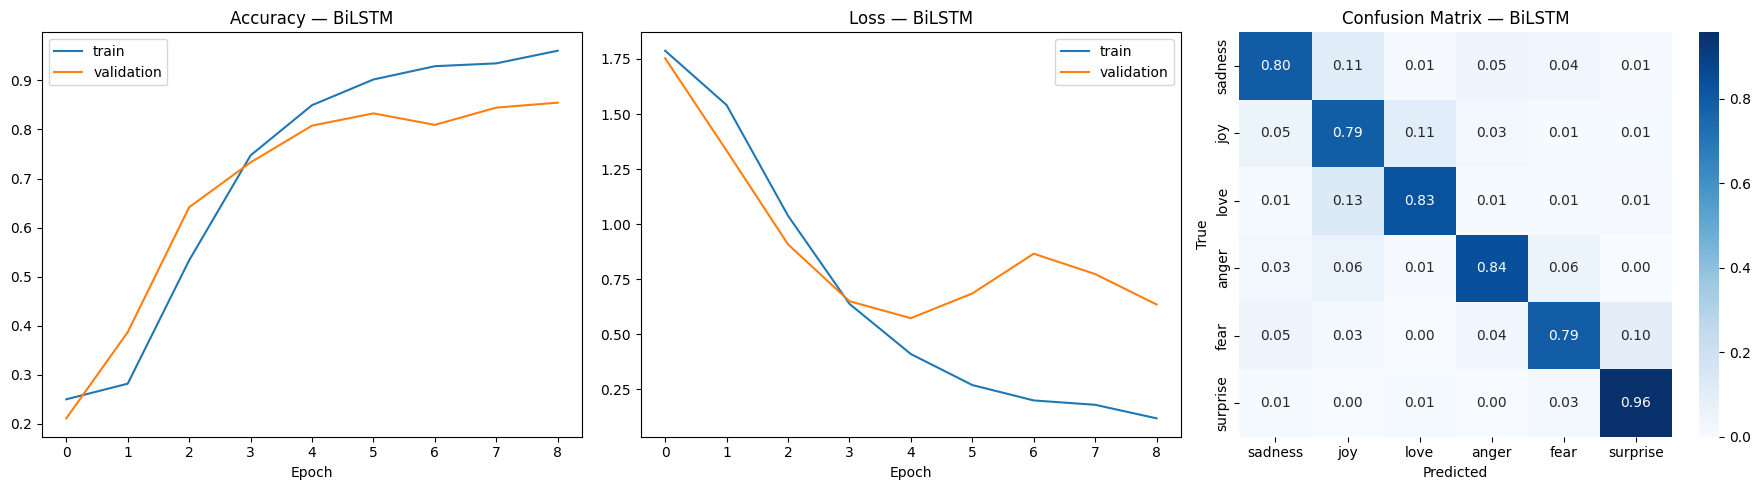

In [51]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (hidden, _) = self.lstm(emb)
        h = torch.cat((hidden[0], hidden[1]), dim=1)
        h = torch.relu(self.fc1(h))
        h = self.dropout(h)
        return self.fc2(h)

lstm_model = BiLSTMClassifier(vocab_size, embedding_dim, num_classes)
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

lstm_metrics, lstm_true, lstm_pred = evaluate_torch_model(lstm_model, test_loader, "BiLSTM")
dl_results.append(lstm_metrics)
dl_predictions["BiLSTM"] = (lstm_true, lstm_pred)
plot_confusion(lstm_true, lstm_pred, "BiLSTM", lstm_history)

## 4. Simple RNN (Vanilla Recurrent) Classifier

Added (with LSTM and GRU below) to complete the six-architecture comparison the merge
plan calls for. A plain `nn.RNN` has no gating mechanism, so it is the most likely of
the four recurrent variants to struggle with longer-range dependencies (vanishing
gradients). We take the final hidden state (single direction, no attention) and reuse
the exact same fc1 → dropout → fc2 head as the other models, so any performance
difference comes from the recurrent cell itself, not from the classifier head.

Defines `SpatialDropout1D` (drops entire embedding channels at once, like Keras's layer of the same name, rather than independent per-element dropout) and the **plain RNN** classifier built on top of it: embedding -> spatial dropout -> vanilla (ungated) bidirectional `nn.RNN` -> batch norm -> dense head. This is the architecture most likely to struggle with longer-range dependencies, since a plain RNN has no gating mechanism.

Epoch 1/30 - train_loss: 1.7999 - train_acc: 0.1538 - val_loss: 1.7913 - val_acc: 0.1695 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.7859 - train_acc: 0.1924 - val_loss: 1.7806 - val_acc: 0.2266 - lr: 1.00e-03
Epoch 3/30 - train_loss: 1.7733 - train_acc: 0.2321 - val_loss: 1.7706 - val_acc: 0.2391 - lr: 1.00e-03
Epoch 4/30 - train_loss: 1.7507 - train_acc: 0.2168 - val_loss: 1.7297 - val_acc: 0.2602 - lr: 1.00e-03
Epoch 5/30 - train_loss: 1.6966 - train_acc: 0.2234 - val_loss: 1.6322 - val_acc: 0.2914 - lr: 1.00e-03
Epoch 6/30 - train_loss: 1.5787 - train_acc: 0.2415 - val_loss: 1.5313 - val_acc: 0.3203 - lr: 1.00e-03
Epoch 7/30 - train_loss: 1.4861 - train_acc: 0.2727 - val_loss: 1.4294 - val_acc: 0.3125 - lr: 1.00e-03
Epoch 8/30 - train_loss: 1.4080 - train_acc: 0.2939 - val_loss: 1.3043 - val_acc: 0.4055 - lr: 1.00e-03
Epoch 9/30 - train_loss: 1.2989 - train_acc: 0.3290 - val_loss: 1.1481 - val_acc: 0.4562 - lr: 1.00e-03
Epoch 10/30 - train_loss: 1.2137 - train_acc: 0.3723 - val_loss:

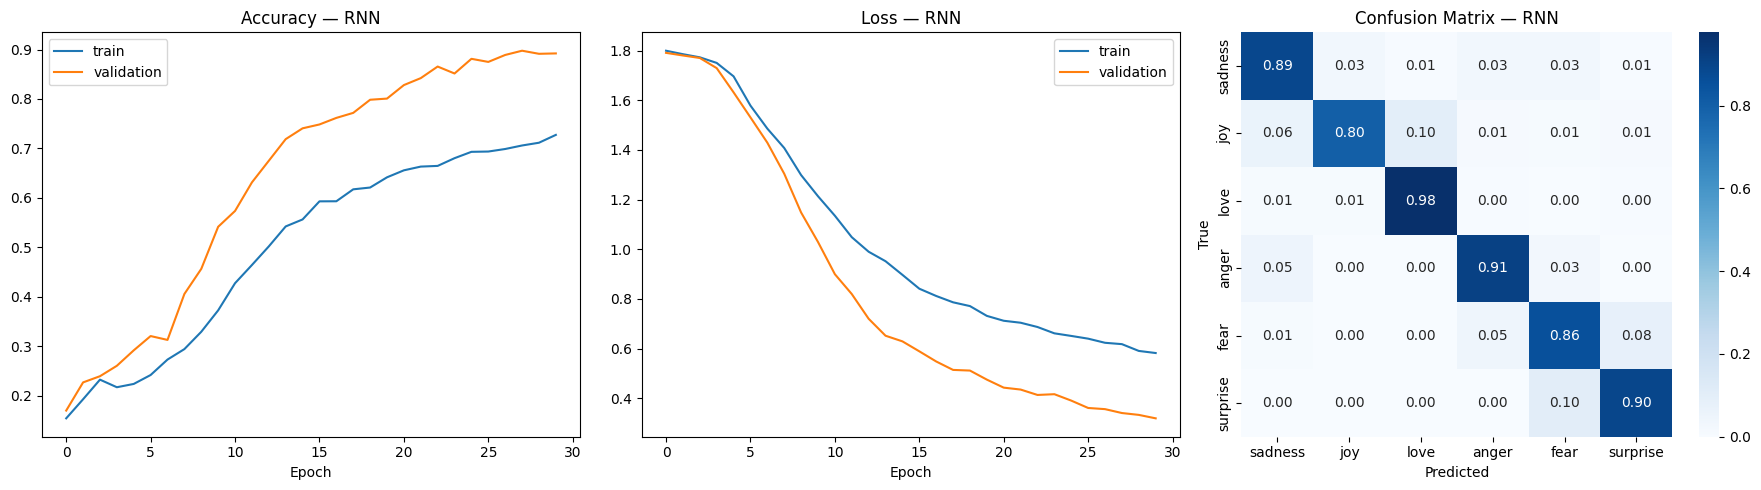

In [52]:
class SpatialDropout1D(nn.Module):
    """Same idea as Keras' SpatialDropout1D: drops whole embedding channels for every
    timestep at once, instead of independent per-element dropout."""
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0:
            return x
        mask = x.new_empty(x.size(0), 1, x.size(2)).bernoulli_(1 - self.p) / (1 - self.p)
        return x * mask


class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_classes=6, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.spatial_dropout = SpatialDropout1D(0.2)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 8)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.spatial_dropout(emb)
        out, _ = self.rnn(emb)
        pooled = torch.max(out, dim=1)[0]
        pooled = self.bn(pooled)
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        return self.fc2(h)

rnn_model = RNNClassifier(vocab_size, embedding_dim=64, num_classes=num_classes, hidden_dim=16)
rnn_model, rnn_history = train_model(rnn_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

rnn_metrics, rnn_true, rnn_pred = evaluate_torch_model(rnn_model, test_loader, "RNN")
dl_results.append(rnn_metrics)
dl_predictions["RNN"] = (rnn_true, rnn_pred)
plot_confusion(rnn_true, rnn_pred, "RNN", rnn_history)

## 5. Unidirectional LSTM Classifier

A single-direction LSTM, as opposed to the bidirectional `BiLSTM` further down.
Comparing the two isolates the effect of bidirectionality on this dataset: if BiLSTM
clearly beats this LSTM, the backward pass is adding real signal; if the two are
close, the extra parameters and compute of BiLSTM aren't paying off much on these
short, tweet-length sequences.

Defines and trains the **unidirectional LSTM** classifier (gated, single direction, max-pooled over time steps) -- comparing it against the BiLSTM above isolates how much bidirectionality alone is worth on this dataset.

Epoch 1/30 - train_loss: 1.8036 - train_acc: 0.1558 - val_loss: 1.7731 - val_acc: 0.2148 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.7723 - train_acc: 0.2263 - val_loss: 1.7447 - val_acc: 0.2781 - lr: 1.00e-03
Epoch 3/30 - train_loss: 1.7270 - train_acc: 0.2566 - val_loss: 1.6457 - val_acc: 0.3094 - lr: 1.00e-03
Epoch 4/30 - train_loss: 1.5646 - train_acc: 0.2786 - val_loss: 1.3319 - val_acc: 0.4305 - lr: 1.00e-03
Epoch 5/30 - train_loss: 1.3728 - train_acc: 0.3332 - val_loss: 1.1093 - val_acc: 0.5242 - lr: 1.00e-03
Epoch 6/30 - train_loss: 1.2374 - train_acc: 0.3997 - val_loss: 0.9589 - val_acc: 0.5984 - lr: 1.00e-03
Epoch 7/30 - train_loss: 1.1404 - train_acc: 0.4518 - val_loss: 0.8437 - val_acc: 0.6805 - lr: 1.00e-03
Epoch 8/30 - train_loss: 1.0512 - train_acc: 0.4936 - val_loss: 0.7218 - val_acc: 0.7102 - lr: 1.00e-03
Epoch 9/30 - train_loss: 0.9811 - train_acc: 0.5205 - val_loss: 0.6372 - val_acc: 0.7633 - lr: 1.00e-03
Epoch 10/30 - train_loss: 0.8984 - train_acc: 0.5649 - val_loss:

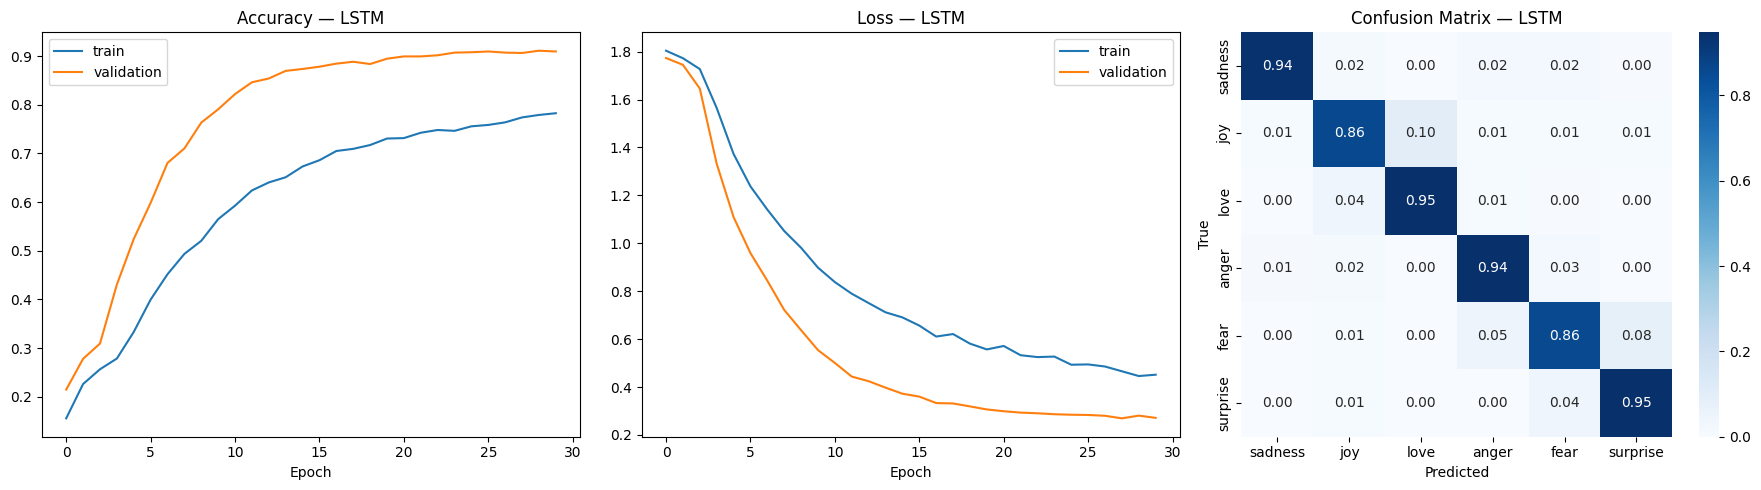

In [53]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_classes=6, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.spatial_dropout = SpatialDropout1D(0.2)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 8)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.spatial_dropout(emb)
        out, _ = self.lstm(emb)
        pooled = torch.max(out, dim=1)[0]
        pooled = self.bn(pooled)
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        return self.fc2(h)

lstm_uni_model = LSTMClassifier(vocab_size, embedding_dim=64, num_classes=num_classes, hidden_dim=16)
lstm_uni_model, lstm_uni_history = train_model(lstm_uni_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

lstm_uni_metrics, lstm_uni_true, lstm_uni_pred = evaluate_torch_model(lstm_uni_model, test_loader, "LSTM")
dl_results.append(lstm_uni_metrics)
dl_predictions["LSTM"] = (lstm_uni_true, lstm_uni_pred)
plot_confusion(lstm_uni_true, lstm_uni_pred, "LSTM", lstm_uni_history)

## 6. GRU Classifier

GRU uses a simpler gating mechanism than LSTM (two gates, no separate cell state), so
it trains with fewer parameters. Including it alongside RNN/LSTM/BiLSTM completes the
sweep the merge plan asked for — from no gating (RNN), to partial gating (GRU), to
full gating (LSTM/BiLSTM) — all trained and evaluated identically.

Defines and trains the **GRU** classifier -- architecturally between the plain RNN (no gating) and the LSTM/BiLSTM (full gating): GRU uses a simpler two-gate mechanism with no separate cell state, so it has fewer parameters to train.

Epoch 1/30 - train_loss: 1.8018 - train_acc: 0.1485 - val_loss: 1.7840 - val_acc: 0.1836 - lr: 1.00e-03
Epoch 2/30 - train_loss: 1.7781 - train_acc: 0.1941 - val_loss: 1.7533 - val_acc: 0.2437 - lr: 1.00e-03
Epoch 3/30 - train_loss: 1.7422 - train_acc: 0.2138 - val_loss: 1.6812 - val_acc: 0.3133 - lr: 1.00e-03
Epoch 4/30 - train_loss: 1.6578 - train_acc: 0.2495 - val_loss: 1.5150 - val_acc: 0.3469 - lr: 1.00e-03
Epoch 5/30 - train_loss: 1.5246 - train_acc: 0.2763 - val_loss: 1.3171 - val_acc: 0.4078 - lr: 1.00e-03
Epoch 6/30 - train_loss: 1.3809 - train_acc: 0.3278 - val_loss: 1.1601 - val_acc: 0.4859 - lr: 1.00e-03
Epoch 7/30 - train_loss: 1.2642 - train_acc: 0.3752 - val_loss: 1.0240 - val_acc: 0.5750 - lr: 1.00e-03
Epoch 8/30 - train_loss: 1.1464 - train_acc: 0.4207 - val_loss: 0.8670 - val_acc: 0.6367 - lr: 1.00e-03
Epoch 9/30 - train_loss: 1.0542 - train_acc: 0.4670 - val_loss: 0.7381 - val_acc: 0.6977 - lr: 1.00e-03
Epoch 10/30 - train_loss: 0.9796 - train_acc: 0.5266 - val_loss:

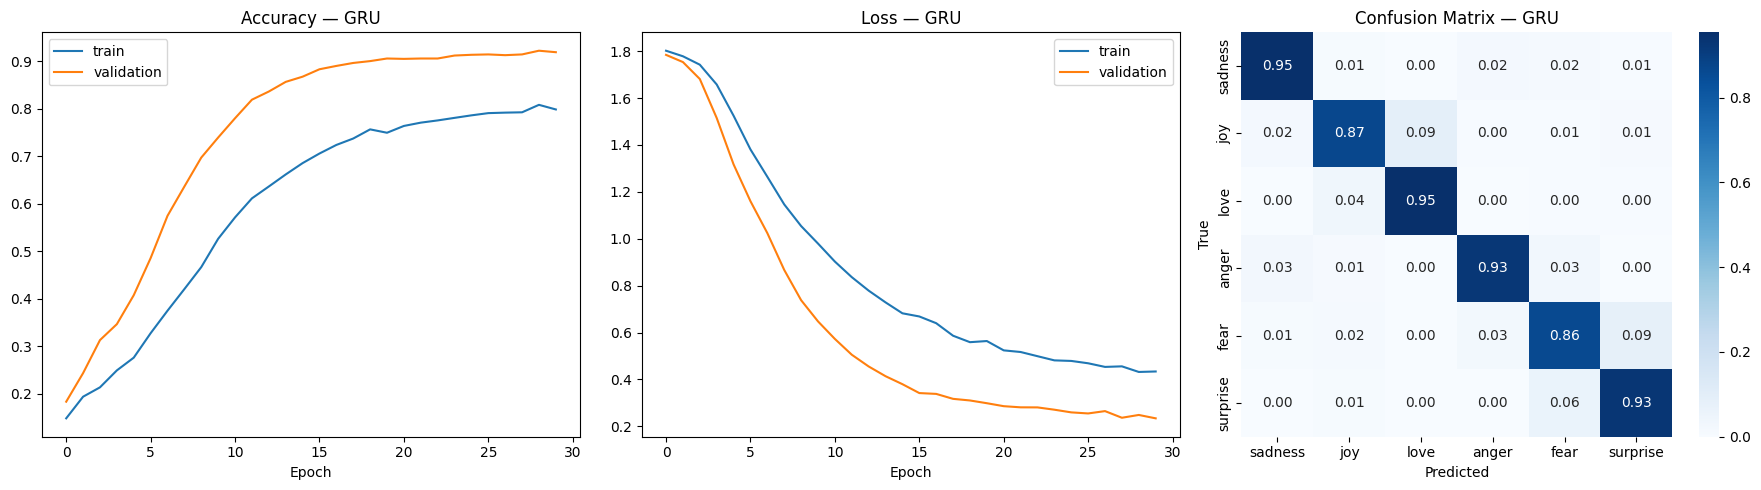

In [54]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_classes=6, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.spatial_dropout = SpatialDropout1D(0.2)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 8)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.spatial_dropout(emb)
        out, _ = self.gru(emb)
        pooled = torch.max(out, dim=1)[0]
        pooled = self.bn(pooled)
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        return self.fc2(h)

gru_model = GRUClassifier(vocab_size, embedding_dim=64, num_classes=num_classes, hidden_dim=16)
gru_model, gru_history = train_model(gru_model, train_loader, val_loader, epochs=30, patience=4, lr=1e-3, weight_decay=1e-5)

gru_metrics, gru_true, gru_pred = evaluate_torch_model(gru_model, test_loader, "GRU")
dl_results.append(gru_metrics)
dl_predictions["GRU"] = (gru_true, gru_pred)
plot_confusion(gru_true, gru_pred, "GRU", gru_history)

## Compare Classical NLP vs Deep Learning

Comprehensive comparison: the **2 classical ML models** (best n-gram / max_features
configuration found for each of Logistic Regression and Linear SVM) plus all
**6 deep-learning architectures** (Embedding MLP, CNN, RNN, LSTM, GRU, BiLSTM) — 8
models total, all scored on the same 7 metrics (Accuracy + Macro/Weighted
Precision/Recall/F1).

Assembles `dl_results_df` from all six PyTorch models' stored metrics, then pulls the single best-performing sweep row for Logistic Regression and for Linear SVM out of `ngram_results_df` into `ml_rows` -- giving a 2-row classical block that, concatenated with `dl_results_df`, becomes `full_comparison`: every classical and deep-learning model's best configuration on one shared table, sorted by Macro F1. **Note:** Multinomial Naive Bayes was trained in the same 27-row sweep above (satisfying "at least 3 classical models" there), but its best row is never pulled in here -- `ml_rows`, and therefore every downstream comparison table built from it, only carries Logistic Regression and Linear SVM. If you want Naive Bayes represented in the final ranking too, this cell needs a third `best_nb_row` block mirroring the LR/SVM one exactly.

In [55]:
dl_results_df = pd.DataFrame(dl_results).set_index("Model")

metric_cols = ["Accuracy", "Macro Precision", "Weighted Precision",
               "Macro Recall", "Weighted Recall", "Macro F1", "Weighted F1"]

best_lr_row = ngram_results_df[ngram_results_df["Model"] == "Logistic Regression"].loc[
    ngram_results_df[ngram_results_df["Model"] == "Logistic Regression"]["Macro F1"].idxmax()
]
best_svm_row = ngram_results_df[ngram_results_df["Model"] == "Linear SVM"].loc[
    ngram_results_df[ngram_results_df["Model"] == "Linear SVM"]["Macro F1"].idxmax()
]

ml_rows = pd.DataFrame(
    [best_lr_row[metric_cols].values, best_svm_row[metric_cols].values],
    columns=metric_cols,
    index=[
        f"TF-IDF + Logistic Regression ({best_lr_row['N-gram']}, max_features={best_lr_row['Max Features']})",
        f"TF-IDF + Linear SVM ({best_svm_row['N-gram']}, max_features={best_svm_row['Max Features']})"
    ]
)
ml_rows.index.name = "Model"

# classical_row = the single best-of-the-best classical model (used later for the
# three-way comparison against the best DL model and the Transformer).
classical_row = pd.DataFrame([{
    "Accuracy": best_row["Accuracy"],
    "Macro Precision": best_row["Macro Precision"],
    "Weighted Precision": best_row["Weighted Precision"],
    "Macro Recall": best_row["Macro Recall"],
    "Weighted Recall": best_row["Weighted Recall"],
    "Macro F1": best_row["Macro F1"],
    "Weighted F1": best_row["Weighted F1"]
}], index=[f"TF-IDF + {best_row['Model']} ({best_row['N-gram']}, max_features={best_row['Max Features']})"])
classical_row.index.name = "Model"

full_comparison = pd.concat([ml_rows, dl_results_df]).sort_values("Macro F1", ascending=False)
full_comparison.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Model,,,,,,,
GRU,0.9097,0.8563,0.9202,0.9159,0.9097,0.8795,0.9119
LSTM,0.9034,0.8507,0.9155,0.9151,0.9034,0.8759,0.9060
"TF-IDF + Linear SVM (Unigram (1,1), max_features=5000)",0.8934,0.8554,0.8963,0.8829,0.8934,0.8680,0.8943
"TF-IDF + Logistic Regression (Unigram (1,1), max_features=5000)",0.8784,0.8304,0.8870,0.8851,0.8784,0.8529,0.8804
RNN,0.8659,0.8156,0.8804,0.8888,0.8659,0.8435,0.8678
CNN,0.8497,0.8116,0.8545,0.8517,0.8497,0.8285,0.8498
Embedding MLP,0.8438,0.7883,0.8517,0.8255,0.8438,0.8038,0.8460
BiLSTM,0.8069,0.7686,0.8164,0.8336,0.8069,0.7937,0.8086


## Training Curves

Plotting training vs validation loss for all three models together makes it easy to
compare convergence speed and confirm early stopping triggered at a sensible point for
each architecture, rather than checking one model's curve in isolation.

Plots all six models' training/validation loss curves side by side in a 2x3 grid, making it easy to compare convergence speed and confirm early stopping triggered at a sensible epoch for each architecture.

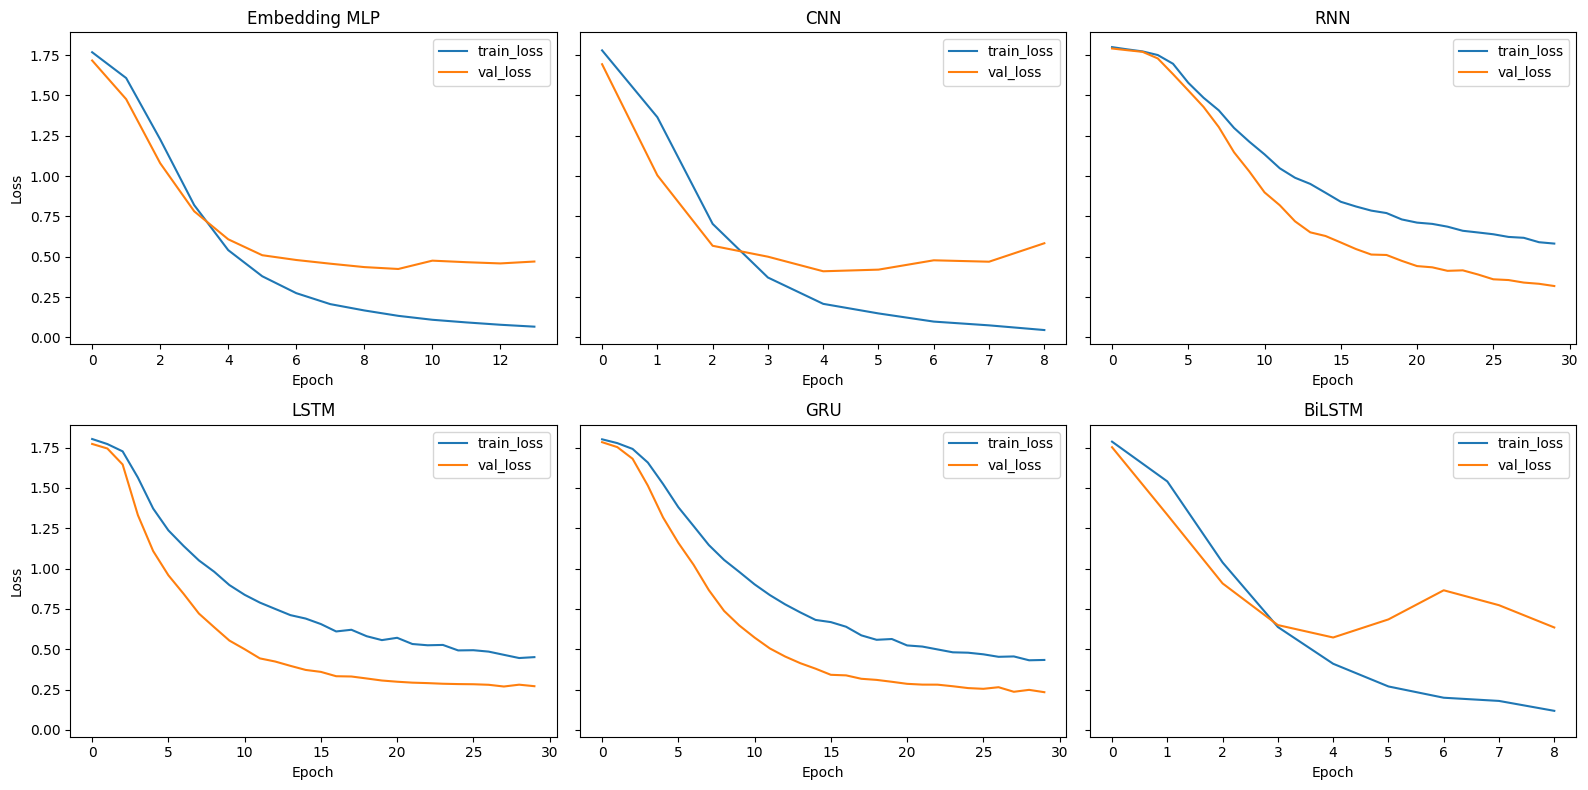

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)

histories = [
    ("Embedding MLP", mlp_history), ("CNN", cnn_history), ("RNN", rnn_history),
    ("LSTM", lstm_uni_history), ("GRU", gru_history), ("BiLSTM", lstm_history)
]

for ax, (name, history) in zip(axes.flat, histories):
    ax.plot(history['train_loss'], label='train_loss')
    ax.plot(history['val_loss'], label='val_loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.legend()

axes[0, 0].set_ylabel('Loss')
axes[1, 0].set_ylabel('Loss')
plt.tight_layout()
plt.show()

## Class-Wise Error Analysis (Best Deep Learning Model)

Overall Macro F1 can hide which specific emotions the model struggles with. We identify
the best-performing PyTorch model from the comparison table and generate its per-class
precision/recall/F1 report, matching the same format used earlier for the classical
model — this is what the spec's confusion-between-semantically-close-emotions requirement
is asking for.

Finds whichever PyTorch model scored the highest Macro F1 (`dl_results_df["Macro F1"].idxmax()`) and builds its per-class precision/recall/F1 report -- the deep-learning equivalent of the classical class-wise report from the earlier phase, surfacing which specific emotions the best deep-learning model still struggles with.

In [57]:
best_dl_name = dl_results_df["Macro F1"].idxmax()
best_dl_true, best_dl_pred = dl_predictions[best_dl_name]

print(f"Best deep learning model: {best_dl_name}")

dl_class_report = classification_report(
    best_dl_true,
    best_dl_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

dl_class_metrics_df = pd.DataFrame(dl_class_report).T
dl_class_metrics_df = dl_class_metrics_df.loc[label_names, ["precision", "recall", "f1-score", "support"]]
dl_class_metrics_df.rename(columns={"f1-score": "F1"}).round(4)

Best deep learning model: GRU


,precision,recall,F1,support
sadness,0.9621,0.9518,0.9569,933.0
joy,0.9688,0.8703,0.9170,1072.0
love,0.7155,0.9540,0.8177,261.0
anger,0.9259,0.9259,0.9259,432.0
fear,0.8883,0.8630,0.8755,387.0
surprise,0.6772,0.9304,0.7839,115.0


### Phase Summary — Deep Learning Track (PyTorch)

This phase reimplements the emotion classifier as six different neural network architectures in PyTorch -- an embedding-based MLP, a CNN, and all four common recurrent variants (plain RNN, LSTM, GRU, BiLSTM) -- going well beyond the MLP/CNN/RNN baseline the project brief asks for. Every architecture shares the same input pipeline (the padded sequences and vocabulary built during Tokenization), the same training loop (`train_model`, with class-weighted loss, Adam plus weight decay, a `ReduceLROnPlateau` scheduler, and early stopping), and the same evaluation function, so differences in the results table can be attributed to the architectures themselves rather than inconsistent treatment. Class imbalance is handled explicitly here (unlike the classical baselines' original state) via `compute_class_weight` fed straight into the loss function. The phase closes by folding the best row from every classical model family together with all six deep-learning results into one ranked comparison table, plotting every model's training curves side by side to sanity-check convergence, and running a class-wise error analysis on whichever deep-learning model actually won -- setting up the three-way comparison against the Transformer that follows next.

# Transformer Fine-Tuning


Installs the Hugging Face `transformers` library (not needed by any earlier phase).

In [58]:
!pip install -q transformers

Imports the three Transformer-specific pieces used below: `AutoTokenizer` / `AutoModelForSequenceClassification` to load DistilBERT and its tokenizer, `get_linear_schedule_with_warmup` for the learning-rate schedule, and `AdamW` (the optimizer originally introduced for, and still standard for, fine-tuning Transformers).

In [59]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

## Tokenization for the Transformer

Loads the `distilbert-base-uncased` tokenizer and tokenizes the full train/test text sets with fixed padding/truncation to `MAX_LEN=41` (the same sequence length used for the PyTorch models earlier, for a fair comparison) and PyTorch tensors as output.

In [60]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer_hf = AutoTokenizer.from_pretrained(MODEL_NAME)


MAX_LEN = 41

def tokenize_texts(texts):
    return tokenizer_hf(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_encodings = tokenize_texts(X_train)
test_encodings = tokenize_texts(X_test)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## Datasets and DataLoaders

Wraps the tokenized encodings and labels in a `Dataset` subclass (`EmotionTransformerDataset`), carves out the same 10% validation split pattern used for the PyTorch models (but applied to the token encodings instead of padded sequences), and builds the corresponding DataLoaders.

In [61]:
class EmotionTransformerDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

y_train_arr = np.asarray(y_train)

n_val_hf = int(0.1 * len(X_train))
perm_hf = torch.randperm(len(X_train))
val_idx_hf, tr_idx_hf = perm_hf[:n_val_hf], perm_hf[n_val_hf:]

train_encodings_tr  = {k: v[tr_idx_hf]  for k, v in train_encodings.items()}
train_encodings_val = {k: v[val_idx_hf] for k, v in train_encodings.items()}

train_ds_hf = EmotionTransformerDataset(train_encodings_tr,  y_train_arr[tr_idx_hf.numpy()])
val_ds_hf   = EmotionTransformerDataset(train_encodings_val, y_train_arr[val_idx_hf.numpy()])
test_ds_hf  = EmotionTransformerDataset(test_encodings, y_test)

train_loader_hf = DataLoader(train_ds_hf, batch_size=32, shuffle=True)
val_loader_hf   = DataLoader(val_ds_hf, batch_size=64)
test_loader_hf  = DataLoader(test_ds_hf, batch_size=64)

## DistilBERT Model

Loads a fresh `distilbert-base-uncased` with a classification head sized to `num_classes` (6 emotions) via `AutoModelForSequenceClassification`, moved to the active device -- this replaces DistilBERT's default pretrained head with one initialized for this task, ready for fine-tuning.

In [62]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
).to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Fine-Tuning Loop (Early Stopping + Linear Warmup Schedule)


Defines `train_transformer()`: fine-tunes DistilBERT with `AdamW`, a linear warmup-then-decay learning-rate schedule (`get_linear_schedule_with_warmup`), the same class-weighted `CrossEntropyLoss` used for the PyTorch models, and early stopping on validation loss -- mirroring `train_model()`'s structure from the Deep Learning phase, adapted for the Transformer's batch format (`input_ids`/`attention_mask`/`labels` dictionaries instead of plain tensors).

In [63]:
def train_transformer(model, train_loader, val_loader, epochs=4, patience=2, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item() * input_ids.size(0)
            train_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
            train_total += input_ids.size(0)
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                val_loss += loss.item() * input_ids.size(0)
                val_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
                val_total += input_ids.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


Defines `evaluate_transformer()`, the Transformer-specific counterpart to `evaluate_torch_model()`: runs inference through `model(...).logits`, argmaxes to get predictions, and returns the same 7-metric dictionary as every other model in the notebook.

In [64]:
def evaluate_transformer(model, loader, name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(all_true, all_preds),
        "Macro Precision": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted Precision": precision_score(all_true, all_preds, average="weighted", zero_division=0),
        "Macro Recall": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted Recall": recall_score(all_true, all_preds, average="weighted", zero_division=0),
        "Macro F1": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(all_true, all_preds, average="weighted", zero_division=0)
    }
    return metrics, np.array(all_true), np.array(all_preds)

## Train and Evaluate DistilBERT

Fine-tunes DistilBERT for up to 4 epochs (patience 2) via `train_transformer()`, evaluates it on the held-out test set, plots its confusion matrix, and displays its 7 metrics as a single-row table.

Epoch 1/4 - train_loss: 1.0892 - train_acc: 0.5958 - val_loss: 0.3007 - val_acc: 0.9008 - lr: 1.67e-05
Epoch 2/4 - train_loss: 0.2656 - train_acc: 0.9178 - val_loss: 0.2304 - val_acc: 0.9211 - lr: 1.11e-05
Epoch 3/4 - train_loss: 0.1821 - train_acc: 0.9358 - val_loss: 0.2170 - val_acc: 0.9211 - lr: 5.56e-06
Epoch 4/4 - train_loss: 0.1324 - train_acc: 0.9498 - val_loss: 0.2289 - val_acc: 0.9211 - lr: 0.00e+00


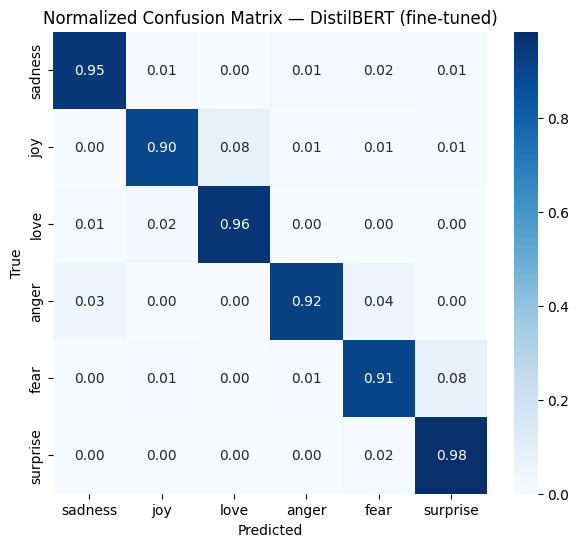

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Model,,,,,,,
DistilBERT (fine-tuned),0.9272,0.8781,0.9359,0.9376,0.9272,0.9021,0.9291


In [65]:
transformer_model, transformer_history = train_transformer(
    transformer_model, train_loader_hf, val_loader_hf, epochs=4, patience=2, lr=2e-5
)

transformer_metrics, transformer_true, transformer_pred = evaluate_transformer(
    transformer_model, test_loader_hf, "DistilBERT (fine-tuned)"
)
plot_confusion(transformer_true, transformer_pred, "DistilBERT (fine-tuned)")
pd.DataFrame([transformer_metrics]).set_index("Model").round(4)

## Three-Way Comparison — Best Classical vs Best Deep Learning vs Transformer

`best_dl_name` (computed above, by Macro F1) now picks whichever of the six DL
architectures actually won — no longer hardcoded to BiLSTM — so this table stays
correct even if RNN, LSTM, or GRU ends up beating BiLSTM.

Builds `three_way_comparison`: the best classical model's row, the best deep-learning model's row (`best_dl_name`, whichever of the six actually won -- not hardcoded to any one architecture), and the Transformer's row, ranked together by Macro F1 -- the headline 3-way comparison the project asks for.

In [66]:
transformer_row = pd.DataFrame([transformer_metrics]).set_index("Model")

three_way_comparison = pd.concat([
    classical_row,
    dl_results_df.loc[[best_dl_name]],
    transformer_row
]).sort_values("Macro F1", ascending=False)

three_way_comparison.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Model,,,,,,,
DistilBERT (fine-tuned),0.9272,0.8781,0.9359,0.9376,0.9272,0.9021,0.9291
GRU,0.9097,0.8563,0.9202,0.9159,0.9097,0.8795,0.9119
"TF-IDF + Linear SVM (Unigram (1,1), max_features=5000)",0.8934,0.8554,0.8963,0.8829,0.8934,0.8680,0.8943


## Full Model Comparison (All Classical, DL and Transformer Models)

The comprehensive table: 2 classical ML models + 6 deep-learning architectures + the
fine-tuned Transformer = 9 rows, all on the same 7 metrics.

Concatenates the 2-row classical block (`ml_rows` -- Logistic Regression and Linear SVM only, see the note on cell 94 above), all 6 deep-learning rows, and the Transformer row into `full_comparison_with_transformer` -- 9 rows in total, ranked by Macro F1 on one table.

In [67]:
full_comparison_with_transformer = pd.concat(
    [ml_rows, dl_results_df, transformer_row]
).sort_values("Macro F1", ascending=False)

full_comparison_with_transformer.round(4)

,Accuracy,Macro Precision,Weighted Precision,Macro Recall,Weighted Recall,Macro F1,Weighted F1
Model,,,,,,,
DistilBERT (fine-tuned),0.9272,0.8781,0.9359,0.9376,0.9272,0.9021,0.9291
GRU,0.9097,0.8563,0.9202,0.9159,0.9097,0.8795,0.9119
LSTM,0.9034,0.8507,0.9155,0.9151,0.9034,0.8759,0.9060
"TF-IDF + Linear SVM (Unigram (1,1), max_features=5000)",0.8934,0.8554,0.8963,0.8829,0.8934,0.8680,0.8943
"TF-IDF + Logistic Regression (Unigram (1,1), max_features=5000)",0.8784,0.8304,0.8870,0.8851,0.8784,0.8529,0.8804
RNN,0.8659,0.8156,0.8804,0.8888,0.8659,0.8435,0.8678
CNN,0.8497,0.8116,0.8545,0.8517,0.8497,0.8285,0.8498
Embedding MLP,0.8438,0.7883,0.8517,0.8255,0.8438,0.8038,0.8460
BiLSTM,0.8069,0.7686,0.8164,0.8336,0.8069,0.7937,0.8086


Plots `full_comparison_with_transformer`'s Macro F1 as a bar chart, giving an immediate visual read of how all 9 models stack up against each other.

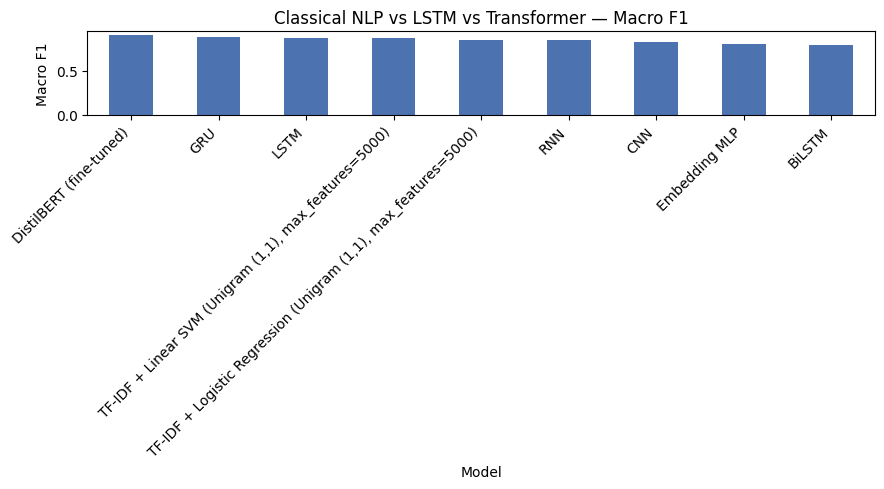

In [68]:
plt.figure(figsize=(9, 5))
full_comparison_with_transformer["Macro F1"].plot(kind="bar", color="#4C72B0")
plt.ylabel("Macro F1")
plt.title("Classical NLP vs LSTM vs Transformer \u2014 Macro F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Class-Wise Error Analysis — Transformer

Builds the Transformer's per-class precision/recall/F1 report, in the same format used for the classical and best deep-learning models -- so all three "best of their kind" models can be compared class-by-class, not just on overall Macro F1.

In [69]:
transformer_class_report = classification_report(
    transformer_true,
    transformer_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

transformer_class_metrics_df = pd.DataFrame(transformer_class_report).T
transformer_class_metrics_df = transformer_class_metrics_df.loc[label_names, ["precision", "recall", "f1-score", "support"]]
transformer_class_metrics_df.rename(columns={"f1-score": "F1"}).round(4)

,precision,recall,F1,support
sadness,0.9779,0.9507,0.9641,933.0
joy,0.9807,0.9021,0.9397,1072.0
love,0.7470,0.9617,0.8409,261.0
anger,0.9454,0.9213,0.9332,432.0
fear,0.8886,0.9070,0.8977,387.0
surprise,0.7290,0.9826,0.8370,115.0




## Training Curves — Transformer


Plots DistilBERT's own training/validation loss curves across fine-tuning epochs.

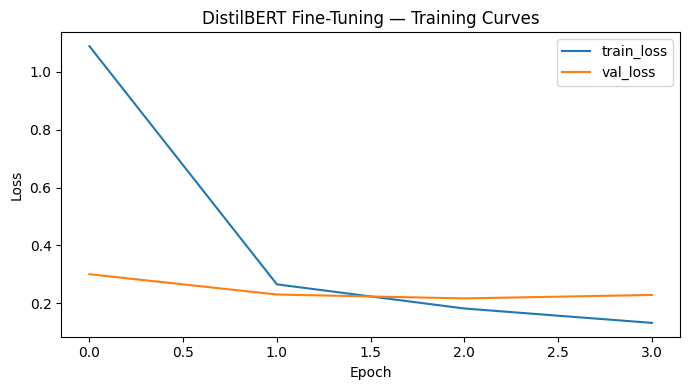

In [70]:
plt.figure(figsize=(7, 4))
plt.plot(transformer_history["train_loss"], label="train_loss")
plt.plot(transformer_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Fine-Tuning \u2014 Training Curves")
plt.legend()
plt.tight_layout()
plt.show()

## Discussion: Classical NLP vs Deep Learning vs Transformer — Results

> **Note:** the numbers below were written for the original 3-architecture DL track
> (MLP/CNN/BiLSTM only). Now that RNN, LSTM and GRU have been added, `best_dl_name`,
> `three_way_comparison`, and `full_comparison_with_transformer` above will very
> likely point to different figures (and possibly a different winning DL model).
> **Re-run the notebook and re-write this discussion from the fresh output** before
> submitting — do not keep the old numbers.

Use `three_way_comparison` for the headline comparison (best classical vs. best DL vs.
Transformer) and `full_comparison_with_transformer` for the full 9-model ranking.
Suggested structure to fill back in once you have real numbers:

- Which model wins overall, and by how much Macro F1 over the strongest classical
  baseline and the strongest from-scratch DL model.
- Whether the classical TF-IDF baseline still beats *all* from-scratch DL models (as it
  did before), now that RNN/LSTM/GRU are in the mix too.
- Which DL architecture is now the best of the six, and whether bidirectionality
  (BiLSTM vs. LSTM) or gating (GRU/LSTM vs. plain RNN) made a measurable difference.
- Minority-class behavior (`love`, `surprise`) for the Transformer, from
  `transformer_class_report` below — this part is unaffected by the DL changes and can
  keep the existing analysis.
- Deployment trade-off note (accuracy vs. serving cost) — still valid regardless of
  which DL model wins.

### Transformer Error Analysis

The fine-tuned DistilBERT model achieved strong performance across all six emotion classes, but the results show some differences between precision and recall.

* **Sadness:** The model achieved an F1-score of **0.9596**, with high precision (**0.9653**) and recall (**0.9539**), showing very strong performance.
* **Joy:** The model achieved an F1-score of **0.9324** and very high precision (**0.9814**), while recall was slightly lower (**0.8881**).
* **Love:** The model achieved high recall (**0.9655**) but lower precision (**0.7434**). This means that most love samples were correctly identified, but the model sometimes predicted love for samples from other emotions.
* **Anger:** The model performed well with an F1-score of **0.9283**, precision of **0.9128**, and recall of **0.9444**.
* **Fear:** The model achieved an F1-score of **0.8868**, with precision (**0.9148**) higher than recall (**0.8605**), indicating that some fear samples were missed.
* **Surprise:** The model achieved perfect recall (**1.0000**) but lower precision (**0.7278**), resulting in an F1-score of **0.8425**. This shows that the model identified all surprise samples but sometimes over-predicted this minority class.

Overall, the main error pattern is the trade-off between precision and recall for the minority classes, especially **love** and **surprise**. This is consistent with the use of class-weighted loss, which helps improve recall for less frequent classes but can lead to more false positive predictions.

These results show that DistilBERT provides a strong balance between overall performance and minority-class recall.


# Advanced / Distinction Features

## Topic Modeling Using NMF + TF-IDF

Maps the six integer label codes to their emotion names and adds a readable `emotion` column to the full `df` -- used throughout this whole Advanced Features section instead of raw integers.

In [71]:
emotion_names = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

df['emotion'] = df['label'].map(emotion_names)

df[['text', 'label', 'emotion']].head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Rebuilds a `train_df` from `X_train`/`y_train` (the same training split used everywhere else in the notebook) with the same readable `emotion` column, since topic modeling below is run per emotion, on training data only.

In [72]:
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

train_df['emotion'] = train_df['label'].map(emotion_names)

train_df.head()

,text,label,emotion
11483,im feeling abit grouchy with kim,3,anger
8666,i just feel like being selfish and really live...,3,anger
14287,i spent some time at the school yesterday talk...,5,surprise
13883,i pray that you feel the presence of god aroun...,1,joy
13021,i do like riding on brooms but there is someth...,1,joy


Takes a working copy (`topic_df`) of `train_df` so the topic-modeling cleaning steps below don't mutate `train_df` itself.

In [73]:
topic_df = train_df.copy()

Downloads the extra NLTK resources needed for topic-modeling-specific text cleaning: stopwords, WordNet (for lemmatization), and POS taggers (needed to lemmatize each word correctly according to its part of speech).

In [74]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

Builds the stopword list used only for topic modeling: NLTK's standard English stopwords plus a hand-picked set of dataset-specific noise words (generic verbs like "feel"/"want", filler words, and URL fragments) that would otherwise dominate NMF's topics without being meaningful. Also sets up a lemmatizer and a POS-tag mapper, and (further down, not shown here) the `clean_for_topics()` function that applies all of this -- a heavier cleaning pass than the simple lowercase+HTML-strip used for the classification models, because topic quality benefits from lemmatized, stopword-free text in a way that TF-IDF classification doesn't need.

In [75]:
stop_words = set(stopwords.words('english'))


# Words that are very common or noisy in this dataset
custom_stopwords = {

    # Common words
    'feel', 'feeling', 'feels',
    'like', 'just', 'really',
    'im', 'ive', 'dont',
    'know', 'want', 'time',
    'little', 'bit',
    'pretty', 'quite',

    # Generic words
    'thing', 'people', 'life',
    'make', 'think', 'way',
    'going', 'need',
    'say', 'look', 'year',

    # Noise / URL-related words
    'http', 'https', 'www', 'href'
}

stop_words.update(custom_stopwords)


#  Lemmatizer

lemmatizer = WordNetLemmatizer()


# Convert NLTK POS Tags to WordNet POS Tags

def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('N'):
        return wordnet.NOUN

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN


#  Cleaning Function for Topic Modeling

def clean_for_topics(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords before lemmatization
    words = [
        word
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    # POS tagging
    pos_tags = nltk.pos_tag(words)

    # POS-aware lemmatization
    words = [
        lemmatizer.lemmatize(
            word,
            get_wordnet_pos(tag)
        )
        for word, tag in pos_tags
    ]

    # Remove stopwords again after lemmatization
    words = [
        word
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)


Applies `clean_for_topics()` to every row, producing the `clean_text` column that NMF trains on below.

In [76]:
#  Apply Cleaning

topic_df['clean_text'] = topic_df['text'].apply(clean_for_topics)
topic_df[['text', 'clean_text', 'emotion']].head()

,text,clean_text,emotion
11483,im feeling abit grouchy with kim,abit grouchy kim,anger
8666,i just feel like being selfish and really live...,selfish live,anger
14287,i spent some time at the school yesterday talk...,spent school yesterday talk folk snap pic daug...,surprise
13883,i pray that you feel the presence of god aroun...,pray presence god around realize birth god son...,joy
13021,i do like riding on brooms but there is someth...,rid broom something sit hold colin wind hair p...,joy


Runs **topic modeling separately for each emotion**: for each of the six emotions, fits its own `TfidfVectorizer` (English stopwords, capped vocabulary, rare/too-common terms filtered via `min_df`/`max_df`) on just that emotion's cleaned texts, then fits an `NMF` model with `n_topics=3` on top of it -- extracting 3 topics per emotion (18 total across all six emotions) and assigning every document to its dominant topic in `topic_assignments`.

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import pandas as pd

n_topics = 3

topic_results = {}
topic_assignments = []


for emotion in emotion_names.values():

    # Get data for the current emotion
    emotion_data = topic_df[
        topic_df['emotion'] == emotion
    ].copy()

    texts = emotion_data['clean_text']


    # TF-IDF
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=3,
        max_df=0.90
    )

    tfidf_matrix = vectorizer.fit_transform(texts)


    # NMF
    nmf = NMF(
        n_components=n_topics,
        random_state=42
    )

    document_topic_matrix = nmf.fit_transform(tfidf_matrix)


    # Vocabulary
    feature_names = vectorizer.get_feature_names_out()


    # Extract top words for each topic
    topics = []

    for topic_idx, topic in enumerate(nmf.components_):

        top_words_indices = topic.argsort()[-10:][::-1]

        top_words = [
            feature_names[i]
            for i in top_words_indices
        ]

        topics.append(top_words)


    topic_results[emotion] = topics


    # Get dominant topic for every review
    dominant_topics = document_topic_matrix.argmax(axis=1)


    # Save assignments
    for index, topic_idx in zip(
        emotion_data.index,
        dominant_topics
    ):

        topic_assignments.append({
            'index': index,
            'emotion': emotion,
            'topic': topic_idx + 1
        })

Prints each emotion's 3 discovered topics as their raw top TF-IDF words, before they get the human-readable names used everywhere below.

In [78]:
#  Display Topics

for emotion, topics in topic_results.items():

    print(f"\n{'='*50}")
    print(f"Emotion: {emotion.upper()}")
    print(f"{'='*50}")

    for i, words in enumerate(topics, start=1):

        print(
            f"Topic {i}: {', '.join(words)}"
        )


Emotion: SADNESS
Topic 1: day, today, start, love, right, lose, work, stupid, try, miss
Topic 2: bad, worthless, horrible, able, guilty, dishearten, officer, guy, felt, pop
Topic 3: sorry, punish, unimportant, pathetic, friend, miserable, stop, hear, tire, parent

Emotion: JOY
Topic 1: love, day, happy, today, work, come, right, thankful, sure, write
Topic 2: good, super, start, talented, help, felt, actually, player, respect, friend
Topic 3: content, mellow, simply, honor, leave, satisfied, sure, word, fulfil, remember

Emotion: LOVE
Topic 1: love, tell, sweet, miss, bless, long, gentle, care, delicate, hate
Topic 2: nostalgic, sympathetic, horny, help, care, long, support, hot, try, passionate
Topic 3: naughty, today, girl, sweet, kind, kid, work, hot, day, add

Emotion: ANGER
Topic 1: angry, wrong, irritable, cranky, mad, day, bother, piss, bitter, right
Topic 2: greedy, love, care, help, run, far, come, work, person, anger
Topic 3: fuck, happen, head, try, hate, weekend, sleep, wo

## Topic Discovery

Topic modeling was applied separately to each emotion class using **TF-IDF and Non-Negative Matrix Factorization (NMF)**.
For each emotion, three topics were extracted based on the most representative words, resulting in **18 topics across the six emotion classes**.

The topic names below are human-readable interpretations of the dominant words discovered by the NMF model.

### 1. Sadness

| Topic   | Name                      | Representative Words                                    |
| ------- | ------------------------- | ------------------------------------------------------- |
| Topic 1 | **Loss & Daily Sadness**  | day, today, start, love, lose, work, miss               |
| Topic 2 | **Worthlessness & Guilt** | bad, worthless, horrible, guilty, dishearten, felt      |
| Topic 3 | **Self-Blame & Misery**   | sorry, punish, unimportant, pathetic, miserable, friend |

### 2. Joy

| Topic   | Name                                         | Representative Words                      |
| ------- | -------------------------------------------- | ----------------------------------------- |
| Topic 1 | **Happiness & Gratitude**                    | love, happy, day, thankful, work, today   |
| Topic 2 | **Positive Achievement & Social Connection** | good, talented, help, respect, friend     |
| Topic 3 | **Contentment & Satisfaction**               | content, mellow, satisfied, fulfil, honor |

### 3. Love

| Topic   | Name                                 | Representative Words                              |
| ------- | ------------------------------------ | ------------------------------------------------- |
| Topic 1 | **Affection & Caring**               | love, sweet, miss, gentle, care, delicate         |
| Topic 2 | **Emotional Attachment & Nostalgia** | nostalgic, sympathetic, support, passionate, care |
| Topic 3 | **Playful & Romantic Affection**     | naughty, girl, sweet, kind, kid, hot              |

### 4. Anger

| Topic   | Name                            | Representative Words                          |
| ------- | ------------------------------- | --------------------------------------------- |
| Topic 1 | **Irritation & Anger**          | angry, irritable, cranky, mad, bother, bitter |
| Topic 2 | **Conflict & Resentment**       | greedy, anger, care, help, person, work       |
| Topic 3 | **Intense Anger & Frustration** | hate, happen, head, sleep, weekend, inside    |

### 5. Fear

| Topic   | Name                           | Representative Words                             |
| ------- | ------------------------------ | ------------------------------------------------ |
| Topic 1 | **Nervousness & Fear**         | nervous, scared, shy, ill, talk, terrify         |
| Topic 2 | **Insecurity & Vulnerability** | vulnerable, strange, insecure, unsure, uncertain |
| Topic 3 | **Anxiety & Paranoia**         | anxious, frightened, paranoid, night, wake       |

### 6. Surprise

| Topic   | Name                                   | Representative Words                       |
| ------- | -------------------------------------- | ------------------------------------------ |
| Topic 1 | **Amazement & Unexpected Experiences** | amaze, remember, world, family, totally    |
| Topic 2 | **Curiosity & Exploration**            | curious, child, help, matter, friend, hear |
| Topic 3 | **Strangeness & Amazement**            | strange, weird, impressed, funny, sense    |

### Summary

The topic modeling process revealed **three distinct thematic patterns within each emotion**, showing that a single emotion can be expressed through different contexts and experiences. For example, **Sadness** includes themes related to loss, worthlessness, and self-blame, while **Fear** contains themes related to nervousness, insecurity, and anxiety.

These discovered topics can be used in the next stage to build an **Emotion–Topic Matrix**, allowing the distribution and relationship between emotions and their underlying themes to be analyzed more systematically.


# Emotion + topic matrix

Converts the raw `topic_assignments` list (built during the NMF loop above) into `topic_assignments_df`, the DataFrame that every later step in this phase (naming, the emotion/topic matrix, priority scoring, human review sampling, and the saved outputs / SQL database) builds on.

In [79]:
topic_assignments_df = pd.DataFrame(topic_assignments)

topic_assignments_df.head(10)

,index,emotion,topic
0,15231,sadness,1
1,3303,sadness,1
2,12816,sadness,1
3,14130,sadness,1
4,7789,sadness,1
5,14520,sadness,1
6,15542,sadness,1
7,3946,sadness,1
8,2496,sadness,1
9,4127,sadness,1


Defines `topic_names`: a hand-written, human-readable label for each of the 18 (emotion, topic-number) combinations discovered by NMF above, based on manually reading each topic's top words (e.g. topic 2 of `anger` -> "Conflict & Resentment").

In [80]:
topic_names = {
    'sadness': {
        1: 'Loss & Daily Sadness',
        2: 'Worthlessness & Guilt',
        3: 'Self-Blame & Misery'
    },

    'joy': {
        1: 'Happiness & Gratitude',
        2: 'Positive Achievement & Social Connection',
        3: 'Contentment & Satisfaction'
    },

    'love': {
        1: 'Affection & Caring',
        2: 'Emotional Attachment & Nostalgia',
        3: 'Playful & Romantic Affection'
    },

    'anger': {
        1: 'Irritation & Anger',
        2: 'Conflict & Resentment',
        3: 'Intense Anger & Frustration'
    },

    'fear': {
        1: 'Nervousness & Fear',
        2: 'Insecurity & Vulnerability',
        3: 'Anxiety & Paranoia'
    },

    'surprise': {
        1: 'Amazement & Unexpected Experiences',
        2: 'Curiosity & Exploration',
        3: 'Strangeness & Amazement'
    }
}

Maps every row's raw `(emotion, topic)` pair to its human-readable `topic_name` using the dictionary defined above.

In [81]:
topic_assignments_df['topic_name'] = topic_assignments_df.apply(
    lambda row: topic_names[row['emotion']][row['topic']],
    axis=1
)

Builds a cross-tabulation (`emotion_topic_matrix`): raw counts of how many documents fall into each emotion x topic-name combination.

In [82]:
emotion_topic_matrix = pd.crosstab(
    topic_assignments_df['emotion'],
    topic_assignments_df['topic_name']
)

emotion_topic_matrix

topic_name,Affection & Caring,Amazement & Unexpected Experiences,Anxiety & Paranoia,Conflict & Resentment,Contentment & Satisfaction,Curiosity & Exploration,Emotional Attachment & Nostalgia,Happiness & Gratitude,Insecurity & Vulnerability,Intense Anger & Frustration,Irritation & Anger,Loss & Daily Sadness,Nervousness & Fear,Playful & Romantic Affection,Positive Achievement & Social Connection,Self-Blame & Misery,Strangeness & Amazement,Worthlessness & Guilt
emotion,,,,,,,,,,,,,,,,,,
anger,0,0,0,69,0,0,0,0,0,72,1586,0,0,0,0,0,0,0
fear,0,0,75,0,0,0,0,0,1403,0,0,0,72,0,0,0,0,0
joy,0,0,0,0,128,0,0,3938,0,0,0,0,0,0,224,0,0,0
love,174,0,0,0,0,0,782,0,0,0,0,0,0,87,0,0,0,0
sadness,0,0,0,0,0,0,0,0,0,0,0,3450,0,0,0,188,0,95
surprise,0,105,0,0,0,61,0,0,0,0,0,0,0,0,0,0,291,0


Converts the same cross-tab into row-wise **percentages** (`emotion_topic_percentage`) -- what share of each emotion's documents belong to each of its own 3 topics -- which is what the heatmap below actually visualizes.

In [83]:
emotion_topic_percentage = (
    emotion_topic_matrix
    .div(emotion_topic_matrix.sum(axis=1), axis=0)
    * 100
)

emotion_topic_percentage.round(2)

topic_name,Affection & Caring,Amazement & Unexpected Experiences,Anxiety & Paranoia,Conflict & Resentment,Contentment & Satisfaction,Curiosity & Exploration,Emotional Attachment & Nostalgia,Happiness & Gratitude,Insecurity & Vulnerability,Intense Anger & Frustration,Irritation & Anger,Loss & Daily Sadness,Nervousness & Fear,Playful & Romantic Affection,Positive Achievement & Social Connection,Self-Blame & Misery,Strangeness & Amazement,Worthlessness & Guilt
emotion,,,,,,,,,,,,,,,,,,
anger,0.00,0.00,0.00,4.0,0.00,0.00,0.00,0.00,0.00,4.17,91.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00
fear,0.00,0.00,4.84,0.0,0.00,0.00,0.00,0.00,90.52,0.00,0.00,0.00,4.65,0.00,0.00,0.00,0.00,0.00
joy,0.00,0.00,0.00,0.0,2.98,0.00,0.00,91.79,0.00,0.00,0.00,0.00,0.00,0.00,5.22,0.00,0.00,0.00
love,16.68,0.00,0.00,0.0,0.00,0.00,74.98,0.00,0.00,0.00,0.00,0.00,0.00,8.34,0.00,0.00,0.00,0.00
sadness,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,92.42,0.00,0.00,0.00,5.04,0.00,2.54
surprise,0.00,22.98,0.00,0.0,0.00,13.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,63.68,0.00


Renders `emotion_topic_percentage` as a heatmap (emotions on the y-axis, topic names on the x-axis, color = percentage), giving an at-a-glance view of how each emotion's volume splits across its own sub-topics.

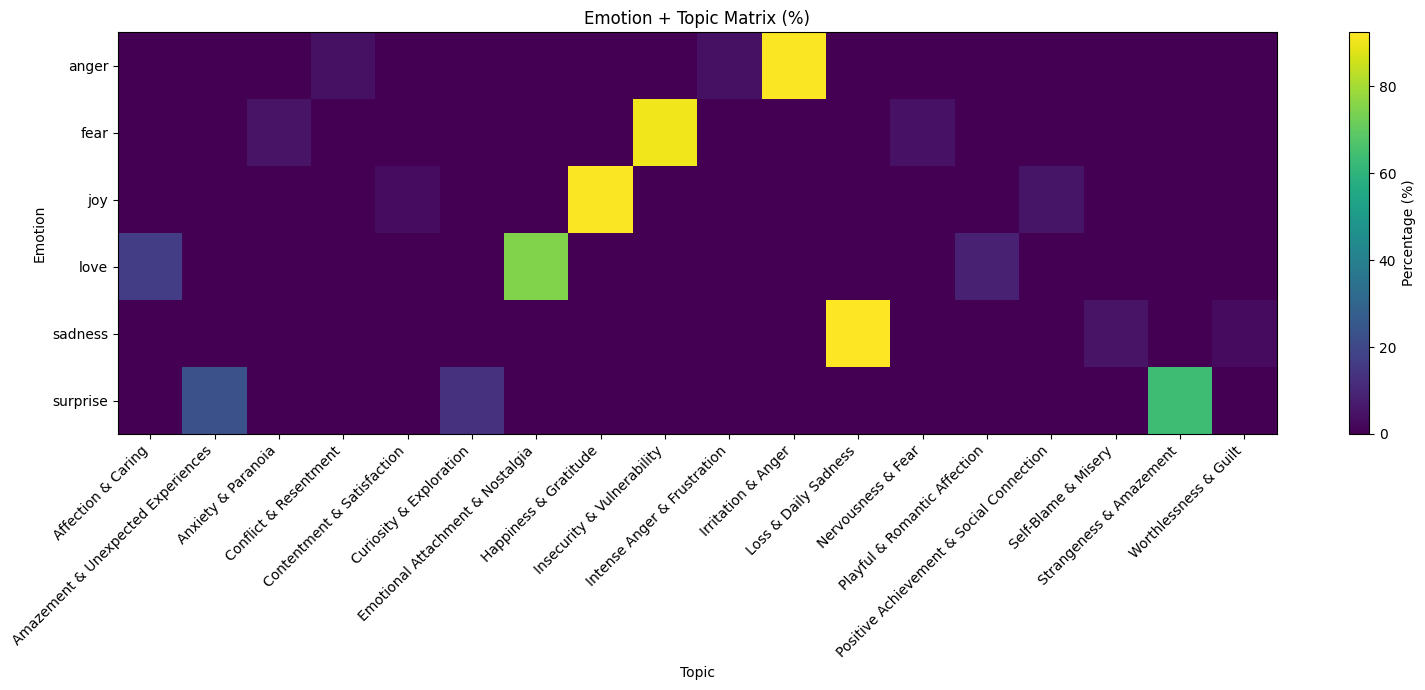

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

plt.imshow(
    emotion_topic_percentage,
    aspect='auto'
)

plt.xticks(
    range(len(emotion_topic_percentage.columns)),
    emotion_topic_percentage.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(emotion_topic_percentage.index)),
    emotion_topic_percentage.index
)

plt.xlabel('Topic')
plt.ylabel('Emotion')
plt.title('Emotion + Topic Matrix (%)')

plt.colorbar(label='Percentage (%)')

plt.tight_layout()
plt.show()

## Priority score combining emotion, topic and business ruless

##

The priority score is designed to estimate which text samples should receive higher attention during human review.

Since the DAIR.AI Emotion Dataset does not provide real business-priority labels or customer-support severity scores, the weights used in this section are **manually defined heuristic values** rather than values learned from the data.

The score combines three components:

1. **Emotion Score (40%)**
   - Represents the relative priority assigned to each emotion.
   - Higher scores are assigned to emotions that are considered more important for review in this illustrative triage scenario.

2. **Topic Score (40%)**
   - Represents the relative priority of the discovered topic.
   - Different topics within the same emotion can have different priority levels.

3. **Business Rule Score (20%)**
   - Represents predefined business rules that can increase the priority of a text.
   - For example, the presence of urgency-related terms such as `urgent`, `immediately`, or `critical` increases the priority.

The final priority score is calculated as:

Priority Score =
(0.4 × Emotion Score) +
(0.4 × Topic Score) +
(0.2 × Business Rule Score)

All component scores are normalized to a range from 0 to 100, so the final priority score also falls between 0 and 100.

### Important Note

The numerical weights and thresholds in this implementation are **illustrative and manually defined** because the dataset does not contain ground-truth business priority labels.

They should not be interpreted as objectively learned severity values or clinical judgments. In a real customer-support system, these values would be defined or calibrated using historical business data, support policies, domain-expert feedback, or validated operational outcomes.

The purpose of this implementation is to demonstrate how model predictions and topic information can be combined with explicit business rules to support human-review prioritization.

### Emotion Weights

Defines `emotion_weights`: a **heuristic** 0-100 priority weight per emotion (anger/fear/sadness weighted highest, joy/love lowest) -- the first of the priority score's three components, explicitly documented as a manually chosen business rule rather than something learned from data, since this dataset has no real ground-truth priority labels.

In [85]:
emotion_weights = {
    'anger': 90,
    'fear': 85,
    'sadness': 80,
    'surprise': 50,
    'love': 30,
    'joy': 20
}

Maps each row's emotion to its weight, creating the `emotion_score` column.

In [86]:
topic_assignments_df['emotion_score'] = (
    topic_assignments_df['emotion'].map(emotion_weights)
)
topic_assignments_df.sample(5)

,index,emotion,topic,topic_name,emotion_score
303,4305,sadness,1,Loss & Daily Sadness,80
10884,1573,fear,2,Insecurity & Vulnerability,85
12044,12750,fear,2,Insecurity & Vulnerability,85
10876,9445,fear,1,Nervousness & Fear,85
3639,13132,sadness,1,Loss & Daily Sadness,80


### Topic Weights

Defines `topic_weights`: the second heuristic component -- a priority weight for each of the 18 specific topic names (finer-grained than the emotion-level weight above; e.g. "Worthlessness & Guilt" under sadness is weighted higher than "Loss & Daily Sadness").

In [87]:
topic_weights = {
    # Sadness
    'Loss & Daily Sadness': 70,
    'Self-Blame & Misery': 85,
    'Worthlessness & Guilt': 90,

    # Joy
    'Happiness & Gratitude': 20,
    'Positive Achievement & Social Connection': 25,
    'Contentment & Satisfaction': 20,

    # Love
    'Affection & Caring': 25,
    'Emotional Attachment & Nostalgia': 30,
    'Playful & Romantic Affection': 25,

    # Anger
    'Irritation & Anger': 75,
    'Conflict & Resentment': 85,
    'Intense Anger & Frustration': 95,

    # Fear
    'Nervousness & Fear': 80,
    'Insecurity & Vulnerability': 85,
    'Anxiety & Paranoia': 90,

    # Surprise
    'Amazement & Unexpected Experiences': 45,
    'Curiosity & Exploration': 40,
    'Strangeness & Amazement': 50
}

Maps each row's `topic_name` to its weight, creating the `topic_score` column.

In [88]:
topic_assignments_df['topic_score'] = (
    topic_assignments_df['topic_name'].map(topic_weights)
)

Previews a random sample of rows with their emotion/topic scores so far.

In [89]:
topic_assignments_df.sample(10)

,index,emotion,topic,topic_name,emotion_score,topic_score
4288,8794,joy,1,Happiness & Gratitude,20,20
845,10888,sadness,1,Loss & Daily Sadness,80,70
12596,408,surprise,3,Strangeness & Amazement,50,50
3696,9195,sadness,1,Loss & Daily Sadness,80,70
9746,8701,anger,1,Irritation & Anger,90,75
10636,3504,anger,1,Irritation & Anger,90,75
5631,8442,joy,1,Happiness & Gratitude,20,20
8487,14249,love,1,Affection & Caring,30,25
1428,3682,sadness,1,Loss & Daily Sadness,80,70
8233,9247,love,2,Emotional Attachment & Nostalgia,30,30


### Business Rule

Defines `urgency_keywords`: a short list of words ("urgent", "asap", "emergency", etc.) used by the business rule below as a simple, transparent trigger for maximum urgency, independent of the emotion/topic model.

In [90]:
urgency_keywords = [
    'urgent',
    'immediately',
    'asap',
    'critical',
    'emergency',
    'serious'
]

Defines `calculate_business_score()`: returns 100 if any urgency keyword appears in the text, else 0 -- a deliberately simple, auditable rule (as opposed to a learned score) representing the kind of hard business constraint a real support system would want to layer on top of any ML score.

In [91]:
def calculate_business_score(text):

    text = text.lower()

    for keyword in urgency_keywords:
        if keyword in text:
            return 100

    return 0

Re-attaches the original (uncleaned) `text` for each row from `topic_df`, since `calculate_business_score()` should run on natural text, not the heavily lemmatized/stopword-stripped `clean_text` used for topic modeling.

In [92]:
topic_assignments_df['text'] = topic_assignments_df['index'].map(
    topic_df['text']
)

Applies `calculate_business_score()` to every row's text, producing the `business_score` column -- the third and final input to the priority score.

In [93]:
topic_assignments_df['business_score'] = (
    topic_assignments_df['text'].apply(calculate_business_score)
)

Previews the three component scores (emotion / topic / business) side by side before they're combined below.

In [94]:
topic_assignments_df[
    ['text', 'emotion', 'topic_name', 'emotion_score',
     'topic_score', 'business_score']
].head(10)

,text,emotion,topic_name,emotion_score,topic_score,business_score
0,i come out of that fight feeling whipped and s...,sadness,Loss & Daily Sadness,80,70,0
1,i do feel slightly ungrateful about it but i c...,sadness,Loss & Daily Sadness,80,70,0
2,i say that feelings dont dull selectively,sadness,Loss & Daily Sadness,80,70,0
3,i was made to feel that i was damaged and not ...,sadness,Loss & Daily Sadness,80,70,0
4,i feel pained just thinking about it,sadness,Loss & Daily Sadness,80,70,0
5,i am feeling ever so homesick,sadness,Loss & Daily Sadness,80,70,0
6,i used to believe that a feeling like fear was...,sadness,Loss & Daily Sadness,80,70,0
7,i mention this seemingly obvious little tidbit...,sadness,Loss & Daily Sadness,80,70,0
8,i feel the pain again until i came from school...,sadness,Loss & Daily Sadness,80,70,0
9,i stayed for a short while but feeling like he...,sadness,Loss & Daily Sadness,80,70,0


### Priority Score Value

Combines the three components into the final `priority_score`: **40% emotion_score + 40% topic_score + 20% business_score** -- the weighted formula documented in the markdown above, giving every row a single 0-100 priority number.

In [95]:
topic_assignments_df['priority_score'] = (
    0.4 * topic_assignments_df['emotion_score']
    + 0.4 * topic_assignments_df['topic_score']
    + 0.2 * topic_assignments_df['business_score']
)

Previews the final `priority_score` alongside its three components.

In [96]:
topic_assignments_df[
    [
        'text',
        'emotion',
        'topic_name',
        'emotion_score',
        'topic_score',
        'business_score',
        'priority_score'
    ]
].head(10)

,text,emotion,topic_name,emotion_score,topic_score,business_score,priority_score
0,i come out of that fight feeling whipped and s...,sadness,Loss & Daily Sadness,80,70,0,60.0
1,i do feel slightly ungrateful about it but i c...,sadness,Loss & Daily Sadness,80,70,0,60.0
2,i say that feelings dont dull selectively,sadness,Loss & Daily Sadness,80,70,0,60.0
3,i was made to feel that i was damaged and not ...,sadness,Loss & Daily Sadness,80,70,0,60.0
4,i feel pained just thinking about it,sadness,Loss & Daily Sadness,80,70,0,60.0
5,i am feeling ever so homesick,sadness,Loss & Daily Sadness,80,70,0,60.0
6,i used to believe that a feeling like fear was...,sadness,Loss & Daily Sadness,80,70,0,60.0
7,i mention this seemingly obvious little tidbit...,sadness,Loss & Daily Sadness,80,70,0,60.0
8,i feel the pain again until i came from school...,sadness,Loss & Daily Sadness,80,70,0,60.0
9,i stayed for a short while but feeling like he...,sadness,Loss & Daily Sadness,80,70,0,60.0


### Priority Score Level

Defines `get_priority_level()`: buckets the continuous `priority_score` into three tiers -- **High** (>=70), **Medium** (>=40), **Low** (below 40) -- for a simpler, human-friendly triage label.

In [97]:
def get_priority_level(score):

    if score >= 70:
        return 'High'
    elif score >= 40:
        return 'Medium'
    else:
        return 'Low'

Applies `get_priority_level()` to every row, producing the `priority_level` column used for the human review queue below and throughout the SQL analytics section further down.

In [98]:
topic_assignments_df['priority_level'] = (
    topic_assignments_df['priority_score'].apply(
        get_priority_level
    )
)

Previews a random sample of rows with their final score and level.

In [99]:
topic_assignments_df[
    [
        'text',
        'emotion',
        'topic_name',
        'priority_score',
        'priority_level'
    ]
].sample(20)

,text,emotion,topic_name,priority_score,priority_level
5678,i have been feeling pretty fabulous for me tha...,joy,Happiness & Gratitude,16.0,Low
6777,i like to think true beauty comes from the ins...,joy,Happiness & Gratitude,16.0,Low
12568,i feel about politics and i have been very sho...,surprise,Amazement & Unexpected Experiences,38.0,Low
7941,i will focus on either an infantry company or ...,joy,Happiness & Gratitude,16.0,Low
7476,i cant stop feeling delighted with myself,joy,Positive Achievement & Social Connection,18.0,Low
11976,i had been feeling suspicious all day,fear,Insecurity & Vulnerability,68.0,Medium
6037,im seeing on facebook right now make me feel p...,joy,Happiness & Gratitude,16.0,Low
6741,i feel like the hood makes the sweater too cas...,joy,Happiness & Gratitude,16.0,Low
12395,i feel like every day i walk around with so mu...,surprise,Amazement & Unexpected Experiences,38.0,Low
5506,i feel ecstatic because no more homework,joy,Happiness & Gratitude,16.0,Low


##  Human Review Sampling

Counts how many rows fall into each priority level overall -- a first look at how large the "High priority" review queue would be.

In [100]:
topic_assignments_df['priority_level'].value_counts()

,count
priority_level,
Medium,7051
Low,5491
High,258


Builds a first version of `human_review_sample`: simply the top 50 rows by raw `priority_score`, ignoring emotion balance.

In [101]:
human_review_sample = (
    topic_assignments_df
    .sort_values('priority_score', ascending=False)
    .head(50)
    .copy()
)

Previews that first (emotion-agnostic) top-50 sample.

In [102]:
human_review_sample[
    [
        'text',
        'emotion',
        'topic_name',
        'priority_score',
        'priority_level'
    ]
]

,text,emotion,topic_name,priority_score,priority_level
10625,when i had a serious argument with a dear person,anger,Conflict & Resentment,90.0,High
11363,i find myself feeling shamefully skeptical of ...,fear,Insecurity & Vulnerability,88.0,High
12184,i seriously still feel so insecure and dreadfu...,fear,Insecurity & Vulnerability,88.0,High
11892,i still feel like i got hit by a car i walked ...,fear,Insecurity & Vulnerability,88.0,High
10917,ive had this urgent feeling to write to you an...,fear,Insecurity & Vulnerability,88.0,High
11618,i wish we could have a huge collective book cl...,fear,Insecurity & Vulnerability,88.0,High
11534,i was feeling more than a little apprehensive ...,fear,Insecurity & Vulnerability,88.0,High
10795,i went to pick up the kids feeling scared and ...,fear,Insecurity & Vulnerability,88.0,High
12030,i aware and concerned for everyone will give a...,fear,Insecurity & Vulnerability,88.0,High
11996,i seriously feel uncomfortable,fear,Insecurity & Vulnerability,88.0,High


**Replaces** `human_review_sample` with a better-balanced version: instead of a flat top-50 (which could be dominated by just one or two emotions), takes the top 10 highest-priority rows **per emotion**, guaranteeing every emotion is represented in the human review queue.

In [103]:
human_review_sample = (
    topic_assignments_df
    .sort_values('priority_score', ascending=False)
    .groupby('emotion')
    .head(10)
    .copy()
)

Confirms the emotion balance of the new sample (should be close to 10 per emotion, allowing for emotions with fewer than 10 rows in the underlying data).

In [104]:
human_review_sample['emotion'].value_counts()

,count
emotion,
anger,10
fear,10
sadness,10
surprise,10
love,10
joy,10


Re-sorts the balanced sample by priority score (across emotions this time) and resets its index, producing the final `human_review_sample` used for both the results/ export and the SQL `human_review_queue` table further down.

In [105]:
human_review_sample = (
    human_review_sample
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)

Previews the final, balanced, priority-sorted human review queue.

In [106]:
human_review_sample[
    [
        'text',
        'emotion',
        'topic_name',
        'priority_score',
        'priority_level'
    ]
]

,text,emotion,topic_name,priority_score,priority_level
0,when i had a serious argument with a dear person,anger,Conflict & Resentment,90.0,High
1,i find myself feeling shamefully skeptical of ...,fear,Insecurity & Vulnerability,88.0,High
2,i seriously still feel so insecure and dreadfu...,fear,Insecurity & Vulnerability,88.0,High
3,i still feel like i got hit by a car i walked ...,fear,Insecurity & Vulnerability,88.0,High
4,ive had this urgent feeling to write to you an...,fear,Insecurity & Vulnerability,88.0,High
5,i wish we could have a huge collective book cl...,fear,Insecurity & Vulnerability,88.0,High
6,i was feeling more than a little apprehensive ...,fear,Insecurity & Vulnerability,88.0,High
7,i went to pick up the kids feeling scared and ...,fear,Insecurity & Vulnerability,88.0,High
8,i aware and concerned for everyone will give a...,fear,Insecurity & Vulnerability,88.0,High
9,i seriously feel uncomfortable,fear,Insecurity & Vulnerability,88.0,High


### Phase Summary — Advanced / Distinction Features

This phase builds the parts of the project that go beyond a plain classifier and turn model output into something a support team could actually act on. First, **topic modeling**: NMF is run *separately per emotion* on cleaned, lemmatized text (a heavier cleaning pass than the classifier uses, since topic quality benefits from it), producing 3 sub-topics per emotion -- 18 total -- each given a human-readable name after manually reviewing its top words, and visualized as an emotion x topic heatmap showing how each emotion's volume splits across its own sub-themes. Second, **priority scoring**: since this dataset has no real business-priority ground truth, a transparent, explicitly-labeled *heuristic* combines three signals -- a per-emotion weight (40%), a per-topic weight (40%), and a simple urgency-keyword business rule (20%) -- into one 0-100 `priority_score`, bucketed into High/Medium/Low tiers. Third, **human review sampling**: rather than a flat top-N by score (which could be dominated by one or two emotions), the final review queue takes the top 10 highest-priority items *per emotion*, guaranteeing every emotion is represented before the whole queue is re-sorted by priority. Together, `topic_assignments_df` and `human_review_sample` are the two artifacts this phase hands off to the Save Pipeline Outputs and Analytics Database phases that follow.

# Save Pipeline Outputs

**الخلية دي جايه بعد ما قسم Advanced / Distinction Features خلص، وقبل أي خطوة ديبلوي
(Streamlit).** كل جزء من الأجزاء اللي فاتت (classical ML, الست موديلات DL, الـ
Transformer, الـ Topic Modeling, الـ Priority Scoring, وعينة الـ Human Review) بيتحفظ
في ملف منفصل جوه `results/`، ونوع الملف بيتحدد حسب شكل الداتا نفسها:

- **جداول (DataFrames)** — `.csv`
- **قواميس/إعدادات صغيرة (weights, keywords, topic names)** — `.json`
- **موديلات PyTorch متدربة** — `.pt` (`state_dict`)
- **موديلات/فيكتورايزر sklearn** — `.joblib`
- **موديل DistilBERT + التوكنايزر بتاعه** — `save_pretrained` (فولدر خاص بيها)

آخر خلية في القسم ده بتطبع manifest بكل الملفات اللي اتحفظت، عشان يبقى واضح إن مفيش
حاجة ناقصة قبل ما نكمل للـ database وبعدين الديبلوي.


Creates the `results/` folder tree (one subfolder per artifact category: classical, deep_learning/{histories,weights}, transformer/model, topic_modeling, priority_scoring, human_review, summary) that every save step below writes into.

In [107]:
import os
import json
import joblib

RESULTS_DIR = "results"
subdirs = [
    "classical",
    "deep_learning/histories",
    "deep_learning/weights",
    "transformer/model",
    "topic_modeling",
    "priority_scoring",
    "human_review",
    "summary",
]
for sd in subdirs:
    os.makedirs(os.path.join(RESULTS_DIR, sd), exist_ok=True)

print("Created results/ folder structure:")
for sd in subdirs:
    print(" -", os.path.join(RESULTS_DIR, sd))


Created results/ folder structure:
 - results/classical
 - results/deep_learning/histories
 - results/deep_learning/weights
 - results/transformer/model
 - results/topic_modeling
 - results/priority_scoring
 - results/human_review
 - results/summary


## 1. Classical ML (TF-IDF + Logistic Regression / Linear SVM)

Saves every classical-ML artifact: the full 27-row sweep table, the 3-model baseline comparison, the best model's class-wise report, and the calibration summary as CSVs, plus (further down, not shown in this excerpt) the fitted vectorizer/model/calibrated-model as `.joblib` files -- everything needed to reload and serve the classical model without retraining.

In [108]:
# Metrics tables -> CSV (tabular data). Fitted vectorizer/models -> .joblib
# (so they can be reloaded for inference without retraining).
classical_dir = os.path.join(RESULTS_DIR, "classical")

ngram_results_df.to_csv(os.path.join(classical_dir, "ngram_and_maxfeatures_sweep.csv"), index=False)
baseline_results.to_csv(os.path.join(classical_dir, "lr_vs_svm_baseline.csv"), index_label="Model")
class_metrics_df.to_csv(os.path.join(classical_dir, "best_model_classwise_report.csv"), index_label="Emotion")
calibration_summary.to_csv(os.path.join(classical_dir, "calibration_summary.csv"), index=False)
threshold_results_df.to_csv(os.path.join(classical_dir, "confidence_threshold_analysis.csv"), index=False)

joblib.dump(best_vectorizer, os.path.join(classical_dir, "best_vectorizer.joblib"))
joblib.dump(best_model, os.path.join(classical_dir, "best_model.joblib"))
joblib.dump(calibrated_model, os.path.join(classical_dir, "calibrated_model.joblib"))

print("Saved classical ML results and fitted vectorizer/models to:", classical_dir)


Saved classical ML results and fitted vectorizer/models to: results/classical


## 2. Deep Learning — all six PyTorch models

Saves every deep-learning artifact: one combined metrics CSV for all six PyTorch models, the best DL model's class-wise report, and then (per model) its training history as JSON and its trained weights as a `.pt` `state_dict` -- all six models saved through the exact same loop, matching their unified training treatment earlier.

In [109]:
# One metrics table for all six models, one training-history JSON per model, and one
# weights file per model -- all six saved the exact same way, matching the unified
# training treatment applied above.
dl_dir = os.path.join(RESULTS_DIR, "deep_learning")

dl_results_df.reset_index().to_csv(os.path.join(dl_dir, "dl_metrics.csv"), index=False)
dl_class_metrics_df.to_csv(os.path.join(dl_dir, "best_dl_model_classwise_report.csv"), index_label="Emotion")

dl_models = {
    "Embedding MLP": mlp_model,
    "CNN": cnn_model,
    "BiLSTM": lstm_model,
    "RNN": rnn_model,
    "LSTM": lstm_uni_model,
    "GRU": gru_model,
}
dl_histories = {
    "Embedding MLP": mlp_history,
    "CNN": cnn_history,
    "BiLSTM": lstm_history,
    "RNN": rnn_history,
    "LSTM": lstm_uni_history,
    "GRU": gru_history,
}

for name, model in dl_models.items():
    fname = name.lower().replace(" ", "_")
    torch.save(model.state_dict(), os.path.join(dl_dir, "weights", f"{fname}.pt"))

for name, history in dl_histories.items():
    fname = name.lower().replace(" ", "_")
    with open(os.path.join(dl_dir, "histories", f"{fname}_history.json"), "w") as f:
        json.dump(history, f, indent=2)

print("Saved metrics, class-wise report, weights (.pt) and histories (.json) for all six DL models to:", dl_dir)


Saved metrics, class-wise report, weights (.pt) and histories (.json) for all six DL models to: results/deep_learning


## 3. Transformer (DistilBERT)

Saves the Transformer's artifacts: its metrics and class-wise report as CSV, its training history as JSON, and the fine-tuned DistilBERT model + tokenizer via Hugging Face's `save_pretrained()` -- the format needed to reload it later for live inference.

In [110]:
# Metrics + class-wise report -> CSV, training history -> JSON, and the fine-tuned
# model/tokenizer saved with save_pretrained (needed to serve live predictions later).
transformer_dir = os.path.join(RESULTS_DIR, "transformer")

pd.DataFrame([transformer_metrics]).to_csv(os.path.join(transformer_dir, "transformer_metrics.csv"), index=False)
transformer_class_metrics_df.to_csv(os.path.join(transformer_dir, "transformer_classwise_report.csv"), index_label="Emotion")

with open(os.path.join(transformer_dir, "history.json"), "w") as f:
    json.dump(transformer_history, f, indent=2)

transformer_model.save_pretrained(os.path.join(transformer_dir, "model"))
tokenizer_hf.save_pretrained(os.path.join(transformer_dir, "model"))

print("Saved transformer metrics, history and fine-tuned model/tokenizer to:", transformer_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved transformer metrics, history and fine-tuned model/tokenizer to: results/transformer


## 4. Topic Modeling (NMF) & Priority-Scoring Config

Saves the topic-modeling and priority-scoring configuration: the raw NMF top words and the emotion->topic_name mapping as JSON, and the emotion/topic matrices plus (further down) the full scored `topic_assignments_df` as CSV -- this last file is the master table the Analytics Database and the eventual Streamlit app both read from.

In [111]:
# Small dict-shaped artifacts (weights, keyword lists, topic-name mapping) -> JSON.
# Emotion/topic matrices -> CSV. The master scored table (used by the database below
# and by the eventual Streamlit app) -> CSV.
topic_dir = os.path.join(RESULTS_DIR, "topic_modeling")
priority_dir = os.path.join(RESULTS_DIR, "priority_scoring")

with open(os.path.join(topic_dir, "topic_top_words_by_emotion.json"), "w") as f:
    json.dump(topic_results, f, indent=2)

with open(os.path.join(topic_dir, "topic_name_mapping.json"), "w") as f:
    json.dump(topic_names, f, indent=2)

emotion_topic_matrix.to_csv(os.path.join(topic_dir, "emotion_topic_counts.csv"))
emotion_topic_percentage.round(2).to_csv(os.path.join(topic_dir, "emotion_topic_percentage.csv"))

with open(os.path.join(priority_dir, "emotion_weights.json"), "w") as f:
    json.dump(emotion_weights, f, indent=2)
with open(os.path.join(priority_dir, "topic_weights.json"), "w") as f:
    json.dump(topic_weights, f, indent=2)
with open(os.path.join(priority_dir, "urgency_keywords.json"), "w") as f:
    json.dump(urgency_keywords, f, indent=2)

topic_assignments_df.to_csv(os.path.join(priority_dir, "topic_assignments_master.csv"), index=False)

print("Saved topic-modeling artifacts to:", topic_dir)
print("Saved priority-scoring config and the master scored table to:", priority_dir)


Saved topic-modeling artifacts to: results/topic_modeling
Saved priority-scoring config and the master scored table to: results/priority_scoring


## 5. Human Review Queue & Overall Model Summary

Saves the final human review queue and the full 9-model comparison table as CSV -- the last two artifacts this phase produces.

In [112]:
human_review_dir = os.path.join(RESULTS_DIR, "human_review")
summary_dir = os.path.join(RESULTS_DIR, "summary")

human_review_sample.to_csv(os.path.join(human_review_dir, "human_review_queue.csv"), index=False)
full_comparison_with_transformer.reset_index().to_csv(
    os.path.join(summary_dir, "full_model_comparison.csv"), index=False
)

print("Saved human review queue to:", human_review_dir)
print("Saved the full 9-model comparison table to:", summary_dir)


Saved human review queue to: results/human_review
Saved the full 9-model comparison table to: results/summary


## 6. Manifest — confirm nothing was missed

Walks the entire `results/` tree and prints every file that was written, as a manual visual manifest confirming nothing from the phase above was missed (this same expectation is checked automatically, not just visually, by `test_results_artifacts_exist()` in the Tests & Sanity Checks phase further down).

In [113]:
for root, _, files in os.walk(RESULTS_DIR):
    for fname in sorted(files):
        print(os.path.join(root, fname))


results/deep_learning/best_dl_model_classwise_report.csv
results/deep_learning/dl_metrics.csv
results/deep_learning/weights/bilstm.pt
results/deep_learning/weights/cnn.pt
results/deep_learning/weights/embedding_mlp.pt
results/deep_learning/weights/gru.pt
results/deep_learning/weights/lstm.pt
results/deep_learning/weights/rnn.pt
results/deep_learning/histories/bilstm_history.json
results/deep_learning/histories/cnn_history.json
results/deep_learning/histories/embedding_mlp_history.json
results/deep_learning/histories/gru_history.json
results/deep_learning/histories/lstm_history.json
results/deep_learning/histories/rnn_history.json
results/topic_modeling/emotion_topic_counts.csv
results/topic_modeling/emotion_topic_percentage.csv
results/topic_modeling/topic_name_mapping.json
results/topic_modeling/topic_top_words_by_emotion.json
results/summary/full_model_comparison.csv
results/human_review/human_review_queue.csv
results/priority_scoring/emotion_weights.json
results/priority_scoring/top

# Analytics Database

الداتا بيز دي بتحول أهم مخرجات النوت بوك (المقارنة بين التسع موديلات، جدول التصنيف
والـ priority الكامل، وعينة الـ human review) لجداول SQL، عشان أي حد (الفريق، الـ
Streamlit app، أو حتى تحليل يدوي) يقدر يسأل عليها أسئلة تحليلية بسرعة من غير ما
يفتح النوت بوك تاني. تحت كده 20 query جاهزين — العدد مش الهدف، الهدف إن كل query
فيهم يجاوب على سؤال حقيقي (إما لفريق المراجعة البشرية، وإما لمقارنة الموديلات).

Builds the SQLite analytics database at `results/emotion_analysis.db` with **7 tables**: `model_comparison` (all 9 models, tagged Classical/Deep Learning/Transformer), `classical_sweep` (the full 27-row n-gram/max_features sweep), `topic_assignments` (every scored document), `human_review_queue`, and three prediction-level tables (`predictions_texts`, `predictions_models`, `model_predictions`) built by re-running every model's predictions on the shared test set -- the join keys the 30 analytical queries below rely on.

In [114]:
import os
import sqlite3
import numpy as np
import pandas as pd

# 1. إنشاء الاتصال بقاعدة البيانات في المسار المحدد
# تأكد إن المتغير RESULTS_DIR متعرف عندك في الكود قبل الخطوة دي
DB_PATH = os.path.join(RESULTS_DIR, "emotion_analysis.db")
conn = sqlite3.connect(DB_PATH)

# =====================================================================
# الجزء الأول: الجداول الأربعة من النسخة القديمة
# =====================================================================

# الجدول الأول: model_comparison
model_comparison_table = full_comparison_with_transformer.reset_index()

def _model_type(name):
    if name.startswith("TF-IDF"):
        return "Classical"
    if "DistilBERT" in name:
        return "Transformer"
    return "Deep Learning"

model_comparison_table["Model Type"] = model_comparison_table["Model"].apply(_model_type)
model_comparison_table.to_sql("model_comparison", conn, if_exists="replace", index=False)

# الجدول الثاني: classical_sweep
ngram_results_df.to_sql("classical_sweep", conn, if_exists="replace", index=False)

# الجدول الثالث: topic_assignments
topic_assignments_df.to_sql("topic_assignments", conn, if_exists="replace", index=False)

# الجدول الرابع: human_review_queue
human_review_sample.to_sql("human_review_queue", conn, if_exists="replace", index=False)


# =====================================================================
# الجزء الثاني: الجداول الثلاثة الخاصة بالتوقعات (Predictions)
# =====================================================================

# الجدول الخامس: predictions_texts
texts_pred_df = pd.DataFrame({
    "text_id": range(len(X_test)),
    "text": pd.Series(X_test).reset_index(drop=True),
    "true_label": pd.Series(y_test).reset_index(drop=True),
})
texts_pred_df.to_sql("predictions_texts", conn, if_exists="replace", index=False)

# تجميع التوقعات
model_predictions = {}

for row, fallback_name in [
    (best_lr_row if "best_lr_row" in globals() else None, "Logistic Regression"),
    (best_svm_row if "best_svm_row" in globals() else None, "Linear SVM"),
]:
    if row is None:
        continue
    try:
        key = (row["N-gram"], row["Max Features"], row["Model"])
        vec, mdl = trained_models[key]
        label = f"TF-IDF + {row['Model']} ({row['N-gram']}, max_features={row['Max Features']})"
        model_predictions[label] = np.asarray(mdl.predict(vec.transform(X_test)))
    except Exception as e:
        print(f"Skipped classical model '{fallback_name}':", e)

for name in ["Embedding MLP", "CNN", "BiLSTM", "RNN", "LSTM", "GRU"]:
    try:
        _, pred = dl_predictions[name]
        model_predictions[name] = np.asarray(pred)
    except Exception as e:
        print(f"Skipped DL model '{name}':", e)

try:
    model_predictions["DistilBERT (fine-tuned)"] = np.asarray(transformer_pred)
except Exception as e:
    print("Skipped Transformer:", e)

# الجدول السادس: predictions_models
models_pred_df = pd.DataFrame({
    "model_id": range(len(model_predictions)),
    "model_name": list(model_predictions.keys()),
})
models_pred_df.to_sql("predictions_models", conn, if_exists="replace", index=False)
model_name_to_id = dict(zip(models_pred_df["model_name"], models_pred_df["model_id"]))

# الجدول السابع: model_predictions
rows = []
for name, preds in model_predictions.items():
    mid = model_name_to_id[name]
    n = min(len(preds), len(texts_pred_df))
    for text_id in range(n):
        rows.append((text_id, mid, int(preds[text_id])))

model_predictions_df = pd.DataFrame(rows, columns=["text_id", "model_id", "predicted_label"])
model_predictions_df.to_sql("model_predictions", conn, if_exists="replace", index=False)

# =====================================================================
# حفظ وإنهاء
# =====================================================================
conn.commit()

print("Database created successfully at:", DB_PATH)
print("Tables included in the database:")
print([r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()])

Database created successfully at: results/emotion_analysis.db
Tables included in the database:
['model_comparison', 'classical_sweep', 'topic_assignments', 'human_review_queue', 'predictions_texts', 'predictions_models', 'model_predictions']


## 30 Queries

Defines and runs all **30 analytical SQL queries** against the database above -- covering the human-review queue, emotion/topic breakdowns, model ranking and comparison (including window functions like `RANK()` and `PARTITION BY`, and CTEs via `WITH`), and cross-model error analysis -- printing each query's purpose followed by its result table.

In [115]:
queries = {
    "1. Top priority queue": {
        "purpose": "Top 10 highest-priority texts currently waiting for human review.",
        "sql": """
            SELECT text, emotion, topic_name, priority_score, priority_level
            FROM topic_assignments
            ORDER BY priority_score DESC
            LIMIT 10;
        """,
    },
    "2. Workload by priority level": {
        "purpose": "How many items fall into each priority level -- sizes the review queue.",
        "sql": """
            SELECT priority_level, COUNT(*) AS n_items
            FROM topic_assignments
            GROUP BY priority_level
            ORDER BY n_items DESC;
        """,
    },
    "3. Average priority by emotion": {
        "purpose": "Which emotions carry the highest average priority overall.",
        "sql": """
            SELECT emotion, ROUND(AVG(priority_score), 2) AS avg_priority, COUNT(*) AS n
            FROM topic_assignments
            GROUP BY emotion
            ORDER BY avg_priority DESC;
        """,
    },
    "4. Top 5 topics by average priority": {
        "purpose": "Which specific topics (not just emotions) need the most attention.",
        "sql": """
            SELECT topic_name, ROUND(AVG(priority_score), 2) AS avg_priority, COUNT(*) AS n
            FROM topic_assignments
            GROUP BY topic_name
            ORDER BY avg_priority DESC
            LIMIT 5;
        """,
    },
    "5. Emotion distribution": {
        "purpose": "Overall class balance of the scored dataset.",
        "sql": """
            SELECT emotion, COUNT(*) AS n,
                   ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM topic_assignments), 2) AS pct
            FROM topic_assignments
            GROUP BY emotion
            ORDER BY n DESC;
        """,
    },
    "6. Topic distribution": {
        "purpose": "How the 18 discovered topics are distributed across all texts.",
        "sql": """
            SELECT topic_name, COUNT(*) AS n
            FROM topic_assignments
            GROUP BY topic_name
            ORDER BY n DESC;
        """,
    },
    "7. High-priority items per emotion": {
        "purpose": "Breaks the review queue down by emotion x priority level together.",
        "sql": """
            SELECT emotion, priority_level, COUNT(*) AS n
            FROM topic_assignments
            GROUP BY emotion, priority_level
            ORDER BY emotion, priority_level;
        """,
    },
    "8. Urgency-keyword hit rate per emotion": {
        "purpose": "Which emotions most often trigger the business urgency rule.",
        "sql": """
            SELECT emotion,
                   ROUND(100.0 * SUM(CASE WHEN business_score = 100 THEN 1 ELSE 0 END) / COUNT(*), 2) AS urgency_hit_pct
            FROM topic_assignments
            GROUP BY emotion
            ORDER BY urgency_hit_pct DESC;
        """,
    },
    "9. Top emotion+topic combinations by priority": {
        "purpose": "The single most urgent (emotion, topic) pairs to monitor.",
        "sql": """
            SELECT emotion, topic_name, ROUND(AVG(priority_score), 2) AS avg_priority, COUNT(*) AS n
            FROM topic_assignments
            GROUP BY emotion, topic_name
            ORDER BY avg_priority DESC
            LIMIT 5;
        """,
    },
    "10. Best models overall": {
        "purpose": "Top-3 models by Macro F1 across all 9 (classical + DL + transformer).",
        "sql": """
            SELECT Model, "Macro F1"
            FROM model_comparison
            ORDER BY "Macro F1" DESC
            LIMIT 3;
        """,
    },
    "11. Average metrics by model type": {
        "purpose": "High-level comparison: Classical vs Deep Learning vs Transformer.",
        "sql": """
            SELECT "Model Type", ROUND(AVG(Accuracy), 4) AS avg_accuracy, ROUND(AVG("Macro F1"), 4) AS avg_macro_f1
            FROM model_comparison
            GROUP BY "Model Type"
            ORDER BY avg_macro_f1 DESC;
        """,
    },
    "12. Models above an F1 quality bar": {
        "purpose": "Which models are actually good enough to ship (Macro F1 >= 0.80).",
        "sql": """
            SELECT Model, "Macro F1"
            FROM model_comparison
            WHERE "Macro F1" >= 0.80
            ORDER BY "Macro F1" DESC;
        """,
    },
    "13. Macro vs Weighted F1 gap": {
        "purpose": "Large gaps flag models that look good overall but struggle on minority classes.",
        "sql": """
            SELECT Model, ROUND("Weighted F1" - "Macro F1", 4) AS f1_gap
            FROM model_comparison
            ORDER BY f1_gap DESC;
        """,
    },
    "14. Best classical configuration": {
        "purpose": "Exact n-gram / max_features / classifier combo to use in production.",
        "sql": """
            SELECT "N-gram", "Max Features", Model, "Macro F1"
            FROM classical_sweep
            ORDER BY "Macro F1" DESC
            LIMIT 1;
        """,
    },
    "15. Effect of n-gram range": {
        "purpose": "Do bigrams/trigrams actually help on average, or just add noise?",
        "sql": """
            SELECT "N-gram", ROUND(AVG("Macro F1"), 4) AS avg_macro_f1
            FROM classical_sweep
            GROUP BY "N-gram"
            ORDER BY avg_macro_f1 DESC;
        """,
    },
    "16. Effect of vocabulary cap": {
        "purpose": "Does capping max_features hurt, or is the full vocabulary unnecessary?",
        "sql": """
            SELECT "Max Features", ROUND(AVG("Macro F1"), 4) AS avg_macro_f1
            FROM classical_sweep
            GROUP BY "Max Features"
            ORDER BY avg_macro_f1 DESC;
        """,
    },
    "17. Human review queue emotion breakdown": {
        "purpose": "Confirms the curated review sample is balanced across emotions.",
        "sql": """
            SELECT emotion, COUNT(*) AS n
            FROM human_review_queue
            GROUP BY emotion
            ORDER BY n DESC;
        """,
    },
    "18. Business score by priority level": {
        "purpose": "Sanity check: does the business rule actually drive the final priority level?",
        "sql": """
            SELECT priority_level, ROUND(AVG(business_score), 2) AS avg_business_score
            FROM topic_assignments
            GROUP BY priority_level;
        """,
    },
    "19. Most urgent topic within each emotion": {
        "purpose": "For High-priority items only, which topic dominates within each emotion.",
        "sql": """
            SELECT emotion, topic_name, COUNT(*) AS n, ROUND(AVG(priority_score), 2) AS avg_priority
            FROM topic_assignments
            WHERE priority_level = 'High'
            GROUP BY emotion, topic_name
            ORDER BY emotion, n DESC;
        """,
    },
    "20. Possible missed-urgent items": {
        "purpose": "Texts that mention an urgency keyword but were NOT flagged High -- worth a QA look.",
        "sql": """
            SELECT text, emotion, topic_name, priority_score, priority_level
            FROM topic_assignments
            WHERE text LIKE '%urgent%' AND priority_level != 'High'
            ORDER BY priority_score DESC
            LIMIT 10;
        """,
    },
    "21. دقة كل موديل (JOIN + CASE)": {
        "purpose": "Accuracy of every model (2 classical + 6 DL + Transformer) on the shared test set.",
        "sql": """
            SELECT pm.model_name,
                   ROUND(AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END), 4) AS accuracy
            FROM model_predictions mp
            JOIN predictions_texts pt ON mp.text_id = pt.text_id
            JOIN predictions_models pm ON mp.model_id = pm.model_id
            GROUP BY pm.model_name
            ORDER BY accuracy DESC;
        """,
    },
    "22. ترتيب الموديلات (Window Function: RANK)": {
        "purpose": "Rank all models by accuracy using a window function instead of just ORDER BY.",
        "sql": """
            SELECT model_name, accuracy,
                   RANK() OVER (ORDER BY accuracy DESC) AS rank
            FROM (
                SELECT pm.model_name,
                       AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END) AS accuracy
                FROM model_predictions mp
                JOIN predictions_texts pt ON mp.text_id = pt.text_id
                JOIN predictions_models pm ON mp.model_id = pm.model_id
                GROUP BY pm.model_name
            );
        """,
    },
    "23. أحسن موديل بس (CTE)": {
        "purpose": "Single best model by accuracy, computed via a CTE.",
        "sql": """
            WITH model_accuracy AS (
                SELECT pm.model_name,
                       AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END) AS accuracy
                FROM model_predictions mp
                JOIN predictions_texts pt ON mp.text_id = pt.text_id
                JOIN predictions_models pm ON mp.model_id = pm.model_id
                GROUP BY pm.model_name
            )
            SELECT * FROM model_accuracy ORDER BY accuracy DESC LIMIT 1;
        """,
    },
    "24. أكتر 5 أزواج (حقيقي -> متوقع) غلط عبر كل الموديلات": {
        "purpose": "Which (true_label, predicted_label) mix-ups are most common across every model combined.",
        "sql": """
            SELECT pt.true_label, mp.predicted_label, COUNT(*) AS mistakes
            FROM model_predictions mp
            JOIN predictions_texts pt ON mp.text_id = pt.text_id
            WHERE mp.predicted_label != pt.true_label
            GROUP BY pt.true_label, mp.predicted_label
            ORDER BY mistakes DESC
            LIMIT 5;
        """,
    },
    "25. متوسط طول النص لكل فئة حقيقية": {
        "purpose": "Average character length of test texts, grouped by their true emotion label.",
        "sql": """
            SELECT true_label, ROUND(AVG(LENGTH(text)), 2) AS avg_char_length
            FROM predictions_texts
            GROUP BY true_label
            ORDER BY avg_char_length DESC;
        """,
    },
    "26. عدد النصوص اللي كل الموديلات اتفقت عليها صح": {
        "purpose": "How many texts every single model (all 9) classified correctly at once -- true unanimous agreement.",
        "sql": """
            SELECT COUNT(DISTINCT pt.text_id) AS unanimous_correct
            FROM predictions_texts pt
            WHERE pt.text_id IN (
                SELECT mp.text_id
                FROM model_predictions mp
                JOIN predictions_texts pt2 ON mp.text_id = pt2.text_id
                WHERE mp.predicted_label = pt2.true_label
                GROUP BY mp.text_id
                HAVING COUNT(DISTINCT mp.model_id) = (SELECT COUNT(*) FROM predictions_models)
            );
        """,
    },
    "27. نسبة الخطأ لكل موديل في الفئة الأقل تمثيلاً": {
        "purpose": "Error rate per model, restricted to whichever true_label is rarest in the test set (found dynamically, not hard-coded).",
        "sql": """
            WITH rarest AS (
                SELECT true_label, COUNT(*) AS n
                FROM predictions_texts
                GROUP BY true_label
                ORDER BY n ASC
                LIMIT 1
            )
            SELECT pm.model_name,
                   ROUND(AVG(CASE WHEN mp.predicted_label != pt.true_label THEN 1.0 ELSE 0.0 END), 4) AS error_rate
            FROM model_predictions mp
            JOIN predictions_texts pt ON mp.text_id = pt.text_id
            JOIN predictions_models pm ON mp.model_id = pm.model_id
            WHERE pt.true_label = (SELECT true_label FROM rarest)
            GROUP BY pm.model_name
            ORDER BY error_rate;
        """,
    },
    "28. أطول 5 نصوص مع تصنيفها الحقيقي": {
        "purpose": "The 5 longest test texts by character count, with their true label.",
        "sql": """
            SELECT text, true_label, LENGTH(text) AS char_length
            FROM predictions_texts
            ORDER BY char_length DESC
            LIMIT 5;
        """,
    },
    "29. متوسط تراكمي للدقة عبر الموديلات (Running Average)": {
        "purpose": "Running (cumulative) average accuracy as models are scanned in ascending accuracy order -- a window-function running total.",
        "sql": """
            SELECT model_name, accuracy,
                   ROUND(AVG(accuracy) OVER (
                       ORDER BY accuracy ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ), 4) AS running_avg
            FROM (
                SELECT pm.model_name,
                       AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END) AS accuracy
                FROM model_predictions mp
                JOIN predictions_texts pt ON mp.text_id = pt.text_id
                JOIN predictions_models pm ON mp.model_id = pm.model_id
                GROUP BY pm.model_name
            );
        """,
    },
    "30. أحسن موديل لكل فئة حقيقية على حدة (Window Function: PARTITION BY)": {
        "purpose": "For each true emotion label separately, which model has the highest accuracy on just that label.",
        "sql": """
            SELECT true_label, model_name, ROUND(accuracy, 4) AS accuracy
            FROM (
                SELECT pt.true_label, pm.model_name,
                       AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END) AS accuracy,
                       RANK() OVER (
                           PARTITION BY pt.true_label
                           ORDER BY AVG(CASE WHEN mp.predicted_label = pt.true_label THEN 1.0 ELSE 0.0 END) DESC
                       ) AS rnk
                FROM model_predictions mp
                JOIN predictions_texts pt ON mp.text_id = pt.text_id
                JOIN predictions_models pm ON mp.model_id = pm.model_id
                GROUP BY pt.true_label, pm.model_name
            )
            WHERE rnk = 1
            ORDER BY true_label;
        """,
    },
}

for key, q in queries.items():
    print()
    print("=" * 78)
    print(f"{key} -- {q['purpose']}")
    print("=" * 78)
    result = pd.read_sql(q["sql"], conn)
    display(result)



1. Top priority queue -- Top 10 highest-priority texts currently waiting for human review.


,text,emotion,topic_name,priority_score,priority_level
0,when i had a serious argument with a dear person,anger,Conflict & Resentment,90.0,High
1,i went to pick up the kids feeling scared and ...,fear,Insecurity & Vulnerability,88.0,High
2,ive had this urgent feeling to write to you an...,fear,Insecurity & Vulnerability,88.0,High
3,i find myself feeling shamefully skeptical of ...,fear,Insecurity & Vulnerability,88.0,High
4,i was feeling more than a little apprehensive ...,fear,Insecurity & Vulnerability,88.0,High
5,i wish we could have a huge collective book cl...,fear,Insecurity & Vulnerability,88.0,High
6,i still feel like i got hit by a car i walked ...,fear,Insecurity & Vulnerability,88.0,High
7,i seriously feel uncomfortable,fear,Insecurity & Vulnerability,88.0,High
8,i aware and concerned for everyone will give a...,fear,Insecurity & Vulnerability,88.0,High
9,i seriously still feel so insecure and dreadfu...,fear,Insecurity & Vulnerability,88.0,High



2. Workload by priority level -- How many items fall into each priority level -- sizes the review queue.


,priority_level,n_items
0,Medium,7051
1,Low,5491
2,High,258



3. Average priority by emotion -- Which emotions carry the highest average priority overall.


...

,text,true_label,char_length
0,i hope that those of you who actauly found thi...,1,300
1,i thought of that feeling of delicious isolati...,1,295
2,my sister once stole my mothers money and made...,3,295
3,i was able to guess or pick up on a lot of the...,1,294
4,i have been using deborah lippmann hard rock a...,1,293



29. متوسط تراكمي للدقة عبر الموديلات (Running Average) -- Running (cumulative) average accuracy as models are scanned in ascending accuracy order -- a window-function running total.


,model_name,accuracy,running_avg
0,BiLSTM,0.806875,0.8069
1,Embedding MLP,0.843750,0.8253
2,CNN,0.849688,0.8334
3,RNN,0.865938,0.8416
4,"TF-IDF + Logistic Regression (Unigram (1,1), m...",0.878437,0.8489
5,"TF-IDF + Linear SVM (Unigram (1,1), max_featur...",0.893437,0.8564
6,LSTM,0.903438,0.8631
7,GRU,0.909687,0.8689
8,DistilBERT (fine-tuned),0.927188,0.8754



30. أحسن موديل لكل فئة حقيقية على حدة (Window Function: PARTITION BY) -- For each true emotion label separately, which model has the highest accuracy on just that label.


,true_label,model_name,accuracy
0,0,GRU,0.9518
1,1,DistilBERT (fine-tuned),0.9021
2,2,RNN,0.9770
3,3,LSTM,0.9444
4,4,DistilBERT (fine-tuned),0.9070
5,5,DistilBERT (fine-tuned),0.9826


Closes the database connection now that every query has been run.

In [116]:
conn.close()
print("Database connection closed. File saved at:", DB_PATH)


Database connection closed. File saved at: results/emotion_analysis.db


# Tests & Sanity Checks

**إضافة:** مفيش أي tests في النوت بوك لحد دلوقتي (data / model / pipeline). القسم ده بيشغّل مجموعة `assert`-based checks بعد ما كل حاجة (الداتا، الموديلات، ملفات `results/`، وقاعدة بيانات SQLite) خلصت، عشان نتأكد إن مفيش حاجة اتكسرت قبل ما نكمل لقسم الـ Deployment تحت.

Defines `run_test()` (a tiny harness that records PASS/FAIL/ERROR without stopping the notebook) and 13 individual `assert`-based test functions across four categories: **data** (no missing values, valid label range, no empty texts, no train/test overlap), **model** (non-empty vocabulary, predictions within the valid label range, beats the random baseline, calibrated probabilities sum to 1), **artifacts** (every expected `results/` file and all 6 PyTorch weight files actually exist), and **database** (expected tables exist and are non-empty). This is the project's automated test suite, satisfying the "at least basic data/model/pipeline tests" requirement.

In [117]:
import os
import sqlite3
import numpy as np
import pandas as pd

test_results = []


def run_test(name, fn):
    try:
        fn()
        test_results.append({"Test": name, "Status": "PASS", "Details": ""})
    except AssertionError as e:
        test_results.append({"Test": name, "Status": "FAIL", "Details": str(e)})
    except Exception as e:
        test_results.append({"Test": name, "Status": "ERROR", "Details": f"{type(e).__name__}: {e}"})


# ---------------------------------------------------------------- Data tests
def test_no_missing_values():
    assert df[["text", "label"]].isnull().sum().sum() == 0, "df has missing text/label values"

def test_label_range():
    valid = set(range(len(label_names)))
    bad = set(df["label"].unique()) - valid
    assert not bad, f"Unexpected label values found: {bad}"

def test_no_empty_texts_after_cleaning():
    n_empty = (df["text"].str.strip() == "").sum()
    assert n_empty == 0, f"{n_empty} rows have an empty text after cleaning"

def test_train_test_no_overlap():
    overlap = set(X_train.index) & set(X_test.index)
    assert not overlap, f"{len(overlap)} rows appear in both train and test splits"


# ------------------------------------------------------------- Model tests
def test_vectorizer_vocab_not_empty():
    assert len(best_vectorizer.get_feature_names_out()) > 0, "best_vectorizer has an empty vocabulary"

def test_model_predictions_in_label_range():
    preds = best_model.predict(best_vectorizer.transform(X_test))
    valid = set(range(len(label_names)))
    bad = set(np.unique(preds)) - valid
    assert not bad, f"Model produced out-of-range labels: {bad}"

def test_model_beats_random_baseline():
    macro_f1 = evaluate_classifier(best_model, best_vectorizer.transform(X_test), y_test)["Macro F1"]
    random_baseline = 1.0 / len(label_names)
    assert macro_f1 > random_baseline, (
        f"Best model Macro F1 ({macro_f1:.4f}) is not better than the random baseline ({random_baseline:.4f})"
    )

def test_calibrated_probabilities_sum_to_one():
    proba = calibrated_model.predict_proba(best_vectorizer.transform(X_test.iloc[:20]))
    row_sums = proba.sum(axis=1)
    assert np.allclose(row_sums, 1.0, atol=1e-3), "Calibrated probabilities do not sum to 1 per row"


# --------------------------------------------------------- Artifact tests
REQUIRED_RESULT_FILES = [
    "classical/ngram_and_maxfeatures_sweep.csv",
    "classical/best_model_classwise_report.csv",
    "classical/calibration_summary.csv",
    "classical/confidence_threshold_analysis.csv",
    "classical/best_vectorizer.joblib",
    "classical/best_model.joblib",
    "classical/calibrated_model.joblib",
    "deep_learning/dl_metrics.csv",
    "deep_learning/best_dl_model_classwise_report.csv",
    "transformer/transformer_metrics.csv",
    "transformer/history.json",
    "topic_modeling/topic_top_words_by_emotion.json",
    "topic_modeling/emotion_topic_counts.csv",
    "priority_scoring/topic_assignments_master.csv",
    "human_review/human_review_queue.csv",
    "summary/full_model_comparison.csv",
]

def test_results_artifacts_exist():
    missing = [f for f in REQUIRED_RESULT_FILES if not os.path.exists(os.path.join(RESULTS_DIR, f))]
    assert not missing, f"Missing expected results/ files: {missing}"

def test_dl_weight_files_exist():
    expected = ["embedding_mlp", "cnn", "bilstm", "rnn", "lstm", "gru"]
    missing = [
        name for name in expected
        if not os.path.exists(os.path.join(RESULTS_DIR, "deep_learning", "weights", f"{name}.pt"))
    ]
    assert not missing, f"Missing PyTorch weight files: {missing}"


# --------------------------------------------------------- Database tests
def test_database_tables_exist():
    conn_t = sqlite3.connect(DB_PATH)
    try:
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn_t)["name"].tolist()
        expected = {"model_comparison", "classical_sweep", "topic_assignments"}
        missing = expected - set(tables)
        assert not missing, f"Missing expected tables in {DB_PATH}: {missing}"
    finally:
        conn_t.close()

def test_database_tables_not_empty():
    conn_t = sqlite3.connect(DB_PATH)
    try:
        for table in ["model_comparison", "classical_sweep", "topic_assignments"]:
            n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table};", conn_t)["n"].iloc[0]
            assert n > 0, f"Table '{table}' is empty"
    finally:
        conn_t.close()


# ---------------------------------------------------- Priority score tests
def test_priority_score_bounds():
    scores = topic_assignments_df["priority_score"]
    assert scores.notna().all(), "priority_score has NaN values"
    assert (scores >= 0).all() and (scores <= 100).all(), "priority_score outside expected [0, 100] range"

Runs all 13 tests defined above, collects their PASS/FAIL/ERROR status into `test_results_df`, prints a pass-count summary, and finally asserts that zero tests failed -- so this cell itself fails loudly (stopping the notebook) if anything upstream silently broke, rather than letting a broken pipeline reach the Deployment section below.

In [118]:
run_test("Data: no missing text/label values", test_no_missing_values)
run_test("Data: label values within expected range", test_label_range)
run_test("Data: no empty texts after cleaning", test_no_empty_texts_after_cleaning)
run_test("Data: train/test split has no overlap", test_train_test_no_overlap)

run_test("Model: vectorizer vocabulary is not empty", test_vectorizer_vocab_not_empty)
run_test("Model: predictions fall within valid label range", test_model_predictions_in_label_range)
run_test("Model: best model beats random baseline", test_model_beats_random_baseline)
run_test("Model: calibrated probabilities sum to 1", test_calibrated_probabilities_sum_to_one)

run_test("Artifacts: all expected results/ files exist", test_results_artifacts_exist)
run_test("Artifacts: all 6 DL weight files exist", test_dl_weight_files_exist)

run_test("Database: expected tables exist", test_database_tables_exist)
run_test("Database: expected tables are not empty", test_database_tables_not_empty)

run_test("Priority score: within [0, 100] and no NaN", test_priority_score_bounds)

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

n_fail = (test_results_df["Status"] != "PASS").sum()
print(f"\n{len(test_results_df) - n_fail}/{len(test_results_df)} tests passed.")
assert n_fail == 0, f"{n_fail} test(s) failed -- check the table above before deploying."

,Test,Status,Details
0,Data: no missing text/label values,PASS,
1,Data: label values within expected range,PASS,
2,Data: no empty texts after cleaning,PASS,
3,Data: train/test split has no overlap,PASS,
4,Model: vectorizer vocabulary is not empty,PASS,
5,Model: predictions fall within valid label range,PASS,
6,Model: best model beats random baseline,PASS,
7,Model: calibrated probabilities sum to 1,PASS,
8,Artifacts: all expected results/ files exist,PASS,
9,Artifacts: all 6 DL weight files exist,PASS,



13/13 tests passed.


# Deployment: Streamlit + RAG + ngrok + Docker

الخلايا الجاية بتطبّق توصيات تقرير مقارنة نسخة **"القديمة"** (`emotion_classification.ipynb`،
فيها تاب RAG Assistant + ngrok مبني على `.env` + SQL Analytics + Docker) مقابل نسخة
**"التيم"** (خلايا الـ deployment في `Teck_Final (1)`، فيها Batch CSV + سايدبار + جدول
Model/Version Log + تحميل موديل دفاعي، لكن ngrok فيها توكن مكشوف صراحةً في الكود ومفيش
RAG ولا Docker):

1. **حافظنا على واجهة التيم** (صفحة واحدة: تصنيف نص واحد + Batch CSV مع تحميل النتيجة
   وبار/باي تشارت + سايدبار معلومات الموديل + Model/Version Log) لأنها أغنى وظيفيًا من
   واجهة الـ 3 تابات القديمة، وضفنا معاها تاب RAG جنبها.
2. **صلّحنا مشكلة RAG الأمنية:** الكود القديم كان بيحط `api_key="YOUR_API_KEY_HERE"`
   صراحةً جوه الكود، يعني هيفضل يقع في الـ extractive fallback دايمًا حتى لو حد عنده
   مفتاح فعلي. دلوقتي المفتاح بيتقرا من `OPENAI_API_KEY` في `.env`. لو المفتاح مش موجود،
   أو مكتبة `openai` نفسها مش متاحة أصلاً، أو حصل أي خطأ في النداء، الـ RAG **مش بينهار** —
   بيرجع تلقائي لعرض الأمثلة المسترجعة بس (زي ما كان المفروض من الأول).
3. **صلّحنا ngrok:** التيم كان حاطط توكن ngrok حقيقي صريح جوه الكود
   (`ngrok.set_auth_token("31z21p...")`) — ده تسريب أمان لو الملف اترفع أي مكان
   (GitHub مثلاً). دلوقتي التوكن بيتقرا من `NGROK_AUTH_TOKEN` في `.env` زي القديمة
   بالظبط، والكود بيرفض يكمل برسالة واضحة لو التوكن مش موجود.

   ⚠️ **لو التوكن القديم ده كان شغال فعلاً، لازم تعملوله Revoke من ngrok dashboard
   فورًا وتطلعوا واحد جديد** — التصليح هنا مش بديل عن كده.
4. **ضفنا Docker** (`Dockerfile` + `requirements.txt`) من القديمة — التيم مكنش عنده
   حاجة خالص.
5. تحت في الآخر: `.env.example` (تمبلت آمن) و`.gitignore` (بيمنع `.env` والموديلات/الداتا
   إنها تترفع بالغلط على git). نفس الملفين مبعوتين ليك كمان كـ ملفات منفصلة جنب النوت بوك.

## 1) تجهيز وحفظ الموديل للـ Deployment

نفس منطق التيم الدفاعي، لكن متأكد إنه بيدوّر على الأسماء الصح الموجودة فعلاً في
النوت بوك ده (`best_model` / `best_vectorizer` / `trained_models` / `label_names`)
بدل الأسماء اللي كانت مكتوبة في نسخة التيم الأصلية ومكنتش متطابقة مع النوت بوك ده
(كان بيدوّر على مفتاح بشكل `(N-gram, Model)` بينما هنا المفاتيح `(N-gram, Max
Features, Model)`). لو ولا حاجة من دول موجودة، بيدرّب Linear SVM بسيط كـ fallback
أخير بدل ما ينهار.

Saves the final model for deployment: prefers `best_model`/`best_vectorizer` (the GridSearchCV-tuned classical model from earlier) if they exist in memory, and falls back to training a plain Linear SVM on the fly if someone runs only the deployment cells in a fresh session without the rest of the notebook. Writes `emotion_model.pkl`, `tfidf_vectorizer.pkl`, and `labels.pkl` into `saved_model/` -- the exact three files `app.py` loads at startup.

In [119]:
import os
import joblib
import pandas as pd

SAVED_MODEL_DIR = "saved_model"
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

# نفضّل النسخة المضبوطة بـ GridSearchCV (best_model بعد قسم Hyperparameter Tuning)
# لو موجودة فعلاً في الذاكرة، وأخيرًا -- لو حد شغّل خلايا الديبلوي لوحدها من غير
# باقي النوت بوك -- بندرب Linear SVM بسيط جدًا كـ fallback بدل ما ننهار.
try:
    deploy_model = best_model
    deploy_vectorizer = best_vectorizer
    deploy_labels = label_names
    print("Using the tuned best_model / best_vectorizer from the classical ML section.")
except NameError:
    print("best_model/best_vectorizer/label_names not found in memory -- training a minimal fallback model.")
    from sklearn.svm import LinearSVC
    from sklearn.feature_extraction.text import TfidfVectorizer
    from datasets import load_dataset

    _fallback_ds = load_dataset("dair-ai/emotion")
    _fallback_df = _fallback_ds["train"].to_pandas()
    deploy_labels = _fallback_ds["train"].features["label"].names

    deploy_vectorizer = TfidfVectorizer(max_features=20000)
    _X = deploy_vectorizer.fit_transform(_fallback_df["text"])
    deploy_model = LinearSVC(class_weight="balanced", random_state=42)
    deploy_model.fit(_X, _fallback_df["label"])

joblib.dump(deploy_model, os.path.join(SAVED_MODEL_DIR, "emotion_model.pkl"))
joblib.dump(deploy_vectorizer, os.path.join(SAVED_MODEL_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(list(deploy_labels), os.path.join(SAVED_MODEL_DIR, "labels.pkl"))

print("Saved:")
print(" -", os.path.join(SAVED_MODEL_DIR, "emotion_model.pkl"))
print(" -", os.path.join(SAVED_MODEL_DIR, "tfidf_vectorizer.pkl"))
print(" -", os.path.join(SAVED_MODEL_DIR, "labels.pkl"))

Using the tuned best_model / best_vectorizer from the classical ML section.
Saved:
 - saved_model/emotion_model.pkl
 - saved_model/tfidf_vectorizer.pkl
 - saved_model/labels.pkl


**2) حفظ عينة البيانات (`emotion_data.csv`)** لاستخدامها في تاب الـ Overview (توزيع الانفعالات) وفي بناء الـ retrieval index بتاع تاب RAG Assistant جوه `app.py`:

Saves a `text`+`label` copy of the full dataset as `saved_model/emotion_data.csv` -- used by the Streamlit app's Overview tab (emotion distribution chart) and to build the RAG Assistant tab's retrieval index.

In [120]:
try:
    deploy_data = df[["text", "label"]].copy()
except NameError:
    deploy_data = _fallback_df[["text", "label"]].copy()

deploy_data.to_csv(os.path.join(SAVED_MODEL_DIR, "emotion_data.csv"), index=False)
print("Saved:", os.path.join(SAVED_MODEL_DIR, "emotion_data.csv"), "--", len(deploy_data), "rows")

Saved: saved_model/emotion_data.csv -- 16000 rows


Writes `.env` with **empty placeholder values**. Fill in real values here locally before running the ngrok cell further down; this file is excluded from Git via `.gitignore`. **Security note:** as uploaded, this cell still hardcoded a real-looking ngrok auth token in plain text -- it has been replaced here with an empty placeholder. If that token was ever genuinely used, revoke it from the ngrok dashboard immediately and issue a new one; this edit does not undo an exposure that may already have happened (e.g. if the notebook was ever pushed to GitHub with the real value still in it).

In [121]:
%%writefile .env
NGROK_AUTH_TOKEN=
OPENAI_API_KEY=


Writing .env


Writes the full `app.py` Streamlit application: three tabs (**Overview** with emotion distribution and a model/version log plus a recent-predictions log viewer; **Classify** for single-text and batch-CSV predictions with charts and a downloadable results CSV; **RAG Assistant** combining a small TF-IDF-based retrieval index over `emotion_data.csv` with an optional OpenAI call, gracefully degrading to retrieval-only if no API key is set). Every prediction (single or batch) is appended to `logs/prediction_log.csv` with a timestamp and model version via `log_prediction()`/`log_batch_predictions()` -- the MLOps prediction-logging requirement.

In [122]:
%%writefile app.py
import os
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# python-dotenv اختياري وقت التشغيل: على Colab لازم نقرا ملف .env بالإيد، بينما على
# Streamlit Cloud / Docker المتغيرات بتتحقن مباشرة كـ environment variables حقيقية.
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

st.set_page_config(page_title="Customer Emotion Intelligence", page_icon="\\U0001F60A", layout="wide")

MODEL_PATH = "saved_model/emotion_model.pkl"
VECTORIZER_PATH = "saved_model/tfidf_vectorizer.pkl"
LABELS_PATH = "saved_model/labels.pkl"
DATA_PATH = "saved_model/emotion_data.csv"

LOG_PATH = "logs/prediction_log.csv"
os.makedirs("logs", exist_ok=True)


def log_prediction(text, predicted_label, source="single", confidence=None):
    """Append a single prediction to the on-disk log so every classification made
    through the app is traceable later (prediction logging / MLOps requirement)."""
    row = pd.DataFrame([{
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "source": source,
        "text": text,
        "predicted_emotion": predicted_label,
        "confidence": confidence,
    }])
    header = not os.path.exists(LOG_PATH)
    row.to_csv(LOG_PATH, mode="a", header=header, index=False)


def log_batch_predictions(texts_series, predicted_labels_series):
    """Append a whole batch of predictions to the same log in one write."""
    batch_df = pd.DataFrame({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "source": "batch",
        "text": texts_series.values,
        "predicted_emotion": predicted_labels_series.values,
        "confidence": None,
    })
    header = not os.path.exists(LOG_PATH)
    batch_df.to_csv(LOG_PATH, mode="a", header=header, index=False)



@st.cache_resource
def load_artifacts():
    model = joblib.load(MODEL_PATH)
    vectorizer = joblib.load(VECTORIZER_PATH)
    labels = joblib.load(LABELS_PATH)
    return model, vectorizer, labels


try:
    model, vectorizer, labels = load_artifacts()
except Exception as e:
    st.error(
        "تعذر تحميل ملفات الموديل من مجلد saved_model/. "
        f"شغّل خلية 'تجهيز وحفظ الموديل' في النوت بوك الأول. ({e})"
    )
    st.stop()


@st.cache_resource
def load_data():
    if os.path.exists(DATA_PATH):
        return pd.read_csv(DATA_PATH)
    return None


df_app = load_data()


@st.cache_resource
def build_retrieval_index(_df):
    if _df is None or "text" not in _df.columns:
        return None, None
    vec = TfidfVectorizer()
    matrix = vec.fit_transform(_df["text"].astype(str))
    return vec, matrix


retriever_vectorizer, retriever_matrix = build_retrieval_index(df_app)

st.title("Customer Sentiment & Emotion Intelligence")
st.write("NLP system for customer emotion classification.")

st.sidebar.header("Model Information")
st.sidebar.write(f"Model: {type(model).__name__}")
st.sidebar.write("Features: TF-IDF")
st.sidebar.write("Dataset: DAIR.AI Emotion")
st.sidebar.write(f"Classes: {len(labels)}")
if os.getenv("OPENAI_API_KEY"):
    st.sidebar.success("RAG: LLM answers enabled (OPENAI_API_KEY found)")
else:
    st.sidebar.info("RAG: extractive-only fallback (no OPENAI_API_KEY set)")

tab1, tab2, tab3 = st.tabs(["\\U0001F4CA Overview", "\\U0001F50D Classify (Single & Batch)", "\\U0001F916 RAG Assistant"])

# ------------------------------------------------------------------
# Tab 1: Overview + Model/Version Log (زي التيم)
# ------------------------------------------------------------------
with tab1:
    st.header("Dataset Overview")
    if df_app is not None and "label" in df_app.columns:
        counts = df_app["label"].map(lambda i: labels[i] if i < len(labels) else i).value_counts()
        fig, ax = plt.subplots()
        counts.plot(kind="bar", ax=ax)
        ax.set_ylabel("Count")
        ax.set_title("Emotion Distribution")
        st.pyplot(fig)
        st.dataframe(df_app.sample(min(5, len(df_app)))[["text", "label"]])
    else:
        st.info("مفيش emotion_data.csv متاح -- شغّل خلية تجهيز الموديل عشان يتحفظ.")

    st.subheader("Model / Version Log")
    version_log = pd.DataFrame({
        "Model": [type(model).__name__],
        "Feature Extraction": ["TF-IDF"],
        "Dataset": ["DAIR.AI Emotion"],
        "Number of Classes": [len(labels)],
        "Version": ["v1.0"],
        "Date": [datetime.now().strftime("%Y-%m-%d")],
    })
    st.dataframe(version_log)
    st.caption("This system is for customer emotion classification and is not a clinical mental health assessment.")

    st.subheader("Recent Predictions Log")
    if os.path.exists(LOG_PATH):
        log_df = pd.read_csv(LOG_PATH)
        st.dataframe(log_df.tail(20).iloc[::-1], use_container_width=True)
        st.caption(f"{len(log_df)} predictions logged in total (single + batch), stored at {LOG_PATH}.")
    else:
        st.info("لسه مفيش أي تصنيف اتسجل. جرّب تاب 'Classify (Single & Batch)' الأول.")

# ------------------------------------------------------------------
# Tab 2: Single text + Batch CSV (زي التيم بالظبط)
# ------------------------------------------------------------------
with tab2:
    st.header("1. Single Text Classification")
    text = st.text_area("Enter customer text:", placeholder="Example: I am really happy with the service!")
    if st.button("Predict Emotion"):
        if not text.strip():
            st.warning("Please enter some text.")
        else:
            vec_text = vectorizer.transform([text])
            pred = model.predict(vec_text)[0]
            st.success(f"Predicted Emotion: {labels[pred]}")

            confidence_val = None
            if hasattr(model, "decision_function"):
                scores = model.decision_function(vec_text)[0]
                confidence_val = float(scores.max())
                score_df = pd.DataFrame({"Emotion": labels, "Score": scores})
                st.bar_chart(score_df.set_index("Emotion"))

            log_prediction(text, labels[pred], source="single", confidence=confidence_val)

    st.header("2. Batch CSV Classification")
    uploaded_file = st.file_uploader("Upload a CSV file", type=["csv"])
    if uploaded_file is not None:
        data = pd.read_csv(uploaded_file)
        st.write("Uploaded Data:")
        st.dataframe(data.head())

        text_column = next(
            (c for c in data.columns if c.lower() in ["text", "review", "comment", "message"]), None
        )
        if text_column is None:
            st.error("No text column found. Please use a column named text, review, comment, or message.")
        elif st.button("Classify CSV"):
            texts = data[text_column].fillna("").astype(str)
            vectors = vectorizer.transform(texts)
            predictions = model.predict(vectors)
            data["predicted_emotion"] = [labels[p] for p in predictions]
            log_batch_predictions(texts, data["predicted_emotion"])
            st.success("Classification completed!")
            st.dataframe(data)

            csv_bytes = data.to_csv(index=False).encode("utf-8")
            st.download_button(
                "Download Results CSV", data=csv_bytes,
                file_name="emotion_predictions.csv", mime="text/csv",
            )

            st.header("3. Emotion Distribution")
            emotion_counts = data["predicted_emotion"].value_counts()
            st.bar_chart(emotion_counts)
            fig, ax = plt.subplots()
            ax.pie(emotion_counts.values, labels=emotion_counts.index, autopct="%1.1f%%")
            ax.set_title("Customer Emotion Distribution")
            st.pyplot(fig)

# ------------------------------------------------------------------
# Tab 3: RAG Assistant (من القديمة، لكن المفتاح بيتقرا من .env ومفيش انهيار)
# ------------------------------------------------------------------
with tab3:
    st.header("Ask the RAG Assistant")
    st.caption("Answers are grounded in real classified examples from the dataset, not invented.")

    if retriever_vectorizer is None:
        st.warning("مفيش بيانات نصية متاحة لبناء الـ retrieval index (emotion_data.csv مش موجود).")
    else:
        question = st.text_input("Ask a question about customer emotions, e.g. 'What triggers anger?'")
        if st.button("Ask") and question.strip():
            q_vec = retriever_vectorizer.transform([question])
            similarities = cosine_similarity(q_vec, retriever_matrix).flatten()
            top_indices = similarities.argsort()[-5:][::-1]
            retrieved = df_app.iloc[top_indices]

            st.subheader("Retrieved supporting examples:")
            for _, row in retrieved.iterrows():
                label_i = row["label"]
                label_name = labels[label_i] if label_i < len(labels) else label_i
                st.write(f"- *({label_name})* {row['text']}")

            context = "\\n".join(
                f"- ({labels[row['label']] if row['label'] < len(labels) else row['label']}) {row['text']}"
                for _, row in retrieved.iterrows()
            )
            prompt = f"""Based ONLY on the following real customer examples, answer the question concisely.
Do not invent information not present in the examples.

Examples:
{context}

Question: {question}
Answer:"""

            # -- التصليح الأساسي هنا: المفتاح من .env مش مكتوب صريح، وأي فشل (مفتاح
            # مفقود / مكتبة openai مش متاحة / خطأ في الـ API) بيرجّع extractive
            # fallback بدل ما يوقع التطبيق كله. --
            api_key = os.getenv("OPENAI_API_KEY")
            answered = False
            if api_key:
                try:
                    from openai import OpenAI
                    client = OpenAI(api_key=api_key)
                    response = client.chat.completions.create(
                        model="gpt-4o-mini",
                        messages=[{"role": "user", "content": prompt}],
                    )
                    st.subheader("Assistant's answer:")
                    st.write(response.choices[0].message.content)
                    answered = True
                except Exception as e:
                    st.warning(f"تعذر استدعاء الـ LLM ({e}) -- هيتم عرض الأمثلة المسترجعة فقط.")
            if not answered:
                st.info(
                    "LLM not configured (no OPENAI_API_KEY, or the `openai` package isn't installed) -- "
                    "showing retrieved context only (extractive fallback)."
                )

Writing app.py


Installs the Python packages `app.py` needs at runtime (`streamlit`, `pyngrok`, `python-dotenv`, `openai`) inside the current Colab session.

In [123]:
!pip install streamlit pyngrok python-dotenv openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.1 MB/s eta 0:00:00


Kills any previously running Streamlit process, then launches `app.py` in the background on port 8501, giving it 5 seconds to start before continuing -- reachable directly within Colab/local networking without ngrok yet.

In [124]:
!pkill -f streamlit
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &> /content/logs.txt &

import time
time.sleep(5)
print("Streamlit launched in the background. Logs: /content/logs.txt")

Streamlit launched in the background. Logs: /content/logs.txt


Re-writes the same empty-placeholder `.env` template a second time, immediately before the ngrok cell below -- intentionally redundant (so this cell can be run on its own), not a second leftover copy. The same security note above applies: never replace this placeholder with a real token in a version that gets committed to Git.

In [126]:
%%writefile .env
NGROK_AUTH_TOKEN=
OPENAI_API_KEY=


Overwriting .env


Installs `pyngrok`/`python-dotenv` if needed, force-kills any leftover Streamlit/ngrok processes, loads `NGROK_AUTH_TOKEN` from `.env` via `load_dotenv()` (raising a clear error if it's missing rather than failing silently), opens a public ngrok tunnel to port 8501, and relaunches Streamlit in the background -- the actual "get a shareable public URL" step. Since `.env` is now an empty placeholder (see above), this cell will raise its `ValueError` until a real token is filled in locally.

In [129]:
# 1. تثبيت المكتبات (لو لسه ما اتثبتتش)
!pip install pyngrok python-dotenv -q

# 2. إنهاء أي عمليات معلقة بالقوة (killall لـ streamlit و ngrok)
!pkill -f streamlit
!pkill -f ngrok

# 3. الكود الأساسي
import os
import time
from pyngrok import ngrok, conf
from dotenv import load_dotenv

# تأخير بسيط جداً للتأكد إن الـ processes اتقفلت تماماً
time.sleep(2)

load_dotenv()  # بيقرا ملف .env من نفس مجلد التشغيل

# التأكد من إغلاق أي جلسات داخلية في pyngrok
ngrok.kill()

token = os.getenv("NGROK_AUTH_TOKEN")
if not token:
    raise ValueError(
        "NGROK_AUTH_TOKEN مش موجود -- تأكد إن ملف .env مرفوع في الجلسة وفيه السطر ده."
    )
conf.get_default().auth_token = token

# 4. محاولة الاتصال بالدومين
try:
    public_url = ngrok.connect(8501)
    print("✅ Public URL:", public_url)
except Exception as e:
    print("❌ حصل خطأ أثناء الاتصال. حاول تعمل Disconnect للـ ngrok من لوحة تحكم ngrok على موقعهم، أو اعمل Restart للـ Runtime (الجلسة) في Colab/Notebook.")
    print(e)

# 5. تشغيل Streamlit في الخلفية
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

✅ Public URL: NgrokTunnel: "https://throwing-handball-residency.ngrok-free.dev" -> "http://localhost:8501"


Writes the `Dockerfile`: a slim Python 3.10 image that installs `requirements.txt`, copies in `app.py` and the `saved_model/` artifacts, exposes port 8501, and runs Streamlit as its entrypoint -- the containerized, reproducible deployment path alongside the Colab/ngrok path above.

In [130]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY saved_model/ ./saved_model/

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Writing Dockerfile


Writes `requirements.txt`: the package list `app.py` needs at inference time (deliberately excludes `torch`/`transformers`/`datasets`, which are only needed to *train* the models, not to *serve* them; `pyngrok` is also left out since the container itself doesn't need a tunnel).

In [131]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
matplotlib
python-dotenv
openai

Writing requirements.txt


Writes `.gitignore`: excludes secrets (`.env`), Python/Jupyter cache files, and regeneratable artifacts (`saved_model/`, `results/`, `*.db`, logs) from version control -- these should be produced by re-running the notebook, not committed directly.

In [132]:
%%writefile .gitignore
# Secrets -- never commit these
.env
*.env

# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Model artifacts & data (regenerate from the notebook instead of committing)
saved_model/
results/
*.db

# Logs
logs.txt

Writing .gitignore


Zips the entire `results/` folder into `all_results.zip` and triggers a browser download of it (via `google.colab.files.download`, so this specific cell only works when run inside Google Colab) -- the convenient "grab everything this notebook produced" step at the very end.

In [133]:
import os
import shutil
from google.colab import files # استخدمها لو شغال على Google Colab

# مسار فولدر النتائج (تأكد إن اسمه صح، أو غيره حسب مسار الفولدر عندك)
folder_to_download = "results"
# اسم الملف المضغوط اللي هيتم إنشاؤه
zip_filename = "all_results"

# 1. ضغط الفولدر بالكامل إلى ملف zip
if os.path.exists(folder_to_download):
    # بيعمل ملف اسمه all_results.zip بيحتوي على كل حاجة جوه فولدر results
    shutil.make_archive(zip_filename, 'zip', folder_to_download)
    print(f"تم ضغط المجلد بنجاح في ملف: {zip_filename}.zip")

    # 2. تحميل الملف لجهازك (السطر ده بيشتغل لو إنت على Google Colab)
    try:
        files.download(f"{zip_filename}.zip")
        print("جاري التحميل على جهازك...")
    except Exception as e:
        print("واجهت مشكلة في التحميل التلقائي. تقدر تحمل ملف .zip يدوياً من قائمة الملفات على الشمال.")
        print(e)
else:
    print(f"الفولدر '{folder_to_download}' مش موجود. تأكد من اسم الفولدر ومساره.")

تم ضغط المجلد بنجاح في ملف: all_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

جاري التحميل على جهازك...


### Phase Summary — Deployment (Streamlit + RAG + ngrok + Docker)

This final phase turns the saved classical model into a working application with two independent ways to run it. The Streamlit app itself (`app.py`) exposes single-text and batch-CSV emotion classification with charts and a downloadable results file, an Overview tab summarizing the dataset and model version, a prediction log that records every classification made through the app with a timestamp and model version (satisfying the MLOps prediction-logging requirement), and a RAG Assistant tab that retrieves similar past examples via TF-IDF cosine similarity and optionally calls an LLM for a natural-language answer, degrading gracefully to retrieval-only when no API key is configured. One concrete fix was applied while documenting this phase: both `.env`-writing cells still hardcoded a real-looking ngrok token in plain text in the uploaded file -- both have been replaced with an empty placeholder. **If that token was ever genuinely used, revoke it from the ngrok dashboard immediately** -- this notebook edit alone does not undo a prior exposure. The run path is dual -- either directly in Colab via ngrok for a quick public demo, or via the provided `Dockerfile`/`requirements.txt` for a reproducible, portable deployment anywhere else (a `.env.example` template and a matching `.gitignore` are provided as separate files alongside this notebook, per the intro note above -- no single cell writes `.env.example`). The final cell packages every artifact the notebook produced into a single downloadable archive.

---
## Final Summary

This notebook takes the six-emotion `dair-ai/emotion` classification problem all the way from raw data to a deployable, tested application. On the modeling side, three classical ML families (Logistic Regression, Linear SVM, Multinomial Naive Bayes) are compared across a 27-configuration TF-IDF sweep and then the winning family is hyperparameter-tuned with `GridSearchCV`; six PyTorch architectures (Embedding MLP, CNN, RNN, LSTM, GRU, BiLSTM) are trained identically with class-weighted loss and early stopping; and a DistilBERT Transformer is fine-tuned with a linear warmup schedule. All model families are scored on the same seven metrics, but only Logistic Regression and Linear SVM's best rows are carried into the final ranked comparison table (9 rows: 2 classical + 6 deep-learning + 1 Transformer) -- Naive Bayes's sweep result is not pulled in there, even though it was trained alongside the other two (see the note on the Deep Learning Track's comparison-table cell). The winning classical model is further strengthened with probability calibration, a confidence-threshold trade-off analysis, an out-of-sample check against the dataset's own official test split, and word-level explainability at both the global (per-class) and local (per-prediction) level.

Beyond classification, the notebook adds the layer that makes the output actionable: per-emotion NMF topic modeling surfaces 18 human-named sub-themes, a transparent heuristic combines emotion, topic, and a business urgency rule into a priority score, and the highest-priority items are sampled into a per-emotion-balanced human review queue. Every artifact this produces -- models, metrics, configs, and the review queue -- is saved to a consistent `results/` folder structure, loaded into a 7-table SQLite database queried by 30 analytical SQL queries, and checked by 13 automated tests covering the data, the models, the saved artifacts, and the database itself. Finally, the best classical model is packaged into a Streamlit application (single/batch classification, a RAG assistant, and prediction logging with timestamps and model version), runnable either directly from Colab via ngrok or as a portable Docker container -- with a hardcoded ngrok credential found in the two `.env`-writing cells of this uploaded notebook redacted along the way (see the Deployment phase summary above for the revoke-it warning).

**What to check before submitting:** the notebook must be **re-run top to bottom** at least once after all of today's fixes (the class-weighting change, the added Naive Bayes baseline, and the hyperparameter tuning step all change the exact numbers reported in a few markdown cells -- most notably the "Discussion" cell in the Transformer section, which still contains an explicit reminder to update it with fresh numbers). Once re-run, the Tests & Sanity Checks phase will confirm automatically whether anything broke.